# Project direction and notebook guide

The primary question is whether error-related frontal theta synchrony is associated with post-error slowing (PES). The secondary question compares dWPLI and ΔERN reliability using matched usable error trials and Spearman–Brown-corrected split-half estimates. Repeated splits assess stability; they are not independent observations. These priorities follow Mark's feedback and the [current working proposal](../Revised_Proposal_Updated_2026-09-12.pdf).

## Where the work stands

| Task | Purpose and current outcome |
|---|---|
| 1 — Behavioural availability | RT, accuracy and original trial order are recoverable from retained SET events. Block reconstruction and exceptions are documented; physical stimulus-marker timing remains qualified. |
| 2 — Sequence counts | Provisional structural counts cover 515 recordings from 172 participants. Final RT screening and EEG eligibility have not been applied. |
| 3 — Evidence review | Supporting studies and implementation differences are documented. Remaining choices belong in Task 4. |
| 4 — Analysis specification | In progress. Mapping and wavelet illustrations are available; unresolved decisions are listed below. This is not yet a supervisor-agreed analysis plan. |
| 5 — Existing EEG/ERN walkthrough | Existing single-recording code and saved results are retained for validation, not presented as a completed group analysis. |
| 6–11 — PES, synchrony, final sample, association, reliability and robustness | Future analyses in the task plan; not completed by the preparatory checks. |

The [sequential task plan](../Essex_Proposal_Sequential_Task_Plan.pdf) says Tasks 1–4 establish proposal feasibility and design, with supporting checks from Tasks 5–7. Completing every hypothesis test is not a prerequisite for writing the proposal. Task 12 is the proposal/final report.

**Immediate focus:** consolidate the outstanding Task 4 choices into an analysis plan for supervisor agreement, while reviewing the existing Task 5 EEG implementation. Further routine practice searches, electrode remapping and wavelet illustration exercises are unnecessary unless new evidence raises a specific issue. H3 is the single primary between-participant synchrony–PES association; the within-participant PES-group comparison is outside the working scope.

**Historical correction:** the earlier proposal labelled H1 “already met”; the current working proposal corrects that claim. The saved notebook establishes a descriptive single-recording error-minus-correct difference; full pipeline validation and a group effect remain unestablished. Retain this distinction in subsequent reporting. Likewise, 172 is the dataset participant count, not a confirmed final H3 sample size.

## Reading and execution

Use the task headings as a tree. Tasks 1–2 retain the detailed learning and reconstruction audit; their outcome sections summarise progress. Existing outputs are historical observations, not evidence of a fresh complete execution. Task 4.3 now loads `raw` and assigns the montage before plotting; Task 5 continues from that object. Paths assume a notebook working directory of `notebooks/`.

The shared imports below support the later cells. Task 2.12 defaults to loading its checkpoint; other inspection cells may still reread files. Use deliberate stage execution rather than rerunning completed audits merely to advance to a new task.

**Working document:** from 12 September 2026 onward, use `Revised_Proposal_Updated_2026-09-12.pdf` and its editable Markdown version for implementation and progress reviews. The previous proposal is historical. This designation does not resolve the draft’s pending analysis choices or imply supervisor approval.


In [3]:
import mne
import matplotlib.pyplot as plt
import pandas as pd
import json


# Task 1 — Check available behavioural data

**Scope:** sub-1004, session 1, task ffb. **Expected outcome met for this recording:** an available/recoverable/unresolved checklist. Dataset-wide applicability remains unverified. Task 2 follows below; its ordered trial table and error-centred neighbours have been inspected. Fully screened triplet counts remain unavailable.

Use the heading arrows in the notebook editor to fold or expand this section and its subsections. The heading hierarchy also provides a navigation tree in the notebook outline. Folding state depends on the editor.

```text
Task 1 — Behavioural feasibility
├── A. Sources and conversion (1.1–1.5)
├── B. Retained behavioural fields (1.6–1.11)
├── C. Sequence, timing and accuracy checks (1.12–1.17)
├── D. Categories, documentation and blocks (1.18–1.23)
├── E. Task-material search and reference review (1.24–1.25)
└── Outcome checklist and limitations
```

Each numbered subsection places its purpose and verified findings directly above its code. Existing code and saved outputs are retained except the completed filename-search utility, whose result is recorded in section 1.24. No analysis was rerun during organisation.

**Execution:** run the shared imports first, then the Task 1 cells in order. Task 1 does not require running the earlier H1 EEG work retained below. Paths assume a working directory of `notebooks/`.


## A. Sources and conversion

### Task 1.1 — Inspect the behavioural event table

**Purpose:** Inspect the behavioural event table.

**Verified findings and limits:** 652 event rows with onset, duration, sample and trial_type. Consecutive stimuli occur without an intervening response; rows cannot simply be paired alternately.


In [975]:
event_table = pd.read_csv(
    "../data/ds004883_Clayson/sub-1004/ses-1/eeg/"
    "sub-1004_ses-1_task-ffb_events.tsv",
    sep="\t",
)

print("Number of event rows:", len(event_table))
print("Columns:", event_table.columns.tolist())

event_table.head(15)

Number of event rows: 652
Columns: ['onset', 'duration', 'sample', 'trial_type']


,onset,duration,sample,trial_type
0,1.180000,0.466,590.0000,boundary
1,6.287771,2.000,3143.8856,con
2,7.358777,2.000,3679.3887,cor
3,7.571772,2.000,3785.8858,inc
4,8.787768,2.000,4393.8839,con
5,9.646775,2.000,4823.3877,cor
6,10.037771,2.000,5018.8855,con
7,10.558770,2.000,5279.3850,cor
8,11.204773,2.000,5602.3867,con
9,11.638768,2.000,5819.3841,cor


### Task 1.2 — Inspect the event dictionary

**Purpose:** Inspect the event dictionary.

**Verified findings and limits:** The dictionary defines cor/err as correct/error responses and con/inc as congruent/incongruent stimuli. Onset and duration use seconds. Boundary denotes a recording discontinuity, not a task block.


In [976]:
with open(
    "../data/ds004883_Clayson/task-ffb_events.json",
    encoding="utf-8",
) as file:
    event_dictionary = json.load(file)

print(json.dumps(event_dictionary, indent=4))

{
    "onset": {
        "Description": "Event onset from the beginning of the recording.",
        "Units": "s"
    },
    "sample": {
        "Description": "Zero-based sample index corresponding to event onset."
    },
    "trial_type": {
        "Description": "Categorical event label recoded from EEGLAB event type.",
        "Levels": {
            "cor": "Correct response",
            "err": "Error response",
            "con": "Congruent stimulus",
            "inc": "Incongruent stimulus",
            "boundary": "EEGLAB boundary event marking a discontinuity in the recording."
        }
    },
    "Description": "Event-level metadata and column descriptions.",
    "duration": {
        "Description": "Event duration.",
        "Units": "s"
    },
    "StimulusPresentation": {
        "SoftwareName": "E-Prime"
    },
    "TaskDescription": "Participants completed flanker task version B, responding to the direction of a central target stimulus in congruent and incongruent array

### Task 1.3 — Inspect event conversion and recoding

**Purpose:** Inspect event conversion and recoding.

**Verified findings and limits:** The converter labels responses using a following TRSP evaluation and stimuli using its flanker-array field. It uses fixed event-list offsets and does not apply RT exclusions. Selected event types do not preserve every original marker.


In [977]:
with open(
    "../data/ds004883_Clayson/code/ff_ern_convert_mff_to_set.m",
    encoding="utf-8",
) as file:
    conversion_lines = file.readlines()

for line_number, line in enumerate(conversion_lines, start=1):
    if 115 <= line_number <= 190:
        print(f"{line_number:03d}: {line.rstrip()}")

115: % Event recoding
116: % -------------------------------------------------------------------------
117: function EEG = recodeFfErnEvents(EEG, taskShort, cfg)
118: 
119: % Recode task-relevant events without excluding trials based on RT.
120: % The goal is to preserve all identifiable stimulus events and all
121: % identifiable response events. RT should be handled later during analysis,
122: % not during event preservation for BIDS conversion.
123: %#ok<INUSD>
124: 
125: if ~isfield(EEG, 'event') || isempty(EEG.event)
126:     error('EEG.event is empty. Cannot recode events.');
127: end
128: 
129: nevents = numel(EEG.event);
130: keepTypes = {'cor', 'err', 'con', 'inc'};
131: congKeys = {'>>>>>', '<<<<<'};
132: incoKeys = {'>><>>', '<<><<'};
133: 
134: switch lower(taskShort)
135:     case {'ffa', 'ffb', 'ffc'}
136:         for ii = 1:nevents
137:             if eventCodeIs(EEG.event(ii), 'resp')
138:                 trspIndex = findFollowingTrspIndex(EEG, ii, nevents, [1 2]);
139:

### Task 1.4 — Inspect recording import and conversion

**Purpose:** Inspect recording import and conversion.

**Verified findings and limits:** MFF import is followed by recoding, metadata assignment, structure checking and SET saving. Participant eligibility and existing-file settings can skip recordings. This wrapper does not show subsequent BIDS export.


In [978]:
for line_number, line in enumerate(conversion_lines, start=1):
    if line_number <= 114:
        print(f"{line_number:03d}: {line.rstrip()}")

001: function logTable = ff_ern_convert_mff_to_set(cfg)
002: %FF_ERN_CONVERT_MFF_TO_SET Import EGI MFF files, recode events, and save SET files.
003: %
004: % The output SET files are named <subjid>_<task>_<counterbalance order>.set,
005: % for example 1001_ffa_1.set. The script writes a CSV log into cfg.paths.rawSet.
006: 
007: if nargin < 1 || isempty(cfg)
008:     cfg = ff_ern_bids_config();
009: end
010: 
011: initEeglab(cfg);
012: requireFunction('pop_mffimport', 'The MFF import plugin is not on the MATLAB path. Install/load the EEGLAB MFF plugin.');
013: requireFunction('pop_selectevent', 'EEGLAB is not on the MATLAB path.');
014: requireFunction('pop_saveset', 'EEGLAB is not on the MATLAB path.');
015: 
016: if ~exist(cfg.paths.rawSet, 'dir')
017:     mkdir(cfg.paths.rawSet);
018: end
019: 
020: if ~exist(cfg.paths.demographics, 'file')
021:     error('Demographics file does not exist: %s', cfg.paths.demographics);
022: end
023: 
024: demTable = readtable(cfg.paths.demographics)

### Task 1.5 — Inspect import and task-order configuration

**Purpose:** Inspect import and task-order configuration.

**Verified findings and limits:** The configured import field is code; later SET inspection establishes that auxiliary fields also survived. Six task orders are defined. Documented 100–700 ms values are unused in event preservation and are not adopted exclusions.


In [979]:
with open(
    "../data/ds004883_Clayson/code/ff_ern_bids_config.m",
    encoding="utf-8",
) as file:
    config_lines = file.readlines()

search_terms = (
    "mffEventFields",
    "cfg.tasks",
    "setNamePattern",
)

matching_lines = set()

for index, line in enumerate(config_lines):
    if any(term in line for term in search_terms):
        start = max(0, index - 2)
        stop = min(len(config_lines), index + 8)
        matching_lines.update(range(start, stop))

for index in sorted(matching_lines):
    print(f"{index + 1:03d}: {config_lines[index].rstrip()}")

025: % -------------------------------------------------------------------------
026: cfg.eeglab.startEeglab = true;
027: cfg.import.mffEventFields = {'code'};
028: cfg.import.recursiveMffSearch = false;
029: cfg.import.overwriteSet = false;
030: 
031: % RT thresholds are retained for documentation/possible analysis, but the
032: % converter does not use them to decide whether events are preserved.
033: cfg.import.rtMinimumMs = 100;
034: cfg.import.rtMaximumMs = 700;
049: % Examples that work: FF_1001_ffa_1.mff, 1001_ffb_6.mff,
050: % USF-1001-ffc-2.mff. The parser is intentionally permissive.
051: cfg.files.setNamePattern = '%s_%s_%s.set';  % subject, short task, order
052: 
053: % -------------------------------------------------------------------------
054: % Task definitions and counterbalancing
055: % -------------------------------------------------------------------------
056: cfg.tasks.shortNames = {'ffa', 'ffb', 'ffc'};
057: cfg.tasks.bidsNames  = {'ffa', 'ffb', 'ffc'};
058: c

## B. Retained behavioural fields

### Task 1.6 — Inspect retained SET fields

**Purpose:** Inspect retained SET fields.

**Verified findings and limits:** The SET file contains event and urevent structures. Additional candidate RT, trial and accuracy fields exist; field presence alone does not establish populated values.


In [980]:
from pymatreader import read_mat

set_contents = read_mat(
    "../data/ds004883_Clayson/sub-1004/ses-1/eeg/"
    "sub-1004_ses-1_task-ffb_eeg.set"
)

eeg_structure = set_contents.get("EEG", set_contents)

print("Recording fields:", list(eeg_structure.keys()))

set_events = eeg_structure.get("event")

print("Event representation:", type(set_events).__name__)

if isinstance(set_events, dict):
    print("Event fields:", list(set_events.keys()))
else:
    print("Inspect this representation before selecting event fields.")

Recording fields: ['__header__', '__version__', '__globals__', 'setname', 'filename', 'filepath', 'subject', 'group', 'condition', 'session', 'comments', 'nbchan', 'trials', 'pnts', 'srate', 'xmin', 'xmax', 'times', 'data', 'icaact', 'icawinv', 'icasphere', 'icaweights', 'icachansind', 'chanlocs', 'urchanlocs', 'chaninfo', 'ref', 'event', 'urevent', 'eventdescription', 'epoch', 'epochdescription', 'reject', 'stats', 'specdata', 'specicaact', 'splinefile', 'icasplinefile', 'dipfit', 'history', 'saved', 'etc', 'run', 'datfile', 'roi']
Event representation: dict
Event fields: ['description', 'begintime', 'classid', 'code', 'duration', 'label', 'relativebegintime', 'sourcedevice', 'name', 'tracktype', 'latency', 'type', 'mffkeys', 'mffkey_age_', 'mffkey_exp_', 'mffkey_hand', 'mffkey_sex_', 'mffkey_subj', 'mffkey_cel', 'mffkeysbackup', 'mffkey_obs', 'mffkey_spc', 'mffkey_pos', 'mffkey_argu', 'mffkey_rsp', 'mffkey_eval', 'mffkey_rtim', 'mffkey_trl', 'mffkey_Fla', 'mffkey_Corr', 'mffkey_Accu'

### Task 1.7 — Inspect selected SET event values

**Purpose:** Inspect selected SET event values.

**Verified findings and limits:** The selected event table has 652 rows. Candidate RT/trial fields are empty in the first 20 rows; nonconsecutive urevent references motivate inspecting the separate original-event structure.


In [981]:
selected_fields = [
    "type",
    "latency",
    "mffkey_rtim",
    "mffkey_trl",
    "mffkey_eval",
    "mffkey_rsp",
    "mffkey_Fla",
    "mffkey_Corr",
    "mffkey_Accu",
    "urevent",
]

set_event_table = pd.DataFrame(
    {field: set_events[field] for field in selected_fields}
)

print("Number of SET event rows:", len(set_event_table))

with pd.option_context("display.max_columns", None):
    display(set_event_table.head(20))

Number of SET event rows: 652


,type,latency,mffkey_rtim,mffkey_trl,mffkey_eval,mffkey_rsp,mffkey_Fla,mffkey_Corr,mffkey_Accu,urevent
0,boundary,591.000000,[],[],[],[],[],[],[],5
1,con,3144.885630,[],[],[],[],[],[],[],7
2,cor,3680.388660,[],[],[],1,[],[],[],9
3,inc,3786.885769,[],[],[],[],[],[],[],12
4,con,4394.883880,[],[],[],[],[],[],[],16
5,cor,4824.387686,[],[],[],1,[],[],[],18
6,con,5019.885519,[],[],[],[],[],[],[],21
7,cor,5280.385011,[],[],[],1,[],[],[],23
8,con,5603.386679,[],[],[],[],[],[],[],26
9,cor,5820.384094,[],[],[],1,[],[],[],28


### Task 1.8 — Inspect the urevent structure

**Purpose:** Inspect the urevent structure.

**Verified findings and limits:** urevent has 1,646 rows: 330 each of bgin, Stm+, ITI+ and TRSP; 321 resp; three CELL; one SESS and one boundary. Additional TRSP markers are available.


In [982]:
original_events = eeg_structure.get("urevent")

print("urevent representation:", type(original_events).__name__)

if isinstance(original_events, dict):
    print("Available fields:", list(original_events.keys()))

    original_event_table = pd.DataFrame(original_events)

    print("Number of urevent rows:", len(original_event_table))

    for field in ("type", "code"):
        if field in original_event_table.columns:
            print(f"\nCounts for {field}:")
            print(original_event_table[field].value_counts(dropna=False))
else:
    print("Inspect this representation before building a table.")

urevent representation: dict
Available fields: ['description', 'begintime', 'classid', 'code', 'duration', 'label', 'relativebegintime', 'sourcedevice', 'name', 'tracktype', 'latency', 'type', 'mffkeys', 'mffkey_age_', 'mffkey_exp_', 'mffkey_hand', 'mffkey_sex_', 'mffkey_subj', 'mffkey_cel', 'mffkeysbackup', 'mffkey_obs', 'mffkey_spc', 'mffkey_pos', 'mffkey_argu', 'mffkey_rsp', 'mffkey_eval', 'mffkey_rtim', 'mffkey_trl', 'mffkey_Fla', 'mffkey_Corr', 'mffkey_Accu']
Number of urevent rows: 1646

Counts for type:
type
bgin        330
Stm+        330
ITI+        330
TRSP        330
resp        321
CELL          3
SESS          1
boundary      1
Name: count, dtype: int64

Counts for code:
code
bgin    330
Stm+    330
ITI+    330
TRSP    330
resp    321
CELL      3
SESS      1
[]        1
Name: count, dtype: int64


### Task 1.9 — Inspect TRSP behavioural fields

**Purpose:** Inspect TRSP behavioural fields.

**Verified findings and limits:** The string-guarded selection returns 330 TRSP rows. The preview contains RT, trial, response, accuracy and stimulus values. Guarding string comparisons avoids the empty-array error without changing source values.


In [983]:
trsp_mask = original_event_table["code"].apply(
    lambda value: isinstance(value, str) and value == "TRSP"
)

trsp_fields = [
    "code",
    "latency",
    "mffkey_rtim",
    "mffkey_trl",
    "mffkey_eval",
    "mffkey_rsp",
    "mffkey_Fla",
    "mffkey_Corr",
    "mffkey_Accu",
]

trsp_table = original_event_table.loc[trsp_mask, trsp_fields]

print("Number of TRSP rows:", len(trsp_table))

with pd.option_context("display.max_columns", None):
    display(trsp_table.head(15))

Number of TRSP rows: 330


,code,latency,mffkey_rtim,mffkey_trl,mffkey_eval,mffkey_rsp,mffkey_Fla,mffkey_Corr,mffkey_Accu
9,TRSP,3750.384257,1071,1,1,2,>>>>>,2,1
13,TRSP,4363.884249,0,2,0,0,<<><<,2,0
18,TRSP,4985.888519,859,3,1,2,>>>>>,2,1
23,TRSP,5571.386249,521,4,1,1,<<<<<,1,1
28,TRSP,6225.385920,434,5,1,2,>>>>>,2,1
33,TRSP,6860.385493,518,6,1,1,>><>>,1,1
38,TRSP,7479.387366,403,7,1,2,>>>>>,2,1
43,TRSP,8122.388304,586,8,1,2,>>>>>,2,1
48,TRSP,8672.385321,439,9,1,1,>><>>,1,1
53,TRSP,9203.387269,619,10,1,1,>><>>,1,1


### Task 1.10 — Check numeric completeness and trial order

**Purpose:** Check numeric completeness and trial order.

**Verified findings and limits:** All six selected numeric fields convert without missing values. Trial numbering is consecutive from 1 to 330. There are 309 nonzero-response correct entries, 12 nonzero-response incorrect entries and nine response-zero entries. RT summaries include zeros.


In [984]:
numeric_fields = [
    "mffkey_rtim",
    "mffkey_trl",
    "mffkey_eval",
    "mffkey_rsp",
    "mffkey_Corr",
    "mffkey_Accu",
]

trsp_numeric = trsp_table[numeric_fields].apply(
    lambda column: pd.to_numeric(column, errors="coerce")
)

print("Missing or non-numeric values per field:")
print(trsp_numeric.isna().sum())

print("\nRecorded RT summary:")
print(trsp_numeric["mffkey_rtim"].describe())

print(
    "\nEntries with zero recorded RT:",
    trsp_numeric["mffkey_rtim"].eq(0).sum(),
)

print("\nResponse and accuracy combinations:")
print(
    trsp_numeric.groupby(
        ["mffkey_rsp", "mffkey_eval", "mffkey_Accu"],
        dropna=False,
    ).size()
)

trial_step = trsp_numeric["mffkey_trl"].diff()

print("\nChanges between consecutive trial numbers:")
print(trial_step.value_counts(dropna=False))

Missing or non-numeric values per field:
mffkey_rtim    0
mffkey_trl     0
mffkey_eval    0
mffkey_rsp     0
mffkey_Corr    0
mffkey_Accu    0
dtype: int64

Recorded RT summary:
count     330.000000
mean      516.069697
std       144.819701
min         0.000000
25%       439.000000
50%       514.000000
75%       605.750000
max      1071.000000
Name: mffkey_rtim, dtype: float64

Entries with zero recorded RT: 9

Response and accuracy combinations:
mffkey_rsp  mffkey_eval  mffkey_Accu
0           0            0                9
1           0            0               10
            1            1              146
2           0            0                2
            1            1              163
dtype: int64

Changes between consecutive trial numbers:
mffkey_trl
1.0    329
NaN      1
Name: count, dtype: int64


### Task 1.11 — Check zero-RT and zero-response correspondence

**Purpose:** Check zero-RT and zero-response correspondence.

**Verified findings and limits:** Zero RT and response code zero identify the same nine trials: 2, 61, 120, 136, 137, 138, 150, 151 and 287. There are no disagreements. Preserve these entries when identifying adjacent trials.


In [985]:
zero_rt = trsp_numeric["mffkey_rtim"].eq(0)
zero_response = trsp_numeric["mffkey_rsp"].eq(0)

print("Zero-RT and zero-response combinations:")
print(
    pd.crosstab(
        zero_rt,
        zero_response,
        rownames=["RT equals zero"],
        colnames=["Response equals zero"],
    )
)

print(
    "\nEntries where the indicators disagree:",
    (zero_rt != zero_response).sum(),
)

display(
    trsp_numeric.loc[
        zero_rt | zero_response,
        [
            "mffkey_trl",
            "mffkey_rtim",
            "mffkey_rsp",
            "mffkey_eval",
            "mffkey_Accu",
        ],
    ]
)

Zero-RT and zero-response combinations:
Response equals zero  False  True 
RT equals zero                    
False                   321      0
True                      0      9

Entries where the indicators disagree: 0


,mffkey_trl,mffkey_rtim,mffkey_rsp,mffkey_eval,mffkey_Accu
13,2,0,0,0,0
307,61,0,0,0,0
601,120,0,0,0,0
680,136,0,0,0,0
684,137,0,0,0,0
688,138,0,0,0,0
747,150,0,0,0,0
751,151,0,0,0,0
1430,287,0,0,0,0


## C. Sequence, timing and accuracy checks

### Task 1.12 — Inspect early original event sequences

**Purpose:** Inspect early original event sequences.

**Verified findings and limits:** Early responded sequences are bgin → Stm+ → ITI+ → resp → TRSP. Trial 2 lacks resp. TRSP occurs after responses, and response-code meanings cannot be assumed identical across marker types.


In [986]:
sequence_fields = [
    "code",
    "type",
    "latency",
    "mffkey_trl",
    "mffkey_rtim",
    "mffkey_rsp",
    "mffkey_eval",
]

with pd.option_context(
    "display.max_columns", None,
    "display.max_rows", 25,
):
    display(original_event_table.loc[:, sequence_fields].head(25))

,code,type,latency,mffkey_trl,mffkey_rtim,mffkey_rsp,mffkey_eval
0,SESS,SESS,10.885185,[],[],[],[]
1,CELL,CELL,41.386930,[],[],[],[]
2,CELL,CELL,42.885615,[],[],[],[]
3,CELL,CELL,43.886414,[],[],[],[]
4,[],boundary,591.000000,[],[],[],[]
5,bgin,bgin,3120.383651,[],[],[],[]
6,Stm+,Stm+,3144.885630,[],[],[],[]
7,ITI+,ITI+,3269.884952,[],[],[],[]
8,resp,resp,3680.388660,[],[],1,[]
9,TRSP,TRSP,3750.384257,1,1071,2,1


### Task 1.13 — Check sequences across the recording

**Purpose:** Check sequences across the recording.

**Verified findings and limits:** 330 TRSP-ending groups contain 320 ordinary responded sequences, nine response-absent sequences and one initial responded sequence with setup markers. Every group has one stimulus; no events remain after the final TRSP.


In [987]:
sequence_records = []
previous_position = -1

for position, code in enumerate(original_event_table["code"]):
    if isinstance(code, str) and code == "TRSP":
        segment = original_event_table.iloc[
            previous_position + 1 : position + 1
        ]

        marker_sequence = tuple(
            value if isinstance(value, str) else "<empty>"
            for value in segment["code"]
        )

        sequence_records.append(
            {
                "trsp_position": position,
                "marker_sequence": marker_sequence,
            }
        )

        previous_position = position

sequence_table = pd.DataFrame(sequence_records)

print("Number of TRSP-ending groups:", len(sequence_table))

print("\nObserved sequence patterns:")
print(sequence_table["marker_sequence"].value_counts())

print(
    "\nEvents remaining after the final TRSP:",
    len(original_event_table) - previous_position - 1,
)

Number of TRSP-ending groups: 330

Observed sequence patterns:
marker_sequence
(bgin, Stm+, ITI+, resp, TRSP)                                     320
(bgin, Stm+, ITI+, TRSP)                                             9
(SESS, CELL, CELL, CELL, <empty>, bgin, Stm+, ITI+, resp, TRSP)      1
Name: count, dtype: int64

Events remaining after the final TRSP: 0


### Task 1.14 — Validate response presence

**Purpose:** Validate response presence.

**Verified findings and limits:** All 321 groups with resp have a nonzero recorded response, and all nine without resp have response code zero. No disagreements. Together with zero RT, this supports recorded-omission identification.


In [988]:
response_check = sequence_table.copy()

response_check["response_count"] = response_check[
    "marker_sequence"
].apply(lambda sequence: sequence.count("resp"))

response_check["trial_number"] = trsp_numeric[
    "mffkey_trl"
].to_numpy()

response_check["recorded_response"] = trsp_numeric[
    "mffkey_rsp"
].to_numpy()

response_check["has_response_marker"] = (
    response_check["response_count"] > 0
)

response_check["has_recorded_response"] = (
    response_check["recorded_response"] != 0
)

response_check["agrees"] = (
    response_check["has_response_marker"]
    == response_check["has_recorded_response"]
)

print(
    pd.crosstab(
        response_check["has_response_marker"],
        response_check["has_recorded_response"],
        rownames=["Response marker present"],
        colnames=["Recorded response nonzero"],
    )
)

print("\nDisagreements:")
display(response_check.loc[~response_check["agrees"]])

Recorded response nonzero  False  True 
Response marker present                
False                          9      0
True                           0    321

Disagreements:


,trsp_position,marker_sequence,response_count,trial_number,recorded_response,has_response_marker,has_recorded_response,agrees


### Task 1.15 — Validate stored RT against event timing

**Purpose:** Validate stored RT against event timing.

**Verified findings and limits:** At 500 Hz, all 321 responded groups match stored RT interpreted in milliseconds. Mean difference: −0.000473 ms; maximum absolute difference: 0.009262 ms. This is internal agreement, not independent hardware-timing validation.


In [989]:
sampling_rate = float(eeg_structure["srate"])

rt_records = []
previous_position = -1

for position in sequence_table["trsp_position"]:
    segment = original_event_table.iloc[
        previous_position + 1 : position + 1
    ]

    stimulus_mask = segment["code"].apply(
        lambda value: isinstance(value, str) and value == "Stm+"
    )
    response_mask = segment["code"].apply(
        lambda value: isinstance(value, str) and value == "resp"
    )

    if response_mask.sum() == 1 and stimulus_mask.sum() == 1:
        stimulus_latency = float(
            segment.loc[stimulus_mask, "latency"].iloc[0]
        )
        response_latency = float(
            segment.loc[response_mask, "latency"].iloc[0]
        )

        rt_records.append(
            {
                "trial_number": float(
                    original_event_table.iloc[position]["mffkey_trl"]
                ),
                "stored_rt": float(
                    original_event_table.iloc[position]["mffkey_rtim"]
                ),
                "marker_rt_ms": (
                    (response_latency - stimulus_latency)
                    / sampling_rate
                    * 1000
                ),
            }
        )

    previous_position = position

rt_check = pd.DataFrame(rt_records)

rt_check["difference_ms"] = (
    rt_check["marker_rt_ms"] - rt_check["stored_rt"]
)
rt_check["absolute_difference_ms"] = rt_check["difference_ms"].abs()

print("Sampling rate:", sampling_rate)
print("Responded trials checked:", len(rt_check))

print("\nMarker-derived minus stored RT:")
print(rt_check["difference_ms"].describe())

print("\nLargest absolute discrepancies:")
display(rt_check.nlargest(10, "absolute_difference_ms"))

Sampling rate: 500.0
Responded trials checked: 321

Marker-derived minus stored RT:
count    321.000000
mean      -0.000473
std        0.004060
min       -0.009181
25%       -0.003451
50%       -0.000398
75%        0.002355
max        0.009262
Name: difference_ms, dtype: float64

Largest absolute discrepancies:


,trial_number,stored_rt,marker_rt_ms,difference_ms,absolute_difference_ms
142,149.0,666.0,666.009262,0.009262,0.009262
64,67.0,345.0,345.009193,0.009193,0.009193
195,204.0,580.0,579.990819,-0.009181,0.009181
270,279.0,502.0,502.008945,0.008945,0.008945
243,252.0,678.0,678.008795,0.008795,0.008795
252,261.0,514.0,514.008477,0.008477,0.008477
71,74.0,323.0,322.991610,-0.008390,0.008390
50,52.0,537.0,536.991656,-0.008344,0.008344
119,123.0,449.0,448.991731,-0.008269,0.008269
254,263.0,449.0,448.991731,-0.008269,0.008269


### Task 1.16 — Check internal response accuracy

**Purpose:** Check internal response accuracy.

**Verified findings and limits:** Recorded/expected response matching agrees with both accuracy fields on all 321 responses: 309 correct and 12 incorrect, with no disagreements. Physical button meanings remain unverified.


In [990]:
accuracy_check = trsp_numeric.loc[
    trsp_numeric["mffkey_rsp"].ne(0)
].copy()

accuracy_check["response_matches_expected"] = (
    accuracy_check["mffkey_rsp"]
    == accuracy_check["mffkey_Corr"]
)

accuracy_check["eval_correct"] = (
    accuracy_check["mffkey_eval"].eq(1)
)

accuracy_check["accu_correct"] = (
    accuracy_check["mffkey_Accu"].eq(1)
)

accuracy_check["agrees"] = (
    (
        accuracy_check["response_matches_expected"]
        == accuracy_check["eval_correct"]
    )
    & (
        accuracy_check["response_matches_expected"]
        == accuracy_check["accu_correct"]
    )
)

print("Responded trials checked:", len(accuracy_check))

print("\nAccuracy combinations:")
print(
    accuracy_check.groupby(
        [
            "response_matches_expected",
            "eval_correct",
            "accu_correct",
        ],
        dropna=False,
    ).size()
)

print("\nDisagreements:")
display(accuracy_check.loc[~accuracy_check["agrees"]])

Responded trials checked: 321

Accuracy combinations:
response_matches_expected  eval_correct  accu_correct
False                      False         False            12
True                       True          True            309
dtype: int64

Disagreements:


,mffkey_rtim,mffkey_trl,mffkey_eval,mffkey_rsp,mffkey_Corr,mffkey_Accu,response_matches_expected,eval_correct,accu_correct,agrees


### Task 1.17 — Link retained response labels

**Purpose:** Link retained response labels.

**Verified findings and limits:** Each of 321 original responses links to exactly one retained event using original pandas index + 1 as the urevent reference. All cor/err labels agree with TRSP accuracy. MNE epoch linkage was not tested.


In [991]:
retained_reference = pd.to_numeric(
    set_event_table["urevent"], errors="coerce"
)

label_records = []
previous_position = -1

for position in sequence_table["trsp_position"]:
    segment = original_event_table.iloc[
        previous_position + 1 : position + 1
    ]

    response_mask = segment["code"].apply(
        lambda value: isinstance(value, str) and value == "resp"
    )

    if response_mask.sum() == 1:
        original_response_index = segment.index[response_mask][0]

        retained_response = set_event_table.loc[
            retained_reference.eq(original_response_index + 1)
        ]

        expected_label = (
            "cor"
            if float(original_event_table.iloc[position]["mffkey_eval"]) == 1
            else "err"
        )

        retained_label = (
            retained_response["type"].iloc[0]
            if len(retained_response) == 1
            else None
        )

        label_records.append(
            {
                "trial_number": float(
                    original_event_table.iloc[position]["mffkey_trl"]
                ),
                "matching_events": len(retained_response),
                "expected_label": expected_label,
                "retained_label": retained_label,
                "agrees": retained_label == expected_label,
            }
        )

    previous_position = position

label_check = pd.DataFrame(label_records)

print("Responded trials checked:", len(label_check))

print("\nNumber of retained matches per response:")
print(label_check["matching_events"].value_counts())

print("\nDisagreements:")
display(label_check.loc[~label_check["agrees"]])

Responded trials checked: 321

Number of retained matches per response:
matching_events
1    321
Name: count, dtype: int64

Disagreements:


,trial_number,matching_events,expected_label,retained_label,agrees


## D. Categories, documentation and blocks

### Task 1.18 — Inspect SESS and CELL metadata

**Purpose:** Inspect SESS and CELL metadata.

**Verified findings and limits:** SESS is labelled ffB; CELL labels are PRAC, CON and INC, with identifiers 99, 1 and 2. Their early clustered timing does not establish block transitions.


In [992]:
structure_mask = original_event_table["code"].apply(
    lambda value: isinstance(value, str) and value in ("SESS", "CELL")
)

structure_events = original_event_table.loc[structure_mask]

print("Selected markers:", len(structure_events))

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", 150,
):
    display(structure_events.T)

Selected markers: 4


,0,1,2,3
description,[],[],[],[]
begintime,2023-03-22T09:42:45.730280-04:00,2023-03-22T09:42:45.791280-04:00,2023-03-22T09:42:45.794280-04:00,2023-03-22T09:42:45.796280-04:00
classid,EVNT,EVNT,EVNT,EVNT
code,SESS,CELL,CELL,CELL
duration,1000,1000,1000,1000
label,ffB,PRAC,CON,INC
relativebegintime,0,0,0,0
sourcedevice,Multi-Port ECI,Multi-Port ECI,Multi-Port ECI,Multi-Port ECI
name,ECI TCP-IP 55513,ECI TCP-IP 55513,ECI TCP-IP 55513,ECI TCP-IP 55513
tracktype,STIM,STIM,STIM,STIM


### Task 1.19 — Inspect trial-category identifiers

**Purpose:** Inspect trial-category identifiers.

**Verified findings and limits:** All 330 TRSP entries have category 1 or 2, with 165 each. None has practice identifier 99. Previewed arrays agree with category labels, but every array has not been cross-checked. Repeated empty-array labels are not distinct meaningful categories.


In [993]:
category_fields = [
    "code",
    "label",
    "mffkey_cel",
    "mffkey_trl",
    "mffkey_Fla",
]

category_table = original_event_table.loc[
    trsp_mask, category_fields
].copy()

print("Number of TRSP records:", len(category_table))

print("\nRecorded cell identifiers:")
print(category_table["mffkey_cel"].value_counts(dropna=False))

print("\nTRSP labels:")
print(category_table["label"].value_counts(dropna=False))

with pd.option_context("display.max_columns", None):
    display(category_table.head(15))

Number of TRSP records: 330

Recorded cell identifiers:
mffkey_cel
1    165
2    165
Name: count, dtype: int64

TRSP labels:
label
[]    1
[]    1
[]    1
[]    1
[]    1
     ..
[]    1
[]    1
[]    1
[]    1
[]    1
Name: count, Length: 330, dtype: int64


,code,label,mffkey_cel,mffkey_trl,mffkey_Fla
9,TRSP,[],1,1,>>>>>
13,TRSP,[],2,2,<<><<
18,TRSP,[],1,3,>>>>>
23,TRSP,[],1,4,<<<<<
28,TRSP,[],1,5,>>>>>
33,TRSP,[],2,6,>><>>
38,TRSP,[],1,7,>>>>>
43,TRSP,[],1,8,>>>>>
48,TRSP,[],2,9,>><>>
53,TRSP,[],2,10,>><>>


### Task 1.20 — Review task-design documentation

**Purpose:** Review task-design documentation.

**Verified findings and limits:** [FF_Stage2_clean.pdf](../FF_Stage2_clean.pdf), pp. 12–14 and Table 1 (p. 36), describes Task B as 11 × 30 trials, 15/15 congruency per block, self-paced breaks and feedback, a 2,000 ms response window and 200 ms stimulus. It describes 24 practice trials beforehand. Recorded practice absence and exact task implementation are not established by matching total counts alone.


### Task 1.21 — Check candidate block category balance

**Purpose:** Check candidate block category balance.

**Verified findings and limits:** Each of the 11 candidate sets of 30 contains 15 congruent and 15 incongruent entries. Group sizes follow from the rule; the consistent category balance supplies additional evidence for the documented structure.


In [994]:
block_check = category_table[
    ["mffkey_trl", "mffkey_cel"]
].copy()

block_check["trial_number"] = pd.to_numeric(
    block_check["mffkey_trl"], errors="raise"
)

block_check["cell_id"] = pd.to_numeric(
    block_check["mffkey_cel"], errors="raise"
)

block_check["candidate_block"] = (
    (block_check["trial_number"] - 1) // 30 + 1
).astype(int)

block_counts = pd.crosstab(
    block_check["candidate_block"],
    block_check["cell_id"],
).rename(columns={1: "congruent", 2: "incongruent"})

block_counts["total"] = block_counts.sum(axis=1)

display(block_counts)

cell_id,congruent,incongruent,total
candidate_block,,,
1,15,15,30
2,15,15,30
3,15,15,30
4,15,15,30
5,15,15,30
6,15,15,30
7,15,15,30
8,15,15,30
9,15,15,30


### Task 1.22 — Inspect candidate-boundary timing

**Purpose:** Inspect candidate-boundary timing.

**Verified findings and limits:** All ten candidate boundaries have onset intervals of 15.648–19.431 s, compared with 0.916–1.317 s for 319 within-block intervals. This strongly supports the proposed blocks alongside the paper and category balance; these are not pure break durations.


In [995]:
stimulus_mask = original_event_table["code"].apply(
    lambda value: isinstance(value, str) and value == "Stm+"
)

stimulus_latencies = pd.to_numeric(
    original_event_table.loc[stimulus_mask, "latency"],
    errors="raise",
)

boundary_check = block_check[
    ["trial_number", "candidate_block"]
].copy()

boundary_check["stimulus_time_s"] = (
    stimulus_latencies.to_numpy() / sampling_rate
)

boundary_check["onset_interval_s"] = (
    boundary_check["stimulus_time_s"].diff()
)

boundary_check["crosses_candidate_boundary"] = (
    boundary_check["candidate_block"].diff().gt(0)
)

print("Stimulus-onset intervals by transition type:")
print(
    boundary_check.groupby(
        "crosses_candidate_boundary"
    )["onset_interval_s"].describe()
)

print("\nProposed block transitions:")
display(
    boundary_check.loc[
        boundary_check["crosses_candidate_boundary"],
        [
            "trial_number",
            "candidate_block",
            "onset_interval_s",
        ],
    ]
)

Stimulus-onset intervals by transition type:
                            count       mean       std        min        25%  \
crosses_candidate_boundary                                                     
False                       319.0   1.119564  0.111423   0.915998   1.032996   
True                         10.0  18.309498  1.598015  15.647994  16.980993   

                                  50%        75%        max  
crosses_candidate_boundary                                   
False                        1.115997   1.216006   1.317002  
True                        19.238997  19.364505  19.430995  

Proposed block transitions:


,trial_number,candidate_block,onset_interval_s
158,31,2,19.430995
307,61,3,16.280992
457,91,4,19.381005
606,121,5,15.647994
751,151,6,19.382001
901,181,7,19.315003
1051,211,8,19.280000
1201,241,9,19.080997
1351,271,10,16.098002
1500,301,11,19.197995


### Task 1.23 — Characterise stimulus and ITI marker timing

**Purpose:** Characterise stimulus and ITI marker timing.

**Verified findings and limits:** All 330 Stm+–ITI+ intervals average 249.963501 ms (range 248.992816–251.004472). Within-block ITI+–next-Stm+ intervals average 869.602043 ms (range 665.999204–1067.002863). These differ from the manuscript if markers delimit the described phases. No corrections or exclusions were applied.


In [996]:
iti_mask = original_event_table["code"].apply(
    lambda value: isinstance(value, str) and value == "ITI+"
)

iti_latencies = pd.to_numeric(
    original_event_table.loc[iti_mask, "latency"],
    errors="raise",
)

timing_check = boundary_check.copy()

timing_check["iti_time_s"] = (
    iti_latencies.to_numpy() / sampling_rate
)

timing_check["stimulus_to_iti_ms"] = (
    timing_check["iti_time_s"]
    - timing_check["stimulus_time_s"]
) * 1000

timing_check["iti_to_next_stimulus_ms"] = (
    timing_check["stimulus_time_s"].shift(-1)
    - timing_check["iti_time_s"]
) * 1000

same_block_next = (
    timing_check["candidate_block"]
    == timing_check["candidate_block"].shift(-1)
)

print("Stm+ to ITI+ intervals (ms):")
print(timing_check["stimulus_to_iti_ms"].describe())

print("\nITI+ to next stimulus, within candidate blocks (ms):")
print(
    timing_check.loc[
        same_block_next, "iti_to_next_stimulus_ms"
    ].describe()
)

display(
    timing_check[
        [
            "trial_number",
            "candidate_block",
            "stimulus_to_iti_ms",
            "iti_to_next_stimulus_ms",
        ]
    ].head(10)
)

Stm+ to ITI+ intervals (ms):
count    330.000000
mean     249.963501
std        0.203006
min      248.992816
25%      249.998644
50%      249.998644
75%      249.998644
max      251.004472
Name: stimulus_to_iti_ms, dtype: float64

ITI+ to next stimulus, within candidate blocks (ms):
count     319.000000
mean      869.602043
std       111.420961
min       665.999204
25%       782.997161
50%       865.998119
75%       965.997577
max      1067.002863
Name: iti_to_next_stimulus_ms, dtype: float64


,trial_number,candidate_block,stimulus_to_iti_ms,iti_to_next_stimulus_ms
9,1,1,249.998644,1034.001634
13,2,1,249.998644,965.997577
18,3,1,250.008702,999.994576
23,4,1,249.998644,917.003676
28,5,1,249.998644,1065.997034
33,6,1,249.998644,1017.003134
38,7,1,249.998644,983.006135
43,8,1,249.998644,1032.995805
48,9,1,249.998644,850.005448
53,10,1,249.998644,815.998390


## E. Task-material search and reference review

### Task 1.24 — Record the local task-material search

**Purpose:** Record the local task-material search.

**Verified findings and limits:** The completed search under data/ds004883_Clayson found zero files matching the selected E-Prime/PDF extensions or protocol/procedure/README terms. Other names, archives and external locations were outside this conclusion. The one-off search code was removed after recording its result.


### Task 1.25 — Review external sources and access limitations

**Purpose:** Review external sources and access limitations.

**Verified findings and limits:** The automated OSF listing could not be retrieved, and the accessible listing reported by the researcher supplied [ERN_TimeTask_Prereg.pdf](../ERN_TimeTask_Prereg.pdf). It concerns a secondary ERP analysis, not the original Task B program. Page 4 explicitly identifies E6 as FCz; its ROI is not adopted here. Practice exclusion in its time variables does not prove absence from raw data. Its Task C count of 300 conflicts with the earlier manuscript and inspected recording count of 400. Original marker-timing definitions remain unavailable.


## Task 1 outcome — Initial recording checklist

**Expected outcome met for sub-1004/session 1/ffb:** the available, recoverable and unresolved information is documented. This is not dataset-wide completion or a synchrony–PES result.

| Requirement | Status for this recording |
| --- | --- |
| Trial records/order | 330 ordered TRSP records, one stimulus per group, numbering 1–330. |
| RT | Stored milliseconds internally checked against all 321 responded intervals. |
| Accuracy | 309 correct and 12 incorrect responses; internal fields and retained labels agree. |
| Recorded omissions | Nine response-absent, zero-response/zero-RT entries. |
| Task variant | ffb supported by filenames and metadata. |
| Congruency | 165 category-1 and 165 category-2 entries; definitions support CON/INC, with array previews consistent. |
| Blocks | 11 × 30 reconstruction strongly supported by design, category balance and boundary timing. |
| Practice | No category-99 TRSP entries; definitive raw-file practice handling remains unresolved. |
| Timing implementation | Stimulus/ITI marker intervals differ from the manuscript; no correction justified. |
| Generalisation | Other participants/variants still require validation; Task A category and Task C document discrepancies remain open. |
| EEG linkage | SET response labels linked; final MNE epoch correspondence remains to be checked. |

Task 2 is in progress below, with sections 2.1–2.3 completed for the initial recording. Before a provisional usable-triplet count, state the scope and rules explicitly, preserve omissions in the original sequence, and keep unresolved issues visible. Minimum triplet thresholds, RT exclusions and treatment of variants are not fixed by this feasibility inspection.

**Current status:** this is the completed availability/structural-counting audit, not final behavioural or EEG eligibility. The later Task 4.2 practice audit found no identified practice-coded trial records; final RT screening remains pending. Use the opening status table for the current next step.


# Task 2 — Count usable post-error sequences

**Status:** provisional structural counts and audits are saved for all 515 listed recordings across 172 participants. Final behavioural validity remains pending RT/practice rules. Task 2.12 now supports checkpoint loading. See the outcome section for the distinction between structural completion and final screening.

**Expected outcome from the task plan:** a table showing participants' error counts and valid behavioural sequences, summarised by participant and task variant.

**Initial scope:** sub-1004/session 1/ffb. A single-recording table is an initial feasibility result, not completion of the dataset-wide task. Unresolved RT rules, practice handling and task-timing differences must remain documented. Final participant eligibility thresholds and variant handling require later explicit decisions.

```text
Task 2 — Count usable post-error sequences
├── A. Scope and counting rules
│   ├── 2.1 Define scope and provisional rules
│   └── 2.2 Assemble the ordered trial table
├── B. Candidate error sequences
│   ├── 2.3 Identify executed errors and original neighbours
│   └── 2.4 Check correctness and block membership
├── C. Behavioural validity and audit
│   ├── 2.5 Apply agreed RT-validity rules
│   └── 2.6 Inspect exclusions and examples
├── D. Counts and generalisation
│   ├── 2.7 Summarise the initial recording
│   ├── 2.8 Validate all three variants for sub-1004
│   ├── 2.9 Establish dataset-wide recording coverage
│   ├── 2.10 Retrieve missing SET metadata
│   └── 2.11 Reuse and check the counting method
└── Outcome checklist
```

Code is developed incrementally beneath each Markdown note. Verified findings from saved outputs are recorded above the corresponding code, separately from expected results. The ordered table contains 330 trials and the neighbour table contains 12 executed errors; Task 2.4 verifies nine structurally eligible candidates and three failures. These are not fully screened valid triplets.


## A. Scope and counting rules


### Task 2.1 — Define scope and provisional counting rules

#### Scope

Initial recording: sub-1004, session 1, task ffb.

This is a provisional behavioural feasibility count. It does not
establish participant eligibility or generalise to other recordings.

#### Structural candidate definition

A candidate sequence must satisfy all of the following:

1. E is an executed incorrect response, not an omission.
2. E−1 and E+1 are the immediately adjacent original trials.
3. Both neighbouring trials exist and contain correct responses.
4. All three trials belong to the same reconstructed block.

For this recording, use the supported 11-block structure:
trials 1–30 form block 1, trials 31–60 form block 2, and so forth.

#### Preserve trial order

Keep all 330 original trials, including the nine recorded omissions.
Do not remove trials before identifying neighbours, because doing so
could create false adjacency.

#### Unresolved validity rules

- No RT-outlier exclusions have been adopted.
- The unused 100–700 ms configuration values are not analysis rules.
- Practice handling remains unresolved.
- No minimum valid-triplet threshold has been chosen.
- EEG artefact rejection is not applied to this behavioural count.

#### Reporting

Report structurally eligible candidates separately from fully screened
valid triplets. Do not describe the preliminary count as final PES
eligibility.

#### Status

Provisional counting specification documented.
No triplets counted and no PES values calculated.

### Task 2.2 — Assemble the ordered trial table

#### Purpose

Create one row per original trial, retaining participant, session, variant,
trial number, RT, response codes, accuracy, reconstructed block and
the source TRSP position.

#### Expected output

330 ordered rows, including 309 correct responses, 12 executed errors
and nine recorded omissions.

#### Findings

- All 330 original trials are retained with consecutive trial numbers.
- There are 309 correct responses, 12 executed errors and nine omissions.
- Participant, session, variant, reconstructed block and source TRSP
  position are recorded.
- The displayed omission at trial 2 is correctly distinguished from
  an executed error.
- Stored zero RT values remain for traceability, not as valid response times.

#### Status

Ordered trial table created and inspected.
No trials removed, RT exclusions applied, triplets counted or PES
values calculated. Ready to attach original neighbours in Task 2.3.


In [997]:
trial_table = trsp_numeric.rename(
    columns={
        "mffkey_trl": "trial_number",
        "mffkey_rtim": "rt_ms",
        "mffkey_rsp": "response_code",
        "mffkey_Corr": "expected_response_code",
        "mffkey_eval": "evaluation",
        "mffkey_Accu": "accuracy",
    }
).copy()

trial_table = trial_table.reset_index(drop=True)

trial_table.insert(0, "participant", "sub-1004")
trial_table.insert(1, "session", "ses-1")
trial_table.insert(2, "task", "ffb")

trial_table["trsp_position"] = (
    sequence_table["trsp_position"].to_numpy()
)

trial_table["block_number"] = (
    (trial_table["trial_number"] - 1) // 30 + 1
).astype(int)

trial_table["responded"] = trial_table["response_code"].ne(0)

trial_table["is_correct"] = (
    trial_table["responded"] & trial_table["accuracy"].eq(1)
)

trial_table["is_error"] = (
    trial_table["responded"] & trial_table["accuracy"].eq(0)
)

trial_table["is_omission"] = ~trial_table["responded"]

print("Total trials:", len(trial_table))
print("Correct responses:", trial_table["is_correct"].sum())
print("Executed errors:", trial_table["is_error"].sum())
print("Recorded omissions:", trial_table["is_omission"].sum())

print(
    "Trial numbers consecutive:",
    trial_table["trial_number"].diff().iloc[1:].eq(1).all(),
)

with pd.option_context("display.max_columns", None):
    display(trial_table.head(10))

Total trials: 330
Correct responses: 309
Executed errors: 12
Recorded omissions: 9
Trial numbers consecutive: True


,participant,session,task,rt_ms,trial_number,evaluation,response_code,expected_response_code,accuracy,trsp_position,block_number,responded,is_correct,is_error,is_omission
0,sub-1004,ses-1,ffb,1071,1,1,2,2,1,9,1,True,True,False,False
1,sub-1004,ses-1,ffb,0,2,0,0,2,0,13,1,False,False,False,True
2,sub-1004,ses-1,ffb,859,3,1,2,2,1,18,1,True,True,False,False
3,sub-1004,ses-1,ffb,521,4,1,1,1,1,23,1,True,True,False,False
4,sub-1004,ses-1,ffb,434,5,1,2,2,1,28,1,True,True,False,False
5,sub-1004,ses-1,ffb,518,6,1,1,1,1,33,1,True,True,False,False
6,sub-1004,ses-1,ffb,403,7,1,2,2,1,38,1,True,True,False,False
7,sub-1004,ses-1,ffb,586,8,1,2,2,1,43,1,True,True,False,False
8,sub-1004,ses-1,ffb,439,9,1,1,1,1,48,1,True,True,False,False
9,sub-1004,ses-1,ffb,619,10,1,1,1,1,53,1,True,True,False,False


## B. Candidate error sequences

### Task 2.3 — Identify executed errors and their original neighbours

#### Purpose

Attach preceding and following trial information using the complete
330-trial sequence, then select executed errors as the central trials.

#### Expected output

12 error-centred rows with original neighbour identifiers, RTs,
correctness, block numbers and source TRSP positions.

#### Findings

- All 12 executed errors have their immediately adjacent original
  trials attached.
- Both neighbours exist for every error, with no displayed block crossings.
- Errors 99 and 100 are consecutive, giving each an incorrect flank.
- Error 286 is followed by omission 287.
- The other nine rows display correct responses on both flanks.

#### Status

Error-centred neighbour table created and inspected.
Task 2.4 will explicitly flag structural eligibility.
No RT exclusions, EEG exclusions or PES calculations were applied.


In [998]:
neighbour_fields = [
    "trial_number",
    "rt_ms",
    "is_correct",
    "is_omission",
    "block_number",
    "trsp_position",
]

previous_trials = (
    trial_table[neighbour_fields]
    .shift(1)
    .add_prefix("previous_")
)

next_trials = (
    trial_table[neighbour_fields]
    .shift(-1)
    .add_prefix("next_")
)

neighbour_table = pd.concat(
    [trial_table, previous_trials, next_trials],
    axis=1,
)

error_sequences = neighbour_table.loc[
    neighbour_table["is_error"]
].copy()

error_sequences["previous_exists"] = (
    error_sequences["previous_trial_number"].notna()
)

error_sequences["next_exists"] = (
    error_sequences["next_trial_number"].notna()
)

print("Executed errors inspected:", len(error_sequences))

display_fields = [
    "trial_number",
    "block_number",
    "previous_trial_number",
    "previous_block_number",
    "previous_is_correct",
    "previous_is_omission",
    "next_trial_number",
    "next_block_number",
    "next_is_correct",
    "next_is_omission",
    "previous_exists",
    "next_exists",
]

with pd.option_context(
    "display.max_columns", None,
    "display.max_rows", None,
):
    display(error_sequences[display_fields])

Executed errors inspected: 12


,trial_number,block_number,previous_trial_number,previous_block_number,previous_is_correct,previous_is_omission,next_trial_number,next_block_number,next_is_correct,next_is_omission,previous_exists,next_exists
17,18,1,17.0,1.0,True,False,19.0,1.0,True,False,True,True
28,29,1,28.0,1.0,True,False,30.0,1.0,True,False,True,True
67,68,3,67.0,3.0,True,False,69.0,3.0,True,False,True,True
80,81,3,80.0,3.0,True,False,82.0,3.0,True,False,True,True
98,99,4,98.0,4.0,True,False,100.0,4.0,False,False,True,True
99,100,4,99.0,4.0,False,False,101.0,4.0,True,False,True,True
104,105,4,104.0,4.0,True,False,106.0,4.0,True,False,True,True
116,117,4,116.0,4.0,True,False,118.0,4.0,True,False,True,True
198,199,7,198.0,7.0,True,False,200.0,7.0,True,False,True,True
220,221,8,220.0,8.0,True,False,222.0,8.0,True,False,True,True


### Task 2.4 — Check flank correctness and block membership

#### Purpose

Flag whether both original neighbours exist, contain correct responses and share the central error's reconstructed block. All central trials are already executed errors selected in Task 2.3.

#### Implementation

- `both_neighbours_exist` checks that both adjacent trials are available.
- `both_flanks_correct` combines the preceding and following correctness flags; these already require a recorded response, so omissions cannot pass.
- `same_block` compares each neighbour's reconstructed block with the central trial's block.
- `structurally_eligible` requires all three conditions to pass using Boolean AND (`&`).
- Retain every error-centred row and its flags so failed sequences remain inspectable. Work on a copy of `error_sequences`.

#### Findings

- All 12 executed errors have both original neighbours within the same reconstructed block.
- Nine pass all structural checks: central error trials 18, 29, 68, 81, 105, 117, 199, 221 and 257.
- Three fail the flank-correctness rule: error 99 is followed by error 100; error 100 is preceded by error 99; error 286 is followed by omission 287.
- No errors fail neighbour existence or block membership in this recording. This observed pass does not test behaviour at an error located on a block edge.

#### Status

Structural flags executed and saved output inspected. Nine structural candidates verified before RT/practice rules and EEG artefact exclusions. No PES values calculated. Task 2.5 must document unresolved RT validity before any claim of fully screened valid triplets.


In [999]:
structural_check = error_sequences.copy()

structural_check["both_neighbours_exist"] = (
    structural_check["previous_exists"]
    & structural_check["next_exists"]
)

structural_check["both_flanks_correct"] = (
    structural_check["previous_is_correct"].eq(True)
    & structural_check["next_is_correct"].eq(True)
)

structural_check["same_block"] = (
    structural_check["previous_block_number"].eq(
        structural_check["block_number"]
    )
    & structural_check["next_block_number"].eq(
        structural_check["block_number"]
    )
)

structural_check["structurally_eligible"] = (
    structural_check["both_neighbours_exist"]
    & structural_check["both_flanks_correct"]
    & structural_check["same_block"]
)

print("Executed errors:", len(structural_check))
print(
    "Structurally eligible candidates:",
    structural_check["structurally_eligible"].sum(),
)
print(
    "Failing structural rules:",
    (~structural_check["structurally_eligible"]).sum(),
)

display(
    structural_check[
        [
            "trial_number",
            "previous_trial_number",
            "next_trial_number",
            "both_neighbours_exist",
            "both_flanks_correct",
            "same_block",
            "structurally_eligible",
        ]
    ]
)

Executed errors: 12
Structurally eligible candidates: 9
Failing structural rules: 3


,trial_number,previous_trial_number,next_trial_number,both_neighbours_exist,both_flanks_correct,same_block,structurally_eligible
17,18,17.0,19.0,True,True,True,True
28,29,28.0,30.0,True,True,True,True
67,68,67.0,69.0,True,True,True,True
80,81,80.0,82.0,True,True,True,True
98,99,98.0,100.0,True,False,True,False
99,100,99.0,101.0,True,False,True,False
104,105,104.0,106.0,True,True,True,True
116,117,116.0,118.0,True,True,True,True
198,199,198.0,200.0,True,True,True,True
220,221,220.0,222.0,True,True,True,True


## C. Behavioural validity and audit

### Task 2.5 — Inspect RTs and document deferred validity rules

#### Purpose

Display the stored RTs for the preceding, central error and following trial of each structurally eligible candidate. This is a descriptive audit, not a procedure for choosing exclusion thresholds.

#### Rule status

No RT-outlier cut-offs have been agreed. The unused 100–700 ms conversion-configuration values are not adopted. The manuscript's response-window description does not automatically define an analytic RT rule, particularly while implementation differences remain unresolved. Final rules belong to Task 4 of the sequential plan and require justification independent of which thresholds retain these candidates.

This preliminary Task 2 count remains explicitly conditional on RT/practice validity and EEG eligibility. No additional RT exclusions are applied here; that is a deferral, not a final decision to include every recorded RT.

#### Implementation

Select rows already flagged `structurally_eligible` and display original trial numbers with `previous_rt_ms`, `rt_ms` and `next_rt_ms`. Summarise the three RT columns separately with `describe()`. Work on a copy and retain the original tables. Do not calculate PES or redefine neighbours.

#### Findings

- All nine structural candidates have populated RT values at each of the three positions.
- Pre-error RTs range from 345 to 619 ms (mean 486.56 ms).
- Central error RTs range from 323 to 560 ms (mean 419.11 ms).
- Post-error RTs range from 479 to 765 ms (mean 607.00 ms).
- No recorded RT is zero in this candidate table. Values are described, not classified as valid by an agreed outlier rule.
- These summaries are conditional on structural selection and do not establish a group effect or justify choosing cut-offs from the observed ranges.

#### Status

Descriptive RT audit completed; RT-rule decision remains deferred. All nine structural candidates remain in this preliminary count, with no new exclusions or PES calculation. Fully screened validity remains unresolved. Next: Task 2.6, exclusion audit and representative sequences.


In [1000]:
candidate_rt_table = structural_check.loc[
    structural_check["structurally_eligible"],
    [
        "previous_trial_number",
        "trial_number",
        "next_trial_number",
        "previous_rt_ms",
        "rt_ms",
        "next_rt_ms",
    ],
].copy()

print("Structural candidates inspected:", len(candidate_rt_table))
display(candidate_rt_table)

print("\nRT summaries by triplet position (ms):")
display(
    candidate_rt_table[
        ["previous_rt_ms", "rt_ms", "next_rt_ms"]
    ].describe()
)

Structural candidates inspected: 9


,previous_trial_number,trial_number,next_trial_number,previous_rt_ms,rt_ms,next_rt_ms
17,17.0,18,19.0,368.0,386,508.0
28,28.0,29,30.0,619.0,484,765.0
67,67.0,68,69.0,345.0,323,502.0
80,80.0,81,82.0,580.0,444,705.0
104,104.0,105,106.0,519.0,375,741.0
116,116.0,117,118.0,384.0,346,616.0
198,198.0,199,200.0,579.0,560,479.0
220,220.0,221,222.0,368.0,338,650.0
256,256.0,257,258.0,617.0,516,497.0



RT summaries by triplet position (ms):


,previous_rt_ms,rt_ms,next_rt_ms
count,9.000000,9.000000,9.000000
mean,486.555556,419.111111,607.000000
std,118.085892,85.345539,113.888103
min,345.000000,323.000000,479.000000
25%,368.000000,346.000000,502.000000
50%,519.000000,386.000000,616.000000
75%,580.000000,484.000000,705.000000
max,619.000000,560.000000,765.000000


### Task 2.6 — Audit structural failures and inspect examples

#### Purpose

Record failure reasons for each executed error and inspect rejected sequences alongside passing examples. This audits structural rules only; RT/practice screening and EEG rejection remain outside this count.

#### Implementation

Create a separate audit table. Flag missing neighbours, incorrect responded flanks, omitted flanks and block crossings. Use neighbour-existence checks before classifying a flank or block crossing. Count each reason independently, then count unique rejected rows using `structurally_eligible`; reason totals can overlap and must not be summed as participant/triplet attrition.

Display every failed row and the first three passing rows for a deterministic inspection. The examples are not a random sample or validation of every possible edge case. This recording has no central errors at block boundaries; checking its outputs does not test all boundary cases.

#### Findings

- Three unique error-centred sequences fail: errors 99, 100 and 286.
- Error 99 has an incorrect next trial (100); error 100 has an incorrect previous trial (99); error 286 has an omitted next trial (287).
- Failure counts: one previous-incorrect, one next-incorrect and one next-omitted. All other recorded failure reasons count zero. No overlapping failure flags occur in these three rows.
- Passing examples 17→18→19, 28→29→30 and 67→68→69 have no failure flags. Ending at trial 30 does not itself cross a block boundary.
- Unique rejected-row count agrees with Task 2.4. Nine structural candidates remain.

#### Status

Structural exclusion audit completed and saved examples inspected. No additional exclusions or PES calculations were introduced. RT/practice validity and EEG eligibility remain unresolved. Next: Task 2.7, the initial recording's summary count table.


In [1001]:
exclusion_audit = structural_check.copy()

for side in ("previous", "next"):
    exists = exclusion_audit[f"{side}_exists"]
    correct = exclusion_audit[f"{side}_is_correct"].eq(True)
    omission = exclusion_audit[f"{side}_is_omission"].eq(True)

    exclusion_audit[f"{side}_missing"] = ~exists
    exclusion_audit[f"{side}_incorrect"] = (
        exists & ~correct & ~omission
    )
    exclusion_audit[f"{side}_omitted"] = exists & omission
    exclusion_audit[f"{side}_crosses_block"] = (
        exists
        & exclusion_audit[f"{side}_block_number"].ne(
            exclusion_audit["block_number"]
        )
    )

reason_columns = [
    f"{side}_{reason}"
    for side in ("previous", "next")
    for reason in ("missing", "incorrect", "omitted", "crosses_block")
]

print("Counts by failure reason (may overlap):")
print(exclusion_audit[reason_columns].sum())

failed = ~exclusion_audit["structurally_eligible"]

print("\nUnique rejected sequences:", failed.sum())

example_columns = [
    "previous_trial_number",
    "trial_number",
    "next_trial_number",
    "structurally_eligible",
] + reason_columns

with pd.option_context("display.max_columns", None):
    print("\nAll rejected sequences:")
    display(exclusion_audit.loc[failed, example_columns])

    print("\nFirst three passing examples:")
    display(exclusion_audit.loc[~failed, example_columns].head(3))

Counts by failure reason (may overlap):
previous_missing          0
previous_incorrect        1
previous_omitted          0
previous_crosses_block    0
next_missing              0
next_incorrect            1
next_omitted              1
next_crosses_block        0
dtype: int64

Unique rejected sequences: 3

All rejected sequences:


,previous_trial_number,trial_number,next_trial_number,structurally_eligible,previous_missing,previous_incorrect,previous_omitted,previous_crosses_block,next_missing,next_incorrect,next_omitted,next_crosses_block
98,98.0,99,100.0,False,False,False,False,False,False,True,False,False
99,99.0,100,101.0,False,False,True,False,False,False,False,False,False
285,285.0,286,287.0,False,False,False,False,False,False,False,True,False



First three passing examples:


,previous_trial_number,trial_number,next_trial_number,structurally_eligible,previous_missing,previous_incorrect,previous_omitted,previous_crosses_block,next_missing,next_incorrect,next_omitted,next_crosses_block
17,17.0,18,19.0,True,False,False,False,False,False,False,False,False
28,28.0,29,30.0,True,False,False,False,False,False,False,False,False
67,67.0,68,69.0,True,False,False,False,False,False,False,False,False


## D. Counts and scope of generalisation

### Task 2.7 — Summarise the initial recording

#### Purpose

Combine the verified behavioural counts into one participant/session/task summary row. Calculate counts from existing tables rather than typing expected counts manually.

#### Implementation

Record total trials, correct responses, executed errors, omissions, structural candidates and structural failures. Use a missing value for fully screened valid triplets, since RT/practice screening and EEG eligibility are unresolved; unknown is not zero. Include explicit scope and screening-status columns.

#### Findings

The saved summary contains one row for sub-1004/session 1/ffb: 330 original trials, 309 correct responses, 12 executed errors, nine recorded omissions, nine structural candidates and three structural failures. The fully screened triplet count is `<NA>` (unknown), not zero. RT screening is deferred, practice handling unresolved and EEG eligibility not applied to these sequences.

#### Status

Initial-recording summary executed and inspected. No PES values calculated. This completes Task 2.7 for the initial recording, not Task 2 across the dataset. Next: Task 2.8, validate additional recordings before extending the summary; no pooling or automatic reuse of Task B rules.


In [1002]:
recording_summary = pd.DataFrame(
    [
        {
            "participant": trial_table["participant"].iloc[0],
            "session": trial_table["session"].iloc[0],
            "task": trial_table["task"].iloc[0],
            "total_trials": len(trial_table),
            "correct_responses": int(trial_table["is_correct"].sum()),
            "executed_errors": int(trial_table["is_error"].sum()),
            "recorded_omissions": int(trial_table["is_omission"].sum()),
            "structural_candidates": int(
                structural_check["structurally_eligible"].sum()
            ),
            "structural_failures": int(
                (~structural_check["structurally_eligible"]).sum()
            ),
            "fully_screened_triplets": pd.NA,
            "rt_screening": "Deferred",
            "practice_handling": "Unresolved",
            "eeg_eligibility": "Not applied to these sequences",
            "scope": "Initial recording only",
        }
    ]
)

with pd.option_context("display.max_columns", None):
    display(recording_summary)

,participant,session,task,total_trials,correct_responses,executed_errors,recorded_omissions,structural_candidates,structural_failures,fully_screened_triplets,rt_screening,practice_handling,eeg_eligibility,scope
0,sub-1004,ses-1,ffb,330,309,12,9,9,3,<NA>,Deferred,Unresolved,Not applied to these sequences,Initial recording only


### Task 2.8 — Validate additional recordings before extending counts

#### Purpose

Extend the feasibility assessment incrementally, beginning with other recordings from sub-1004. Each variant requires its own checks of event fields, trial order, timing, response coding, practice handling and block structure. Do not transfer the 30-trial Task B block rule automatically.

#### Current limits

The verified count of nine structural candidates applies only to session 1/ffb. The manuscript's Task C trial-count inconsistency (300 versus 400) and Task A category-proportion discrepancy remain unresolved. Record evidence for each recording before pooling or counting further sequences. RT-validity rules remain deferred.

#### Step 2.8a — Inventory available recordings

List SET recordings for sub-1004 together with availability of their SET, FDT and event-TSV contents. Paths may be git-annex symlinks, so inspect resolved availability rather than pathname presence alone. This is a read-only inventory: no download, EEG loading or analysis is performed.

**Findings:** the saved inventory confirms three recordings: session 1/ffb, session 2/ffc and session 3/ffa. SET, FDT and event-TSV paths all resolve to files for each recording. No download is needed for these files. Availability does not by itself validate contents or internal SET references.

**Status:** Task 2.8a inventory completed and inspected. Only session 1/ffb has undergone the detailed reconstruction checks. Next, inspect session 2/ffc metadata and event structures using separate variables to preserve the Task B analysis state. The Task C documentation discrepancy must remain explicit; no block rule or triplet count has been assigned to it.


In [1003]:
from pathlib import Path

recording_files = []

for set_file in sorted(
    Path("../data/ds004883_Clayson/sub-1004").glob(
        "ses-*/eeg/*_eeg.set"
    )
):
    fdt_file = set_file.with_suffix(".fdt")

    events_file = set_file.with_name(
        set_file.name.replace("_eeg.set", "_events.tsv")
    )

    recording_files.append(
        {
            "recording": set_file.name,
            "set_available": set_file.is_file(),
            "fdt_available": fdt_file.is_file(),
            "events_available": events_file.is_file(),
        }
    )

recording_inventory = pd.DataFrame(
    recording_files,
    columns=[
        "recording",
        "set_available",
        "fdt_available",
        "events_available",
    ],
)

display(recording_inventory)

,recording,set_available,fdt_available,events_available
0,sub-1004_ses-1_task-ffb_eeg.set,True,True,True
1,sub-1004_ses-2_task-ffc_eeg.set,True,True,True
2,sub-1004_ses-3_task-ffa_eeg.set,True,True,True


#### Task 2.8b — Inspect Task C metadata and event-table structure

**Purpose:** inspect sub-1004/session 2/ffc recording identity, sampling rate and event counts before reconstructing its behavioural trials. Variables ending in `_c` keep this inspection separate from the existing Task B tables.

**Implementation:** read the recording JSON and event TSV. Print task identity, sampling frequency and duration, then inspect column names, event-label counts and the first 15 rows. This does not load EEG signals, assign blocks or count eligible triplets. Run the shared imports (`json` and `pd`) first; paths assume the working directory is `notebooks/`.

**Findings:** metadata identifies ffc, sampling at 500 Hz, with recording duration 767.482 s. The event table has onset, duration, sample and trial_type columns. Counts are 200 congruent stimuli, 200 incongruent stimuli, 380 correct responses, 17 error responses and one boundary. Thus 400 stimulus markers and 397 response markers are present; the difference of three is not yet a verified omission count. The preview shows the boundary at 1.112 s.

The 400 stimulus markers agree with the original manuscript's Task C total and conflict with the secondary preregistration's stated 300. No cause for that documentary inconsistency has been established. One recording boundary is not proof of one task block.

**Status:** metadata and selected-event counts inspected. Next, inspect Task C's SET/urevent structure and verify trial records, omissions, timing, accuracy and variant-specific blocks before counting candidates. No Task C triplet count or block assignment is available yet.


In [1004]:
with open(
    "../data/ds004883_Clayson/sub-1004/ses-2/eeg/"
    "sub-1004_ses-2_task-ffc_eeg.json",
    encoding="utf-8",
) as file:
    recording_metadata_c = json.load(file)

event_table_c = pd.read_csv(
    "../data/ds004883_Clayson/sub-1004/ses-2/eeg/"
    "sub-1004_ses-2_task-ffc_events.tsv",
    sep="\t",
)

print("Task:", recording_metadata_c.get("TaskName"))
print("Sampling rate:", recording_metadata_c.get("SamplingFrequency"))
print("Recording duration:", recording_metadata_c.get("RecordingDuration"))

print("\nEvent-table columns:")
print(event_table_c.columns.tolist())

print("\nEvent-marker counts:")
print(event_table_c["trial_type"].value_counts(dropna=False))

display(event_table_c.head(15))


Task: ffc
Sampling rate: 500
Recording duration: 767.482

Event-table columns:
['onset', 'duration', 'sample', 'trial_type']

Event-marker counts:
trial_type
cor         380
inc         200
con         200
err          17
boundary      1
Name: count, dtype: int64


,onset,duration,sample,trial_type
0,1.112000,0.47,556.0000,boundary
1,21.589422,2.00,10794.7110,inc
2,22.218427,2.00,11109.2134,cor
3,23.172425,2.00,11586.2124,con
4,23.626426,2.00,11813.2128,cor
5,24.755428,2.00,12377.7139,inc
6,25.346422,2.00,12673.2112,cor
7,26.338431,2.00,13169.2153,con
8,26.826428,2.00,13413.2142,cor
9,27.921423,2.00,13960.7117,inc


#### Task 2.8c — Inspect Task C SET and original-event structures

**Purpose:** check the fields retained in sub-1004/session 2/ffc before reconstructing behavioural trials. Use separate `_c` variables so Task B records remain unchanged.

**Implementation:** read the SET structure with `read_mat`, inspect the `event` and `urevent` representations and field names, then count original marker labels if `urevent` is a dictionary. This reads the SET structure, not the separate FDT signal file. The pandas and `read_mat` imports must be available.

**Expected output:** structure types, field names, original-event count and type frequencies. The TSV shows 400 stimuli and 397 responses, but corresponding original-marker counts and TRSP availability remain to be verified. Empty-array representations must not be interpreted as meaningful categories.

**Verified output:** saved execution 375 completed without an error. Both `event` and `urevent` are dictionaries. The original-event table contains 2,002 rows: 400 each of `bgin`, `Stm+`, `ITI+` and `TRSP`; 397 `resp`; three `CELL`; one `SESS`; and one `boundary`. Fields for RT, trial number, response, expected response and accuracy are present, but their values and completeness have not yet been checked for Task C.

**Interpretation:** the 400 TRSP records provide a basis for inspecting trial-level behaviour. The difference of three between stimulus and response-marker counts suggests possible omissions; it does not yet establish which trials were omitted.

**Status:** structure inspection complete for this recording. Next inspect TRSP values and completeness before trial pairing, omission classification, block assignment or triplet counting.


In [1005]:
from pymatreader import read_mat

set_contents_c = read_mat(
    "../data/ds004883_Clayson/sub-1004/ses-2/eeg/"
    "sub-1004_ses-2_task-ffc_eeg.set"
)

eeg_structure_c = set_contents_c.get("EEG", set_contents_c)

set_events_c = eeg_structure_c.get("event")
original_events_c = eeg_structure_c.get("urevent")

print("Selected event structure:", type(set_events_c).__name__)

if isinstance(set_events_c, dict):
    print("Selected event fields:", list(set_events_c.keys()))

print("\nOriginal event structure:", type(original_events_c).__name__)

if isinstance(original_events_c, dict):
    print("Original event fields:", list(original_events_c.keys()))

    original_event_table_c = pd.DataFrame(original_events_c)

    print("\nOriginal event rows:", len(original_event_table_c))

    if "type" in original_event_table_c.columns:
        print("\nOriginal marker counts:")
        print(original_event_table_c["type"].value_counts(dropna=False))
else:
    print("Inspect the original event structure before proceeding.")

Selected event structure: dict
Selected event fields: ['description', 'begintime', 'classid', 'code', 'duration', 'label', 'relativebegintime', 'sourcedevice', 'name', 'tracktype', 'latency', 'type', 'mffkeys', 'mffkey_age_', 'mffkey_exp_', 'mffkey_hand', 'mffkey_sex_', 'mffkey_subj', 'mffkey_cel', 'mffkeysbackup', 'mffkey_obs', 'mffkey_spc', 'mffkey_pos', 'mffkey_argu', 'mffkey_rsp', 'mffkey_eval', 'mffkey_rtim', 'mffkey_trl', 'mffkey_Fla', 'mffkey_Corr', 'mffkey_Accu', 'urevent']

Original event structure: dict
Original event fields: ['description', 'begintime', 'classid', 'code', 'duration', 'label', 'relativebegintime', 'sourcedevice', 'name', 'tracktype', 'latency', 'type', 'mffkeys', 'mffkey_age_', 'mffkey_exp_', 'mffkey_hand', 'mffkey_sex_', 'mffkey_subj', 'mffkey_cel', 'mffkeysbackup', 'mffkey_obs', 'mffkey_spc', 'mffkey_pos', 'mffkey_argu', 'mffkey_rsp', 'mffkey_eval', 'mffkey_rtim', 'mffkey_trl', 'mffkey_Fla', 'mffkey_Corr', 'mffkey_Accu']

Original event rows: 2002

Original

#### Task 2.8d — Inspect Task C trial values and completeness

**Purpose:** inspect the behavioural values in Task C's TRSP records before reconstructing trial sequences. Field availability alone does not establish that the values are complete or interpretable.

**Method:** select TRSP records using a string-safe code comparison, retain their original event indices, and inspect the first 15 rows. Convert six candidate behavioural fields to numeric values in a separate table and report missing or non-numeric entries. Check the recorded trial-number range, duplicates and consecutive differences without sorting or dropping rows.

**Expected output:** a TRSP row count to compare with the 400 type-labelled records, a preview of RT/response/accuracy fields, completeness counts and trial-order checks. If numbering is complete and sequential, expect trials 1–400 with 399 differences of one and one initial missing difference. These are expectations, not verified findings. Numeric conversion uses `errors="coerce"` to expose conversion failures as missing values; the original values remain in `trsp_table_c`.

**Verified output:** saved execution 423 completed without an error. There are 400 code-selected TRSP rows. All six inspected behavioural fields have zero missing or non-numeric values after conversion. Trial numbers span 1–400 with no duplicates; all 399 consecutive differences equal one. The single initial missing difference is expected because the first trial has no predecessor. The preview retains original event indices and shows the first 15 records, with matching response and expected-response codes and accuracy/evaluation values of one. This preview does not establish coding consistency across all trials.

**Status:** numeric completeness and recorded trial-number continuity verified for this recording. These checks do not establish RT validity or block membership. Next inspect response/accuracy combinations and possible omissions, then validate against event timing and markers. RT units, response-code meanings, omissions and block boundaries still require validation for Task C. No trials are excluded and no PES is calculated.


In [1006]:
trsp_mask_c = original_event_table_c["code"].apply(
    lambda value: isinstance(value, str) and value == "TRSP"
)

trsp_fields_c = [
    "code",
    "latency",
    "mffkey_rtim",
    "mffkey_trl",
    "mffkey_eval",
    "mffkey_rsp",
    "mffkey_Fla",
    "mffkey_Corr",
    "mffkey_Accu",
]

trsp_table_c = original_event_table_c.loc[
    trsp_mask_c, trsp_fields_c
].copy()

print("Number of TRSP rows:", len(trsp_table_c))

with pd.option_context("display.max_columns", None):
    display(trsp_table_c.head(15))

numeric_fields_c = [
    "mffkey_rtim",
    "mffkey_trl",
    "mffkey_eval",
    "mffkey_rsp",
    "mffkey_Corr",
    "mffkey_Accu",
]

trsp_numeric_c = trsp_table_c[numeric_fields_c].apply(
    lambda column: pd.to_numeric(column, errors="coerce")
)

print("\nMissing or non-numeric values per field:")
print(trsp_numeric_c.isna().sum())

print("\nTrial-number range:")
print(trsp_numeric_c["mffkey_trl"].agg(["min", "max"]))

print("\nDuplicate non-missing trial numbers:")
print(trsp_numeric_c["mffkey_trl"].dropna().duplicated().sum())

trial_step_c = trsp_numeric_c["mffkey_trl"].diff()

print("\nChanges between consecutive trial numbers:")
print(trial_step_c.value_counts(dropna=False))

Number of TRSP rows: 400


,code,latency,mffkey_rtim,mffkey_trl,mffkey_eval,mffkey_rsp,mffkey_Fla,mffkey_Corr,mffkey_Accu
9,TRSP,11555.714908,629,1,1,2,<<><<,2,1
14,TRSP,12350.213716,454,2,1,1,<<<<<,1,1
19,TRSP,13139.215673,591,3,1,2,<<><<,2,1
24,TRSP,13929.213400,488,4,1,1,<<<<<,1,1
29,TRSP,14699.713143,521,5,1,2,<<><<,2,1
34,TRSP,15524.215812,540,6,1,1,>><>>,1,1
39,TRSP,16380.713882,481,7,1,1,<<<<<,1,1
44,TRSP,17228.214818,461,8,1,1,<<<<<,1,1
49,TRSP,18039.712126,378,9,1,2,>>>>>,2,1
54,TRSP,18833.713050,441,10,1,2,>>>>>,2,1



Missing or non-numeric values per field:
mffkey_rtim    0
mffkey_trl     0
mffkey_eval    0
mffkey_rsp     0
mffkey_Corr    0
mffkey_Accu    0
dtype: int64

Trial-number range:
min      1
max    400
Name: mffkey_trl, dtype: int64

Duplicate non-missing trial numbers:
0

Changes between consecutive trial numbers:
mffkey_trl
1.0    399
NaN      1
Name: count, dtype: int64


#### Task 2.8e — Check Task C response coding and possible omissions

**Purpose:** inspect response, expected-response and accuracy codes across all Task C trials, and identify records that may represent omitted responses. Numeric completeness alone does not distinguish a valid response from a zero-coded entry.

**Method:** count combinations of response, expected response, evaluation and accuracy; compare response-code equality with the recorded accuracy categories; display all records with zero recorded RT or zero response code. Preserve every trial and its original event index.

**Expected output:** code-combination counts, a cross-tabulation of response matching against accuracy, and a table of possible omissions. Zero codes are candidate indicators based on the earlier Task B inspection, not yet a validated Task C omission rule. The difference between 400 stimuli and 397 response markers motivates checking for three possible omissions, but their trial-level marker sequences must still be verified.

**Verified output:** saved execution 472 completed without an error. Response and expected-response codes match on 380 records, all with evaluation and accuracy equal to one (191 code-1 and 189 code-2 responses). There are 17 non-zero mismatching responses (nine code-1 and eight code-2 responses), all with evaluation and accuracy equal to zero. Trials 374, 377 and 378 have both zero recorded RT and zero response code, also with evaluation and accuracy equal to zero. No other records have either zero indicator. Evaluation and accuracy agree in every reported combination.

**Interpretation:** the behavioural fields distinguish 380 correct-coded responses, 17 incorrect non-zero responses and three candidate omissions. Thus the 20 accuracy-zero records must not all be counted as executed errors. These aggregate counts agree with the TSV response counts, but trial-level marker correspondence remains to be checked.

**Status:** response-code consistency checked within the TRSP fields. Next inspect original marker sequences, especially trials 374, 377 and 378, before confirming omissions. RT units and block boundaries remain unresolved for this recording; no trials are excluded and no PES is calculated.


In [1007]:
print("Response and accuracy combinations:")
print(
    trsp_numeric_c.groupby(
        [
            "mffkey_rsp",
            "mffkey_Corr",
            "mffkey_eval",
            "mffkey_Accu",
        ],
        dropna=False,
    ).size().rename("trial_count")
)

response_matches_c = trsp_numeric_c["mffkey_rsp"].eq(
    trsp_numeric_c["mffkey_Corr"]
)

print("\nResponse matches expected code versus recorded accuracy:")
print(
    pd.crosstab(
        response_matches_c,
        trsp_numeric_c["mffkey_Accu"],
        rownames=["response_matches_expected"],
        colnames=["recorded_accuracy"],
        dropna=False,
    )
)

zero_rt_c = trsp_numeric_c["mffkey_rtim"].eq(0)
zero_response_c = trsp_numeric_c["mffkey_rsp"].eq(0)

print("\nTrials with zero recorded RT:", zero_rt_c.sum())
print("Trials with zero response code:", zero_response_c.sum())
print("Trials with both:", (zero_rt_c & zero_response_c).sum())

print("\nRecords with either possible omission indicator:")
display(
    trsp_numeric_c.loc[
        zero_rt_c | zero_response_c,
        [
            "mffkey_trl",
            "mffkey_rtim",
            "mffkey_rsp",
            "mffkey_Corr",
            "mffkey_eval",
            "mffkey_Accu",
        ],
    ]
)

Response and accuracy combinations:
mffkey_rsp  mffkey_Corr  mffkey_eval  mffkey_Accu
0           1            0            0                1
            2            0            0                2
1           1            1            1              191
            2            0            0                9
2           1            0            0                8
            2            1            1              189
Name: trial_count, dtype: int64

Response matches expected code versus recorded accuracy:
recorded_accuracy           0    1
response_matches_expected         
False                      20    0
True                        0  380

Trials with zero recorded RT: 3
Trials with zero response code: 3
Trials with both: 3

Records with either possible omission indicator:


,mffkey_trl,mffkey_rtim,mffkey_rsp,mffkey_Corr,mffkey_eval,mffkey_Accu
1873,374,0,0,1,0,0
1887,377,0,0,2,0,0
1891,378,0,0,2,0,0


#### Task 2.8f — Validate Task C trial markers, RT and candidate blocks

**Purpose:** combine the remaining recording-level checks needed before counting Task C candidate error sequences.

**Method:** group original events through each successive TRSP marker, preserving original order and indices. Count stimulus and response markers in every group and retain their latencies only when exactly one is present. Compare stimulus-to-response intervals, converted from samples to milliseconds using the SET sampling rate, with recorded RT. Check whether zero-response records lack response markers. Inspect stimulus-onset gaps at candidate 40-trial block transitions and within blocks.

**Assumptions and choices:** the earlier manuscript review specifies ten blocks of 40 trials for Task C; this is a candidate block model to check against this recording, not an established boundary assignment. TRSP-ending groups must be validated by marker counts and patterns before use. Latency differences avoid dependence on the absolute sample-origin convention. No RT discrepancy tolerance or exclusion threshold is chosen here. Explicit block markers would be preferable if available; timing evidence supports rather than proves the candidate boundaries.

**Expected output:** marker-pattern and count summaries; agreement between response codes and marker availability; candidate-omission records; RT discrepancies; and all nine candidate block-transition gaps alongside within-block gaps. Unexpected counts, RT disagreement or unsupported boundaries must be resolved before counting same-block triplets.

**Verified output:** saved execution 522 completed without an error. All 400 trial groups contain exactly one stimulus; 397 have one response marker and three have none. Trials 374, 377 and 378 have zero RT, zero response code and no response marker, supporting their classification as recorded omissions. Every non-zero response code has one response marker. No events remain after the final TRSP. Of the marker patterns, 395 follow bgin → Stm+ → ITI+ → resp → TRSP, one includes initial setup markers, three omit resp, and one places resp before ITI+. This last ordering is retained for RT screening rather than automatically excluded; its RT and trial identity have not been separately inspected.

**RT validation:** the SET sampling rate is 500 Hz. Across all 397 responses, recorded RT minus marker-derived RT has mean 0.000038 ms and maximum absolute discrepancy 0.0095334 ms. This supports interpreting recorded RT as milliseconds; numerical agreement does not establish sub-sample acquisition precision or hardware timing accuracy.

**Block evidence:** all nine proposed transitions (trials 41, 81, …, 361) show stimulus-onset gaps of 7.849–17.248 s, compared with 1.516–1.717 s for all 390 within-block gaps. This supports the manuscript-derived ten-block, 40-trial structure for provisional same-block sequence counting in this recording. Boundaries are inferred from trial numbering and timing, not explicit block labels.

**Status:** this recording is ready for provisional structural error-triplet counting using the supported candidate blocks. Final RT screening, practice handling and EEG eligibility remain pending. No trials excluded or PES calculated.


In [1008]:
sampling_rate_c = float(eeg_structure_c["srate"])
marker_records_c = []
previous_position_c = -1

# Each group ends at its trial's TRSP record.
for position_c, code_c in enumerate(original_event_table_c["code"]):
    if not (isinstance(code_c, str) and code_c == "TRSP"):
        continue

    segment_c = original_event_table_c.iloc[
        previous_position_c + 1 : position_c + 1
    ]

    marker_codes_c = segment_c["code"].apply(
        lambda value: value if isinstance(value, str) else "<empty>"
    )

    record_c = {
        "trsp_index": original_event_table_c.index[position_c],
        "marker_sequence": tuple(marker_codes_c),
    }

    for label_c, marker_c in [
        ("stimulus", "Stm+"),
        ("response", "resp"),
    ]:
        latencies_c = pd.to_numeric(
            segment_c.loc[marker_codes_c.eq(marker_c), "latency"],
            errors="raise",
        )
        record_c[f"{label_c}_count"] = len(latencies_c)
        record_c[f"{label_c}_sample"] = (
            latencies_c.iloc[0] if len(latencies_c) == 1 else float("nan")
        )

    marker_records_c.append(record_c)
    previous_position_c = position_c

marker_check_c = pd.DataFrame(marker_records_c).set_index("trsp_index")

# Match by original event index, not by a newly sorted trial order.
assert marker_check_c.index.equals(trsp_numeric_c.index)
validation_c = trsp_numeric_c.join(marker_check_c)

print("Marker sequences:")
print(validation_c["marker_sequence"].value_counts())

print("\nStimulus/response marker counts per trial:")
print(
    validation_c.groupby(
        ["stimulus_count", "response_count"]
    ).size()
)

print("\nTrailing events after final TRSP:")
print(len(original_event_table_c) - previous_position_c - 1)

print("\nResponse code versus number of response markers:")
print(
    pd.crosstab(
        validation_c["mffkey_rsp"],
        validation_c["response_count"],
    )
)

print("\nPossible omission records:")
display(
    validation_c.loc[
        validation_c["mffkey_rsp"].eq(0),
        ["mffkey_trl", "mffkey_rtim", "marker_sequence"],
    ]
)

# Latencies are measured in samples; convert their difference to ms.
validation_c["marker_rt_ms"] = (
    validation_c["response_sample"] - validation_c["stimulus_sample"]
) / sampling_rate_c * 1000

validation_c["rt_difference_ms"] = (
    validation_c["mffkey_rtim"] - validation_c["marker_rt_ms"]
)

print("\nSET sampling rate:", sampling_rate_c)
print("\nRecorded RT minus marker-derived RT (ms):")
print(validation_c["rt_difference_ms"].describe())
print(
    "Largest absolute discrepancy (ms):",
    validation_c["rt_difference_ms"].abs().max(),
)

# Test the manuscript's 40-trial block model against timing evidence.
validation_c["candidate_block"] = (
    (validation_c["mffkey_trl"] - 1) // 40 + 1
)
validation_c["stimulus_gap_s"] = (
    validation_c["stimulus_sample"].diff() / sampling_rate_c
)

block_transition_c = (
    validation_c["candidate_block"].diff().eq(1)
)

print("\nCandidate block-transition gaps:")
display(
    validation_c.loc[
        block_transition_c,
        ["mffkey_trl", "candidate_block", "stimulus_gap_s"],
    ]
)

print("\nStimulus-onset gaps within candidate blocks (seconds):")
print(
    validation_c.loc[
        validation_c["candidate_block"].diff().eq(0),
        "stimulus_gap_s",
    ].describe()
)

Marker sequences:
marker_sequence
(bgin, Stm+, ITI+, resp, TRSP)                                     395
(bgin, Stm+, ITI+, TRSP)                                             3
(SESS, CELL, CELL, CELL, <empty>, bgin, Stm+, ITI+, resp, TRSP)      1
(bgin, Stm+, resp, ITI+, TRSP)                                       1
Name: count, dtype: int64

Stimulus/response marker counts per trial:
stimulus_count  response_count
1               0                   3
                1                 397
dtype: int64

Trailing events after final TRSP:
0

Response code versus number of response markers:
response_count  0    1
mffkey_rsp            
0               3    0
1               0  200
2               0  197

Possible omission records:


,mffkey_trl,mffkey_rtim,marker_sequence
1873,374,0,"(bgin, Stm+, ITI+, TRSP)"
1887,377,0,"(bgin, Stm+, ITI+, TRSP)"
1891,378,0,"(bgin, Stm+, ITI+, TRSP)"



SET sampling rate: 500.0

Recorded RT minus marker-derived RT (ms):
count    397.000000
mean       0.000038
std        0.003970
min       -0.009533
25%       -0.003116
50%        0.000300
75%        0.002983
max        0.009400
Name: rt_difference_ms, dtype: float64
Largest absolute discrepancy (ms): 0.009533405303955078

Candidate block-transition gaps:


,mffkey_trl,candidate_block,stimulus_gap_s
209,41,2,11.532003
409,81,3,15.231993
609,121,4,17.248005
809,161,5,10.799006
1009,201,6,7.848992
1209,241,7,12.332009
1409,281,8,8.131992
1609,321,9,13.481993
1809,361,10,9.582004



Stimulus-onset gaps within candidate blocks (seconds):
count    390.000000
mean       1.623528
std        0.058074
min        1.515995
25%        1.567000
50%        1.632993
75%        1.667000
max        1.717009
Name: stimulus_gap_s, dtype: float64


#### Task 2.8g — Count Task C structural error-triplet candidates

**Purpose:** count how many executed errors in Task C have correct immediate preceding and following trials within the supported candidate block structure. This provides the recording-level structural count required for Task 2.

**Method:** preserve all 400 trials in recorded order, including omissions. Define responded trials using a non-zero response code and exactly one response marker; identify correct and error responses using the validated accuracy field. Shift the full trial table before selecting errors, then check neighbour availability, consecutive trial numbers, correctness and candidate block membership. Report each error's checks and a recording summary.

**Rationale:** filtering to correct trials or errors before shifting would create false neighbours across intervening trials. Candidate blocks use the manuscript's 40-trial structure supported by the timing checks in Task 2.8f. No empirical RT cutoff is introduced.

**Expected output:** 400 trials, 380 correct responses, 17 executed errors and three recorded omissions, plus a newly calculated structural-candidate count and failed-check table. Failure counts can overlap and must not be summed to obtain unique excluded errors.

**Verified output:** saved execution 573 completed without an error. For sub-1004/session 2/ffc, 400 trials comprise 380 correct responses, 17 executed errors and three recorded omissions. Twelve errors pass all structural checks; five fail. Candidate central trials are 75, 96, 141, 145, 158, 191, 196, 207, 295, 304, 343 and 351.

**Failures:** error 251 is followed by error 252; error 252 is preceded by error 251. Error 373 is followed by omission 374; error 376 is followed by omission 377; error 379 is preceded by omission 378. Thus two errors fail the previous-correct check and three fail the next-correct check, with no overlap here. All error trials have existing, consecutively numbered neighbours within their supported candidate block. No block-crossing error was encountered in this recording, so this output does not exercise that rejection case.

**Status:** provisional structural counting completed for this Task C recording only. Fully screened triplets remain unknown (`pd.NA`); RT screening, practice handling and EEG eligibility remain pending. No PES values are calculated. Task 2 remains incomplete across recordings and participants; next validate Task A before extending counts across the dataset.


In [1009]:
trial_table_c = validation_c.copy()

trial_table_c["responded"] = (
    trial_table_c["mffkey_rsp"].ne(0)
    & trial_table_c["response_count"].eq(1)
)
trial_table_c["is_correct"] = (
    trial_table_c["responded"]
    & trial_table_c["mffkey_Accu"].eq(1)
)
trial_table_c["is_error"] = (
    trial_table_c["responded"]
    & trial_table_c["mffkey_Accu"].eq(0)
)
trial_table_c["is_omission"] = (
    trial_table_c["mffkey_rsp"].eq(0)
    & trial_table_c["mffkey_rtim"].eq(0)
    & trial_table_c["response_count"].eq(0)
)

# Form neighbours from the complete, unsorted trial sequence.
neighbour_fields_c = [
    "mffkey_trl",
    "is_correct",
    "candidate_block",
]

previous_trials_c = (
    trial_table_c[neighbour_fields_c].shift(1).add_prefix("previous_")
)
next_trials_c = (
    trial_table_c[neighbour_fields_c].shift(-1).add_prefix("next_")
)

sequence_table_c = pd.concat(
    [trial_table_c, previous_trials_c, next_trials_c],
    axis=1,
)

error_sequences_c = sequence_table_c.loc[
    sequence_table_c["is_error"]
].copy()

structural_checks_c = pd.DataFrame(
    {
        "both_neighbours_exist": (
            error_sequences_c["previous_mffkey_trl"].notna()
            & error_sequences_c["next_mffkey_trl"].notna()
        ),
        "consecutive_trial_numbers": (
            error_sequences_c["previous_mffkey_trl"].eq(
                error_sequences_c["mffkey_trl"] - 1
            )
            & error_sequences_c["next_mffkey_trl"].eq(
                error_sequences_c["mffkey_trl"] + 1
            )
        ),
        "previous_correct": (
            error_sequences_c["previous_is_correct"].eq(True)
        ),
        "next_correct": (
            error_sequences_c["next_is_correct"].eq(True)
        ),
        "same_block": (
            error_sequences_c["previous_candidate_block"].eq(
                error_sequences_c["candidate_block"]
            )
            & error_sequences_c["next_candidate_block"].eq(
                error_sequences_c["candidate_block"]
            )
        ),
    },
    index=error_sequences_c.index,
)

error_sequences_c["structurally_eligible"] = (
    structural_checks_c.all(axis=1)
)

print("Checks for each executed error:")
display(
    error_sequences_c[
        ["mffkey_trl", "candidate_block", "structurally_eligible"]
    ].join(structural_checks_c)
)

print("\nFailed checks (counts may overlap):")
print((~structural_checks_c).sum())

recording_summary_c = pd.DataFrame(
    [{
        "participant": "sub-1004",
        "session": "ses-2",
        "task": "ffc",
        "trials": len(trial_table_c),
        "correct_responses": int(trial_table_c["is_correct"].sum()),
        "executed_errors": int(trial_table_c["is_error"].sum()),
        "recorded_omissions": int(trial_table_c["is_omission"].sum()),
        "structural_candidates": int(
            error_sequences_c["structurally_eligible"].sum()
        ),
        "structural_failures": int(
            (~error_sequences_c["structurally_eligible"]).sum()
        ),
        "fully_screened_triplets": pd.NA,
    }]
)

print("\nTask C recording summary:")
display(recording_summary_c)

Checks for each executed error:


,mffkey_trl,candidate_block,structurally_eligible,both_neighbours_exist,consecutive_trial_numbers,previous_correct,next_correct,same_block
379,75,2,True,True,True,True,True,True
484,96,3,True,True,True,True,True,True
709,141,4,True,True,True,True,True,True
729,145,4,True,True,True,True,True,True
794,158,4,True,True,True,True,True,True
959,191,5,True,True,True,True,True,True
984,196,5,True,True,True,True,True,True
1039,207,6,True,True,True,True,True,True
1259,251,7,False,True,True,True,False,True
1264,252,7,False,True,True,False,True,True



Failed checks (counts may overlap):
both_neighbours_exist        0
consecutive_trial_numbers    0
previous_correct             2
next_correct                 3
same_block                   0
dtype: int64

Task C recording summary:


,participant,session,task,trials,correct_responses,executed_errors,recorded_omissions,structural_candidates,structural_failures,fully_screened_triplets
0,sub-1004,ses-2,ffc,400,380,17,3,12,5,<NA>


#### Task 2.8h — Inspect Task A behavioural structure and timing

**Purpose:** begin Task A validation with a combined check of selected-event counts, original TRSP fields, numeric completeness, trial numbering, response coding and stimulus timing in sub-1004/session 3/ffa.

**Method:** read the TSV and SET structure into separate `_a` variables. Preserve original event indices and order; inspect all trial-number differences, response/expected-response/accuracy combinations and zero indicators. Extract stimulus latencies from TRSP-ending groups only when exactly one stimulus is present. Report group sizes and stimulus counts, stimulus-gap summaries and the 20 largest gaps with trial numbers.

**Assumptions and limitations:** the earlier Task A TSV inspection found 450 con and 450 inc events, differing from the manuscript's described 45/55 proportions; this discrepancy remains unresolved. Neither Task B nor Task C block sizes are transferred to Task A. The largest-gap display is descriptive, not a block-boundary detection threshold. SET sampling rate is used to convert sample differences to seconds. TRSP fields and marker grouping must be checked rather than assumed to share Task C semantics.

**Expected output:** event counts, completeness and trial-order checks, behavioural-code combinations, possible omission records and timing evidence for subsequent block validation. No Task A count or boundary is established until saved output is inspected.

**Verified output:** saved execution 625 completed without an error. The sampling rate is 500 Hz. The TSV contains 450 con, 450 inc, 864 cor, 32 err and three boundary markers. Original records contain 900 each of bgin, Dist, Stm+, ITI+ and TRSP, 896 resp, three CELL, three boundary and one SESS. All six inspected numeric fields are complete; trial numbers are unique and consecutive from 1 to 900 (899 increments of one). Response/expected-response matches account for 864 accuracy/evaluation-one records; 32 non-zero mismatches have accuracy/evaluation zero. Trials 198, 301, 360 and 550 have zero RT and zero response code, suggesting four omissions pending response-marker verification.

**Timing evidence:** every TRSP-ending group has one stimulus and no events remain after the final TRSP. Two large stimulus-onset gaps occur before trials 301 (15.723003 s) and 601 (15.638002 s); the remaining 897 gaps range approximately 1.666–2.084 s. These pauses suggest three 300-trial segments, but do not establish task-block membership. Task A also has three boundary markers and a Dist marker per trial; their placement and meaning need inspection before applying block rules or interpreting timing across discontinuities.

**Discrepancy:** the observed 450/450 stimulus labels still differ from the manuscript-described proportions. This remains unresolved and must not be silently corrected or treated as a verified task-design match.

**Status:** initial combined inspection complete for this Task A recording. Next verify response markers/RT and inspect boundary placement and duration, with documentary support for block interpretation. No RT exclusions, final omission classifications, block assignments, triplet counts or PES calculations are applied.


In [1010]:
from pathlib import Path
from pymatreader import read_mat

recording_file_a = Path(
    "../data/ds004883_Clayson/sub-1004/ses-3/eeg/"
    "sub-1004_ses-3_task-ffa_eeg.set"
)

event_table_a = pd.read_csv(
    recording_file_a.with_name(
        recording_file_a.name.replace("_eeg.set", "_events.tsv")
    ),
    sep="\t",
)

set_contents_a = read_mat(str(recording_file_a))
eeg_structure_a = set_contents_a.get("EEG", set_contents_a)
sampling_rate_a = float(eeg_structure_a["srate"])
original_event_table_a = pd.DataFrame(eeg_structure_a["urevent"])

print("Sampling rate:", sampling_rate_a)
print("\nTSV marker counts:")
print(event_table_a["trial_type"].value_counts(dropna=False))

print("\nOriginal marker counts:")
print(original_event_table_a["type"].value_counts(dropna=False))

trsp_mask_a = original_event_table_a["code"].apply(
    lambda value: isinstance(value, str) and value == "TRSP"
)

numeric_fields_a = [
    "mffkey_trl",
    "mffkey_rtim",
    "mffkey_rsp",
    "mffkey_Corr",
    "mffkey_eval",
    "mffkey_Accu",
]

trsp_table_a = original_event_table_a.loc[trsp_mask_a].copy()
trsp_numeric_a = trsp_table_a[numeric_fields_a].apply(
    lambda column: pd.to_numeric(column, errors="coerce")
)

print("\nTRSP records:", len(trsp_numeric_a))
print("\nMissing or non-numeric values:")
print(trsp_numeric_a.isna().sum())

print("\nTrial-number range:")
print(trsp_numeric_a["mffkey_trl"].agg(["min", "max"]))
print(
    "Duplicate non-missing trial numbers:",
    trsp_numeric_a["mffkey_trl"].dropna().duplicated().sum(),
)
print("\nConsecutive trial-number differences:")
print(trsp_numeric_a["mffkey_trl"].diff().value_counts(dropna=False))

print("\nResponse and accuracy combinations:")
print(
    trsp_numeric_a.groupby(
        ["mffkey_rsp", "mffkey_Corr", "mffkey_eval", "mffkey_Accu"],
        dropna=False,
    ).size().rename("trial_count")
)

print("\nPossible omission records:")
display(
    trsp_numeric_a.loc[
        trsp_numeric_a["mffkey_rtim"].eq(0)
        | trsp_numeric_a["mffkey_rsp"].eq(0)
    ]
)

# Inspect stimulus timing without assigning block numbers.
stimulus_records_a = []
previous_position_a = -1

for position_a, code_a in enumerate(original_event_table_a["code"]):
    if not (isinstance(code_a, str) and code_a == "TRSP"):
        continue

    segment_a = original_event_table_a.iloc[
        previous_position_a + 1 : position_a + 1
    ]
    stimulus_mask_a = segment_a["code"].apply(
        lambda value: isinstance(value, str) and value == "Stm+"
    )
    stimulus_latencies_a = pd.to_numeric(
        segment_a.loc[stimulus_mask_a, "latency"],
        errors="raise",
    )

    stimulus_records_a.append({
        "trsp_index": original_event_table_a.index[position_a],
        "group_event_count": len(segment_a),
        "stimulus_count": len(stimulus_latencies_a),
        "stimulus_sample": (
            stimulus_latencies_a.iloc[0]
            if len(stimulus_latencies_a) == 1
            else float("nan")
        ),
    })
    previous_position_a = position_a

stimulus_check_a = pd.DataFrame(
    stimulus_records_a
).set_index("trsp_index")

assert stimulus_check_a.index.equals(trsp_numeric_a.index)
timing_check_a = trsp_numeric_a.join(stimulus_check_a)
timing_check_a["stimulus_gap_s"] = (
    timing_check_a["stimulus_sample"].diff() / sampling_rate_a
)

print("\nTrial-group sizes and stimulus counts:")
print(
    timing_check_a.groupby(
        ["group_event_count", "stimulus_count"]
    ).size()
)
print(
    "\nEvents after final TRSP:",
    len(original_event_table_a) - previous_position_a - 1,
)

print("\nStimulus-onset gap summary (seconds):")
print(timing_check_a["stimulus_gap_s"].describe())

print("\nTwenty largest gaps, shown in original trial order:")
display(
    timing_check_a.nlargest(20, "stimulus_gap_s")
    .sort_index()[["mffkey_trl", "stimulus_gap_s"]]
)

Sampling rate: 500.0

TSV marker counts:
trial_type
cor         864
inc         450
con         450
err          32
boundary      3
Name: count, dtype: int64

Original marker counts:
type
bgin        900
Dist        900
Stm+        900
ITI+        900
TRSP        900
resp        896
CELL          3
boundary      3
SESS          1
Name: count, dtype: int64

TRSP records: 900

Missing or non-numeric values:
mffkey_trl     0
mffkey_rtim    0
mffkey_rsp     0
mffkey_Corr    0
mffkey_eval    0
mffkey_Accu    0
dtype: int64

Trial-number range:
min      1
max    900
Name: mffkey_trl, dtype: int64
Duplicate non-missing trial numbers: 0

Consecutive trial-number differences:
mffkey_trl
1.0    899
NaN      1
Name: count, dtype: int64

Response and accuracy combinations:
mffkey_rsp  mffkey_Corr  mffkey_eval  mffkey_Accu
0           2            0            0                4
1           1            1            1              439
            2            0            0               21
2      

,mffkey_trl,mffkey_rtim,mffkey_rsp,mffkey_Corr,mffkey_eval,mffkey_Accu
1191,198,0,0,2,0,0
1809,301,0,0,2,0,0
2162,360,0,0,2,0,0
3301,550,0,0,2,0,0



Trial-group sizes and stimulus counts:
group_event_count  stimulus_count
5                  1                   3
6                  1                 895
7                  1                   1
11                 1                   1
dtype: int64

Events after final TRSP: 0

Stimulus-onset gap summary (seconds):
count    899.000000
mean       1.902930
std        0.670771
min        1.665994
25%        1.683002
50%        1.866999
75%        2.066002
max       15.723003
Name: stimulus_gap_s, dtype: float64

Twenty largest gaps, shown in original trial order:


,mffkey_trl,stimulus_gap_s
16,2,2.083000
226,37,2.083000
358,59,2.083000
406,67,2.083000
550,91,2.083000
562,93,2.083000
604,100,2.083000
802,133,2.083000
814,135,2.083000
838,139,2.083000


#### Task 2.8i — Validate Task A responses and inspect boundaries

**Purpose:** verify Task A response-marker correspondence and recorded RT, while inspecting boundary placement before deciding whether the three apparent 300-trial segments can support same-block triplet counting.

**Method:** group original events through each TRSP; count Stm+, resp and boundary markers and retain the observed sequence. Compare recorded RT with stimulus-to-response sample differences using the SET sampling rate. Report zero-coded trials and any responses sharing a group with a boundary. Inspect boundary rows and their neighbouring original events, plus boundary rows in the retained SET event table and TSV.

**Interpretation:** absence of a response marker alongside zero RT/response code supports a recorded omission. RT agreement supports units but not hardware timing precision. Boundary duration fields are displayed as stored; no units, removed-data duration or task-block meaning are assumed. A boundary can indicate a recording discontinuity and is not automatically a task break. Latency comparisons involving a boundary need separate inspection.

**Expected output:** marker patterns/counts, omission evidence, RT discrepancy summaries and local boundary context. These should identify whether apparent breaks coincide with boundary events and whether any trial timing is affected. The stimulus-proportion discrepancy remains open and is not resolved by timing checks.

**Verified output:** saved execution 678 completed without an error. All 900 trial groups contain one stimulus. Each of the 896 non-zero response codes has one response marker; trials 198, 301, 360 and 550 have zero RT/response code and no response marker, supporting recorded omission classification. Across all 896 responses, recorded RT minus marker-derived RT has mean −0.000092 ms and maximum absolute discrepancy 0.0095103 ms, supporting millisecond RT units without establishing hardware precision. Response-before-ITI+ is observed in 792 groups; marker ordering alone is not an RT exclusion criterion.

**Boundary evidence:** original and retained SET tables place boundaries before the bgin markers for trials 1, 301 and 601. Internal boundaries follow the TRSP records for trials 300 and 600; none of the three lies between a grouped stimulus and response. Retained urevent references correspond to original row indices plus one for all three boundaries. Stored SET durations 46193, 229 and 230 divided by 500 equal TSV durations 92.386, 0.458 and 0.460 s; TSV onsets likewise equal (SET latency − 1) / 500. This is numerical representation agreement, not verification of why data were marked or removed. Boundary durations are not the approximately 15.7-s stimulus gaps.

**Interpretation:** boundary placement and long pauses support treating trials 1–300, 301–600 and 601–900 as separate recording segments and preventing triplets from crossing those discontinuities. They do not alone prove the experimental block structure or absence of further task boundaries. The manuscript stimulus-proportion discrepancy remains unresolved.

**Status:** Task A response/omission and RT checks complete for this recording. Next reconcile the candidate segment structure with the Task A protocol before claiming same-block eligibility; any count based only on these segments must remain explicitly provisional. No block rule, RT threshold, trial exclusion, triplet count or PES calculation is introduced.


In [1011]:
marker_records_a = []
previous_position_a = -1

for position_a, code_a in enumerate(original_event_table_a["code"]):
    if not (isinstance(code_a, str) and code_a == "TRSP"):
        continue

    segment_a = original_event_table_a.iloc[
        previous_position_a + 1 : position_a + 1
    ]
    codes_a = segment_a["code"].apply(
        lambda value: value if isinstance(value, str) else "<empty>"
    )
    types_a = segment_a["type"].apply(
        lambda value: value if isinstance(value, str) else "<empty>"
    )

    record_a = {
        "trsp_index": original_event_table_a.index[position_a],
        "marker_sequence": tuple(codes_a),
        "boundary_count": int(
            (codes_a.eq("boundary") | types_a.eq("boundary")).sum()
        ),
    }

    for label_a, marker_a in [
        ("stimulus", "Stm+"),
        ("response", "resp"),
    ]:
        latencies_a = pd.to_numeric(
            segment_a.loc[codes_a.eq(marker_a), "latency"],
            errors="raise",
        )
        record_a[f"{label_a}_count"] = len(latencies_a)
        record_a[f"{label_a}_sample"] = (
            latencies_a.iloc[0]
            if len(latencies_a) == 1
            else float("nan")
        )

    marker_records_a.append(record_a)
    previous_position_a = position_a

marker_check_a = pd.DataFrame(marker_records_a).set_index("trsp_index")
assert marker_check_a.index.equals(trsp_numeric_a.index)
validation_a = trsp_numeric_a.join(marker_check_a)

print("Marker patterns:")
print(validation_a["marker_sequence"].value_counts())

print("\nStimulus/response counts per trial:")
print(
    validation_a.groupby(["stimulus_count", "response_count"]).size()
)

print("\nResponse code versus response-marker count:")
print(
    pd.crosstab(
        validation_a["mffkey_rsp"],
        validation_a["response_count"],
    )
)

validation_a["marker_rt_ms"] = (
    validation_a["response_sample"] - validation_a["stimulus_sample"]
) / sampling_rate_a * 1000

validation_a["rt_difference_ms"] = (
    validation_a["mffkey_rtim"] - validation_a["marker_rt_ms"]
)

print("\nRecorded RT minus marker-derived RT (ms):")
print(validation_a["rt_difference_ms"].describe())
print(
    "Largest absolute discrepancy:",
    validation_a["rt_difference_ms"].abs().max(),
)

print("\nPossible omissions and trial groups containing boundaries:")
display(
    validation_a.loc[
        validation_a["mffkey_rsp"].eq(0)
        | validation_a["boundary_count"].gt(0),
        [
            "mffkey_trl",
            "mffkey_rtim",
            "mffkey_rsp",
            "response_count",
            "boundary_count",
            "rt_difference_ms",
            "marker_sequence",
        ],
    ]
)

# Compare stored boundary information without assuming its meaning.
set_event_table_a = pd.DataFrame(eeg_structure_a["event"])

for source_name_a, table_a in [
    ("Original events", original_event_table_a),
    ("Retained SET events", set_event_table_a),
    ("TSV events", event_table_a),
]:
    boundary_mask_a = pd.Series(False, index=table_a.index)

    for field_a in ["type", "code", "trial_type"]:
        if field_a in table_a.columns:
            boundary_mask_a |= table_a[field_a].apply(
                lambda value: isinstance(value, str)
                and value == "boundary"
            )

    context_fields_a = [
        field_a
        for field_a in [
            "type", "code", "trial_type", "latency",
            "onset", "duration", "mffkey_trl", "urevent",
        ]
        if field_a in table_a.columns
    ]

    print(f"\n{source_name_a}: boundary records")
    display(table_a.loc[boundary_mask_a, context_fields_a])

    if source_name_a == "Original events":
        for boundary_position_a, is_boundary_a in enumerate(
            boundary_mask_a
        ):
            if is_boundary_a:
                print("\nOriginal events around this boundary:")
                display(
                    table_a.iloc[
                        max(0, boundary_position_a - 3):
                        boundary_position_a + 4
                    ][context_fields_a]
                )

Marker patterns:
marker_sequence
(bgin, Dist, Stm+, resp, ITI+, TRSP)                                     792
(bgin, Dist, Stm+, ITI+, resp, TRSP)                                     102
(bgin, Dist, Stm+, ITI+, TRSP)                                             3
(SESS, CELL, CELL, CELL, <empty>, bgin, Dist, Stm+, ITI+, resp, TRSP)      1
(<empty>, bgin, Dist, Stm+, ITI+, TRSP)                                    1
(<empty>, bgin, Dist, Stm+, ITI+, resp, TRSP)                              1
Name: count, dtype: int64

Stimulus/response counts per trial:
stimulus_count  response_count
1               0                   4
                1                 896
dtype: int64

Response code versus response-marker count:
response_count  0    1
mffkey_rsp            
0               4    0
1               0  460
2               0  436

Recorded RT minus marker-derived RT (ms):
count    896.000000
mean      -0.000092
std        0.004161
min       -0.009510
25%       -0.003128
50%       -0.000116

,mffkey_trl,mffkey_rtim,mffkey_rsp,response_count,boundary_count,rt_difference_ms,marker_sequence
10,1,798,1,1,1,0.005938,"(SESS, CELL, CELL, CELL, <empty>, bgin, Dist, ..."
1191,198,0,0,0,0,NaN,"(bgin, Dist, Stm+, ITI+, TRSP)"
1809,301,0,0,0,1,NaN,"(<empty>, bgin, Dist, Stm+, ITI+, TRSP)"
2162,360,0,0,0,0,NaN,"(bgin, Dist, Stm+, ITI+, TRSP)"
3301,550,0,0,0,0,NaN,"(bgin, Dist, Stm+, ITI+, TRSP)"
3608,601,833,2,1,1,0.003110,"(<empty>, bgin, Dist, Stm+, ITI+, resp, TRSP)"



Original events: boundary records


,type,code,latency,duration,mffkey_trl
4,boundary,[],565.0,46193,[]
1804,boundary,[],288249.0,229,[]
3602,boundary,[],575962.0,230,[]



Original events around this boundary:


...

,type,code,latency,duration,mffkey_trl
3599,ITI+,ITI+,569065.678602,1000,[]
3600,resp,resp,569146.180077,1000,[]
3601,TRSP,TRSP,569570.679886,1000,600
3602,boundary,[],575962.000000,230,[]
3603,bgin,bgin,575968.178640,1000,[]
3604,Dist,Dist,576484.681571,1000,[]
3605,Stm+,Stm+,576559.681165,1000,[]



Retained SET events: boundary records


,type,code,latency,duration,mffkey_trl,urevent
0,boundary,[],565.0,46193,[],5
600,boundary,[],288249.0,229,[],1805
1198,boundary,[],575962.0,230,[],3603



TSV events: boundary records


,trial_type,onset,duration
0,boundary,1.128,92.386
600,boundary,576.496,0.458
1198,boundary,1151.922,0.460


#### Task 2.8j — Reconcile Task A protocol and count structural candidates

**Verified documentary evidence:** [original manuscript](../FF_Stage2_clean.pdf), section 2.4.1, page 13, specifies three blocks of 300 trials with participant-controlled breaks; Table 1 on page 36 repeats this structure. This agrees with 900 recorded trials, pauses before trials 301/601 and boundary placement before trials 1/301/601. Together these support the candidate block assignment (trial number − 1) // 300 + 1 for this recording. The [secondary preregistration](../ERN_TimeTask_Prereg.pdf), page 9, also specifies 900 Task A trials but does not resolve stimulus proportions.

**Unresolved discrepancy:** manuscript page 13 specifies 135 congruent and 165 incongruent trials per block (405/495 total), whereas the saved TSV counts are 450/450. The block structure is supported independently; the task-design match is incomplete. Do not relabel stimuli, change the data or claim the discrepancy is resolved. Provisional structural counting does not use congruency and may proceed with this limitation recorded; interpretation or pooling by task condition requires further investigation.

**Method:** preserve all trials, derive responded/correct/error/omission flags from validated codes and markers, and form neighbours before selecting errors. Require consecutive correct flanking trials within the supported candidate block. Display each failed check and recording totals. No RT cutoff is chosen.

**Expected output:** 900 trials, 864 correct responses, 32 executed errors and four recorded omissions, with a newly calculated structural candidate count. Fully screened counts remain unknown.

**Verified output:** saved execution 732 completed without an error. Task A has 900 trials, 864 correct responses, 32 executed errors and four recorded omissions. Thirty errors pass all structural checks. Errors 158 and 159 fail because they are consecutive errors: 158 has an incorrect next trial and 159 has an incorrect previous trial. No errors fail the consecutive-neighbour or same-block checks; no block-crossing error case is exercised in this recording. Fully screened triplets remain unknown (`pd.NA`).

**Progress across this participant:** provisional structural counts are Task A 30/32 errors, Task B 9/12 and Task C 12/17. These are separate task/session results for sub-1004, not a pooled analysis or dataset-wide finding. Some eligible sequences can share flanking correct trials (for example errors 762 and 764); eligibility does not establish statistical independence.

**Status:** provisional structural counting complete for the three inspected sub-1004 recordings. Task 2 remains incomplete across participants. Next extend the validated checks across recordings with recording-specific quality-control flags rather than assuming all participants share these results. RT screening, practice handling, EEG eligibility and the Task A stimulus-proportion discrepancy remain unresolved. No PES is calculated.


In [1012]:
trial_table_a = validation_a.copy()
trial_table_a["candidate_block"] = (
    (trial_table_a["mffkey_trl"] - 1) // 300 + 1
)

trial_table_a["responded"] = (
    trial_table_a["mffkey_rsp"].ne(0)
    & trial_table_a["response_count"].eq(1)
)
trial_table_a["is_correct"] = (
    trial_table_a["responded"] & trial_table_a["mffkey_Accu"].eq(1)
)
trial_table_a["is_error"] = (
    trial_table_a["responded"] & trial_table_a["mffkey_Accu"].eq(0)
)
trial_table_a["is_omission"] = (
    trial_table_a["mffkey_rsp"].eq(0)
    & trial_table_a["mffkey_rtim"].eq(0)
    & trial_table_a["response_count"].eq(0)
)

# Preserve omissions and errors when identifying immediate neighbours.
neighbour_fields_a = ["mffkey_trl", "is_correct", "candidate_block"]
previous_trials_a = (
    trial_table_a[neighbour_fields_a].shift(1).add_prefix("previous_")
)
next_trials_a = (
    trial_table_a[neighbour_fields_a].shift(-1).add_prefix("next_")
)

sequence_table_a = pd.concat(
    [trial_table_a, previous_trials_a, next_trials_a], axis=1
)
error_sequences_a = sequence_table_a.loc[
    sequence_table_a["is_error"]
].copy()

structural_checks_a = pd.DataFrame({
    "consecutive_neighbours": (
        error_sequences_a["previous_mffkey_trl"].eq(
            error_sequences_a["mffkey_trl"] - 1
        )
        & error_sequences_a["next_mffkey_trl"].eq(
            error_sequences_a["mffkey_trl"] + 1
        )
    ),
    "previous_correct": error_sequences_a["previous_is_correct"].eq(True),
    "next_correct": error_sequences_a["next_is_correct"].eq(True),
    "same_block": (
        error_sequences_a["previous_candidate_block"].eq(
            error_sequences_a["candidate_block"]
        )
        & error_sequences_a["next_candidate_block"].eq(
            error_sequences_a["candidate_block"]
        )
    ),
})

error_sequences_a["structurally_eligible"] = structural_checks_a.all(axis=1)

print("Checks for each executed error:")
display(
    error_sequences_a[
        ["mffkey_trl", "candidate_block", "structurally_eligible"]
    ].join(structural_checks_a)
)

print("\nFailed checks (counts may overlap):")
print((~structural_checks_a).sum())

recording_summary_a = pd.DataFrame([{
    "participant": "sub-1004",
    "session": "ses-3",
    "task": "ffa",
    "trials": len(trial_table_a),
    "correct_responses": int(trial_table_a["is_correct"].sum()),
    "executed_errors": int(trial_table_a["is_error"].sum()),
    "recorded_omissions": int(trial_table_a["is_omission"].sum()),
    "structural_candidates": int(
        error_sequences_a["structurally_eligible"].sum()
    ),
    "structural_failures": int(
        (~error_sequences_a["structurally_eligible"]).sum()
    ),
    "fully_screened_triplets": pd.NA,
}])

display(recording_summary_a)

Checks for each executed error:


,mffkey_trl,candidate_block,structurally_eligible,consecutive_neighbours,previous_correct,next_correct,same_block
124,20,1,True,True,True,True,True
154,25,1,True,True,True,True,True
766,127,1,True,True,True,True,True
862,143,1,True,True,True,True,True
952,158,1,False,True,True,False,True
958,159,1,False,True,False,True,True
1174,195,1,True,True,True,True,True
1383,230,1,True,True,True,True,True
1959,326,2,True,True,True,True,True
2145,357,2,True,True,True,True,True



Failed checks (counts may overlap):
consecutive_neighbours    0
previous_correct          1
next_correct              1
same_block                0
dtype: int64


,participant,session,task,trials,correct_responses,executed_errors,recorded_omissions,structural_candidates,structural_failures,fully_screened_triplets
0,sub-1004,ses-3,ffa,900,864,32,4,30,2,<NA>


### Task 2.9 — Establish dataset-wide recording coverage

**Where we are:** one participant has been checked across Tasks A, B and C. The next goal is a participant-by-recording count table across the available dataset, using reusable validation rather than repeating the teaching cells manually.

**Purpose:** identify the locally listed recordings and determine which SET and event-TSV contents are available before attempting batch behavioural reconstruction.

**Method:** inventory SET pathnames under participant/session EEG folders, parse BIDS identifiers from their filenames and use `is_file()` to check whether contents resolve locally. A git-annex symlink can be listed even when its content is unavailable. Report participant/recording coverage by variant and list unavailable inputs.

**Scope:** this is a local inventory, not a verified total dataset population. Missing recordings not represented by a SET pathname cannot be detected here. FDT availability is not required for this event-metadata inventory; later EEG processing needs its own availability check. No downloads or analyses are performed.

**Expected output:** recording-level availability, per-task participant and input counts, and an explicit list of unavailable SET/TSV inputs. Next use these results to prepare reusable reconstruction with per-recording checks and failure reports.

**Verified output:** saved execution 787 lists 172 participants and 515 SET recording paths: 172 ffa, 171 ffb and 172 ffc. All 515 corresponding event TSVs are available. Only one SET per variant is locally accessible (three total); 512 listed SET inputs are unavailable. These counts describe the local inventory, not participant exclusion or behavioural quality. One fewer ffb pathname is listed; the participant and reason have not yet been identified.

**Implication:** dataset-wide TRSP reconstruction cannot yet run with the available local SET contents. TSVs support aggregate selected-event counts, but the reconstruction validated here uses original event fields from SET files. Next identify the absent ffb listing and inspect git-annex SET retrieval size/availability before fetching required metadata files. Do not fetch FDT signal files automatically for this behavioural step.

**Status:** local coverage inventory complete; dataset-wide behavioural counts remain pending SET retrieval and per-recording validation. RT, practice and EEG eligibility decisions remain deferred. No downloads performed.


**Post-download refresh:** this inventory cell was executed separately after retrieval. All 515 SET/TSV pairs are now available (ffa 172, ffb 171, ffc 172), covering 172 participants. The unavailable-input table is empty. Execution-787 findings above describe the historical pre-download state. This separate execution does not refresh variables in an already-open VS Code kernel.


In [1013]:
from pathlib import Path

dataset_folder = Path("../data/ds004883_Clayson")
recording_rows = []

for set_file in sorted(dataset_folder.glob("sub-*/ses-*/eeg/*_eeg.set")):
    identifiers = {
        part.split("-", 1)[0]: part.split("-", 1)[1]
        for part in set_file.stem.split("_")
        if "-" in part
    }

    events_file = set_file.with_name(
        set_file.name.replace("_eeg.set", "_events.tsv")
    )

    recording_rows.append({
        "participant": f"sub-{identifiers['sub']}",
        "session": f"ses-{identifiers['ses']}",
        "task": identifiers["task"],
        "set_file": str(set_file),
        "events_file": str(events_file),
        "set_available": set_file.is_file(),
        "events_available": events_file.is_file(),
    })

dataset_inventory = pd.DataFrame(recording_rows)

if dataset_inventory.empty:
    print("No SET paths found. Check the notebook working directory.")
else:
    dataset_inventory["inputs_available"] = (
        dataset_inventory["set_available"]
        & dataset_inventory["events_available"]
    )

    print("Participants with listed SET paths:")
    print(dataset_inventory["participant"].nunique())

    print("\nRecording coverage by task:")
    display(
        dataset_inventory.groupby("task").agg(
            participants=("participant", "nunique"),
            recordings=("set_file", "size"),
            available_sets=("set_available", "sum"),
            available_event_tables=("events_available", "sum"),
            available_input_pairs=("inputs_available", "sum"),
        )
    )

    print("\nRecordings with unavailable inputs:")
    display(
        dataset_inventory.loc[
            ~dataset_inventory["inputs_available"],
            [
                "participant", "session", "task",
                "set_available", "events_available",
            ],
        ]
    )

Participants with listed SET paths:
172

Recording coverage by task:


,participants,recordings,available_sets,available_event_tables,available_input_pairs
task,,,,,
ffa,172,172,172,172,172
ffb,171,171,171,171,171
ffc,172,172,172,172,172



Recordings with unavailable inputs:


,participant,session,task,set_available,events_available


### Task 2.10 — Check and retrieve missing SET metadata

**Purpose:** make the original event metadata available for dataset-wide behavioural reconstruction. This is dataset retrieval, not an analysis or participant exclusion.

**Verified local audit:** sub-1047 has listed Task A and C recordings but no Task B recording in this checkout; the cause is unknown. The 512 unavailable SET files have git-annex keys encoding a combined size of 6,090,656,552 bytes (6.09 GB, approximately 5.67 GiB). A read-only `git-annex whereis --json` check returned successfully for all 512 and records an s3-PUBLIC location for every file. Recorded locations do not prove live network accessibility. This audit was performed directly against local paths and annex records, not by executing a notebook analysis cell.

**Retrieval method:** pass only the unavailable SET paths to `git annex get`, relative to the dataset repository. This materialises annex-managed content without editing source values. No FDT paths are requested. Downloads can take time and use approximately 6.09 GB of additional storage, excluding overhead. Recheck local availability afterwards; a failed command or partial transfer is not completion.

**Verified retrieval:** saved execution 843 completed with `SET files still unavailable: 0`. A subsequent direct filesystem check independently confirms that all 515 listed SET paths resolve locally. The retrieval requested SET files only; it does not establish FDT availability or behavioural validity.

**Status:** SET retrieval complete. Dataset-wide reconstruction and per-recording validation can now begin. Task 2.9 saved output has now been refreshed in a separate kernel. Future batch selection should refresh availability from disk because an already-open VS Code kernel may retain the old inventory variable. The missing Task B listing for sub-1047 remains a coverage gap, not a failed download. No dataset-wide triplet counts have yet been calculated.


In [1014]:
import subprocess

dataset_root = dataset_folder.resolve()

missing_set_files = [
    str(path.relative_to(dataset_root))
    for path in sorted(
        dataset_root.glob("sub-*/ses-*/eeg/*_eeg.set")
    )
    if not path.is_file()
]

print("SET files requiring download:", len(missing_set_files))

if missing_set_files:
    subprocess.run(
        ["git", "annex", "get", "--", *missing_set_files],
        cwd=dataset_root,
        check=True,
    )

remaining_missing = [
    path
    for path in dataset_root.glob("sub-*/ses-*/eeg/*_eeg.set")
    if not path.is_file()
]

print("SET files still unavailable:", len(remaining_missing))

SET files requiring download: 0
SET files still unavailable: 0


### Task 2.11 — Reuse and check the structural counting method

**Purpose:** replace manual repetition with one recording-level function, then verify that it reproduces the independently inspected sub-1004 counts: A 30, B 9 and C 12 structural candidates. Dataset-wide execution follows after this check.

**Method:** read one SET at a time; validate complete numeric TRSP fields, expected sequential trial numbering, response/accuracy agreement and trial-group stimulus/response counts. Use the documented candidate block lengths (A 300, B 30, C 40), form neighbours from all trials and count correct–error–correct candidates within those blocks. Report RT discrepancies and separation between candidate between-block and within-block stimulus gaps as quality-control evidence.

**Assumptions and limits:** expected trial totals and block lengths are recording-model checks, not participant exclusion rules. A failure raises an error for investigation, not a zero count. Boundary-containing trial groups are counted for review; boundary positions are not automatically interpreted for new recordings. The timing separation flag is descriptive and does not prove block membership. Returned counts remain provisional and require per-recording QC before use. The function does not apply an RT tolerance/cutoff, practice screening or EEG eligibility. Task A's stimulus-proportion and Task C's documentary total discrepancy remain recorded.

**Expected output:** three rows reproducing 30/9/12 candidates; a failed assertion indicates that the reusable implementation must be investigated before batch use. Matching these examples checks consistency, not all possible recording formats or edge cases.

**Verified output:** saved execution 900 completed without an error and passed the reference-count assertion: ffa 30/32, ffb 9/12 and ffc 12/17 structural candidates/errors. Correct-response, omission and failure totals also agree with the inspected recordings. Maximum absolute RT discrepancies are 0.009510, 0.009262 and 0.009533 ms respectively. Candidate between-block gaps exceed all within-block gaps for each recording; boundary-containing groups number three, one and one respectively. Fully screened triplets remain unknown.

**Status:** reusable function reproduces the three inspected reference recordings. This is a consistency check, not validation of every possible recording structure. Next run across locally available recordings, retaining exceptions as review records and inspecting returned timing/boundary diagnostics before treating provisional counts as usable data. No dataset-wide counts or PES calculated.


In [1015]:
import numpy as np
from pathlib import Path
from pymatreader import read_mat


def count_structural_candidates(set_file):
    set_file = Path(set_file)
    identifiers = dict(
        part.split("-", 1)
        for part in set_file.stem.split("_")
        if "-" in part
    )
    task = identifiers["task"]

    # Manuscript-based models; unexpected recordings require review.
    expected_trials, block_length = {
        "ffa": (900, 300),
        "ffb": (330, 30),
        "ffc": (400, 40),
    }[task]

    contents = read_mat(str(set_file))
    eeg = contents.get("EEG", contents)
    sampling_rate = float(eeg["srate"])
    events = pd.DataFrame(eeg["urevent"])

    codes = events["code"].apply(
        lambda value: value if isinstance(value, str) else "<empty>"
    )
    fields = [
        "mffkey_trl", "mffkey_rtim", "mffkey_rsp",
        "mffkey_Corr", "mffkey_eval", "mffkey_Accu",
    ]
    trials = events.loc[codes.eq("TRSP"), fields].apply(
        lambda column: pd.to_numeric(column, errors="coerce")
    )

    def require(condition, message):
        if not condition:
            raise ValueError(f"{set_file.name}: {message}")

    require(
        np.isfinite(trials.to_numpy()).all(),
        "Missing or non-finite behavioural values",
    )
    require(
        len(trials) == expected_trials,
        "Trial total differs from the candidate task model",
    )
    require(
        np.array_equal(
            trials["mffkey_trl"].to_numpy(),
            np.arange(1, expected_trials + 1),
        ),
        "Trial numbering requires inspection",
    )
    require(
        np.isfinite(sampling_rate) and sampling_rate > 0,
        "Invalid sampling rate",
    )

    # Preserve every trial, including omissions.
    marker_rows = []
    previous_position = -1

    for position in np.flatnonzero(codes.eq("TRSP").to_numpy()):
        segment = events.iloc[previous_position + 1:position + 1]
        segment_codes = codes.iloc[previous_position + 1:position + 1]

        row = {
            "trsp_index": events.index[position],
            "boundary_count": segment["type"].apply(
                lambda value: isinstance(value, str)
                and value == "boundary"
            ).sum(),
        }

        for label, marker in [("stimulus", "Stm+"), ("response", "resp")]:
            latencies = pd.to_numeric(
                segment.loc[segment_codes.eq(marker), "latency"],
                errors="raise",
            )
            row[f"{label}_count"] = len(latencies)
            row[f"{label}_sample"] = (
                latencies.iloc[0] if len(latencies) == 1 else np.nan
            )

        marker_rows.append(row)
        previous_position = position

    markers = pd.DataFrame(marker_rows).set_index("trsp_index")
    require(markers.index.equals(trials.index), "Marker/trial index mismatch")
    require(previous_position == len(events) - 1, "Events follow final TRSP")
    trials = trials.join(markers)

    responded = trials["mffkey_rsp"].ne(0)
    matches_expected = trials["mffkey_rsp"].eq(trials["mffkey_Corr"])

    require(trials["stimulus_count"].eq(1).all(), "Unexpected stimulus count")
    require(
        trials["response_count"].eq(responded.astype(int)).all(),
        "Response markers disagree with response codes",
    )
    require(
        trials["mffkey_Accu"].eq(matches_expected.astype(int)).all()
        and trials["mffkey_eval"].eq(trials["mffkey_Accu"]).all(),
        "Accuracy coding requires inspection",
    )
    require(
        trials.loc[~responded, "mffkey_rtim"].eq(0).all(),
        "Omission RT coding requires inspection",
    )
    require(
        np.isfinite(trials["stimulus_sample"]).all()
        and np.isfinite(trials.loc[responded, "response_sample"]).all(),
        "Missing or non-finite event timing",
    )

    correct = responded & trials["mffkey_Accu"].eq(1)
    errors = responded & trials["mffkey_Accu"].eq(0)
    blocks = (trials["mffkey_trl"] - 1) // block_length + 1

    eligible = (
        errors
        & correct.shift(1).eq(True)
        & correct.shift(-1).eq(True)
        & blocks.eq(blocks.shift(1))
        & blocks.eq(blocks.shift(-1))
    )

    marker_rt = (
        trials["response_sample"] - trials["stimulus_sample"]
    ) / sampling_rate * 1000

    gaps = trials["stimulus_sample"].diff() / sampling_rate
    between_gaps = gaps.loc[blocks.diff().eq(1)]
    within_gaps = gaps.loc[blocks.diff().eq(0)]

    return {
        "participant": f"sub-{identifiers['sub']}",
        "session": f"ses-{identifiers['ses']}",
        "task": task,
        "trials": len(trials),
        "correct_responses": int(correct.sum()),
        "executed_errors": int(errors.sum()),
        "recorded_omissions": int((~responded).sum()),
        "structural_candidates": int(eligible.sum()),
        "structural_failures": int(errors.sum() - eligible.sum()),
        "max_rt_difference_ms": float(
            (trials["mffkey_rtim"] - marker_rt).abs().max()
        ),
        "smallest_between_block_gap_s": float(between_gaps.min()),
        "largest_within_block_gap_s": float(within_gaps.max()),
        "block_gaps_separate": bool(between_gaps.min() > within_gaps.max()),
        "boundary_groups": int(trials["boundary_count"].gt(0).sum()),
        "fully_screened_triplets": pd.NA,
    }


# Check the function against our three independently inspected results.
reference_counts = pd.DataFrame([
    count_structural_candidates(set_file)
    for set_file in sorted(
        dataset_folder.glob("sub-1004/ses-*/eeg/*_eeg.set")
    )
]).sort_values("task")

display(reference_counts)

expected_candidates = {"ffa": 30, "ffb": 9, "ffc": 12}
observed_candidates = reference_counts.set_index(
    "task"
)["structural_candidates"].to_dict()

assert observed_candidates == expected_candidates, (
    f"Counts differ from the inspected results: {observed_candidates}"
)

print("The function reproduces all three inspected candidate counts.")

,participant,session,task,trials,correct_responses,executed_errors,recorded_omissions,structural_candidates,structural_failures,max_rt_difference_ms,smallest_between_block_gap_s,largest_within_block_gap_s,block_gaps_separate,boundary_groups,fully_screened_triplets
2,sub-1004,ses-3,ffa,900,864,32,4,30,2,0.009510,15.638002,2.083996,True,3,<NA>
0,sub-1004,ses-1,ffb,330,309,12,9,9,3,0.009262,15.647994,1.317002,True,1,<NA>
1,sub-1004,ses-2,ffc,400,380,17,3,12,5,0.009533,7.848992,1.717009,True,1,<NA>


The function reproduces all three inspected candidate counts.


### Task 2.12 — Count across recordings and retain review cases

**Purpose:** apply the reference-checked function to every locally listed SET recording and produce recording-level results, an explicit failure table and descriptive counts by task.

**Method:** refresh file paths from disk, process one recording at a time, retain each successful result with its file path, and capture exception type/message for failed recordings. Report progress every 25 recordings. Unavailable inputs or validation failures do not receive zero counts and are not automatic participant exclusions.

**Quality review:** show candidate block-gap separation flags, recordings whose boundary-group count differs from the three reference examples, and the largest RT discrepancies. These are descriptive review cues, not fixed exclusion criteria or complete boundary validation. Expected boundary-group counts (A three, B/C one) come from sub-1004 and are not requirements of the task design. Every returned count remains provisional until recording-level evidence has been reviewed.

**Expected output:** one result or failure record per listed SET file (515 at the last inventory), task-wise descriptive candidate counts and QC tables. Successful-recording summaries must be interpreted alongside failure coverage; they are not complete-dataset estimates if some recordings fail. Tables remain in notebook memory and saved cell output; no derived files or source data are written by this cell.

**Verified output:** execution 958 completed all 515 listed recordings: 503 returned provisional results and 12 raised review errors. Seven failed the expected-trial-total check (sub-1020 A, sub-2004 B, sub-2005 B, sub-2007 A, sub-2025 A, sub-2087 A, sub-2110 B); five failed response-marker/code agreement (sub-1007 B, sub-1045 B, sub-2010 B, sub-2034 B, sub-2082 C). Each failure reports the first check encountered; further issues may emerge during review. These recordings are not excluded participants.

**Successful-recording summaries:** A: 168 recordings, 13,499 executed errors, 9,869 structural candidates, median 55, range 5–138. B: 164 recordings, 9,325 executed errors, 5,087 candidates, median 32, range 6–56. C: 171 recordings, 10,574 executed errors, 6,291 candidates, median 37, range 4–79. Summaries include the seven boundary-review recordings and are not final eligible-sample results.

**QC findings:** all 503 candidate block-gap separation flags are true. Seven returned recordings differ from the reference boundary-group counts: sub-2015 B, sub-2039 B, sub-2047 C, sub-2048 C, sub-2062 A, sub-2068 C and sub-2077 C. Six have zero boundary groups; sub-2062 A has one. These differences require inspection, not automatic rejection. Largest displayed RT discrepancy is approximately 0.010041 ms; this is numerical agreement rather than hardware precision.

**Status:** first dataset-wide batch complete; review the 12 failures and seven boundary-pattern cases before consolidating counts. Final RT rules, practice handling, EEG eligibility, variant discrepancies and the absent sub-1047 Task B listing remain open. No PES or hypothesis tests calculated; Task 2 remains in progress.


**Checkpoint workflow prepared:** replace the batch-loading portion of this cell with an explicit `RECOMPUTE_BATCH` switch. Default false loads `results/task2/batch_results_checkpoint.csv` and `batch_failures_checkpoint.csv`; on first setup it may save the already-verified in-memory batch tables instead. With no checkpoint or in-memory tables it stops and asks for deliberate recomputation rather than starting a batch automatically. True reruns the original function and refreshes both checkpoints. Validate unique recording-path coverage before writing checkpoints. These preserve the original 503-result/12-review split, not the consolidated 515-result table. The existing summary and QC display code remains below the replacement.

**Scope and invalidation:** this avoids the 515-recording loop in Task 2.12; later diagnostic/reconstruction cells still execute during Run All. Path-coverage validation does not detect changed file contents or counting logic. Set recomputation true after changing the source dataset or counting function, then return it to false. Checkpoint code entry/execution pending; no checkpoint files created by this preparation.


**Checkpoint code installed:** at the researcher's request, the batch-loading section now defaults to `RECOMPUTE_BATCH = False`. Existing summaries and QC displays are preserved. Syntax checked without execution; saved outputs still describe the earlier batch. Run this cell in the existing session to create its initial checkpoint, then subsequent runs load it. Checkpoint creation and load verification remain pending.


**Checkpoint creation verified:** saved execution 1038 reports using existing session results and saving both checkpoints without rerunning the full batch. Independent CSV reload checks confirm 503 original results and 12 historical review cases, exact unique coverage of all 515 listed SET paths, valid trial accounting and boolean QC flags. These historical review cases have already been handled separately in Task 2.15; they are not 12 new failures. With recomputation false, subsequent runs select the saved-file branch. Later diagnostic cells still execute during Run All.


In [1038]:
import os

RECOMPUTE_BATCH = False

checkpoint_folder = Path("../results/task2")
results_checkpoint = checkpoint_folder / "batch_results_checkpoint.csv"
failures_checkpoint = checkpoint_folder / "batch_failures_checkpoint.csv"

set_files = sorted(
    dataset_folder.glob("sub-*/ses-*/eeg/*_eeg.set")
)
save_checkpoint = False

if RECOMPUTE_BATCH:
    successful_records = []
    failed_records = []

    for number, set_file in enumerate(set_files, start=1):
        try:
            if not set_file.is_file():
                raise FileNotFoundError("SET content unavailable locally")

            result = count_structural_candidates(set_file)
            result["set_file"] = str(set_file)
            successful_records.append(result)

        except Exception as error:
            failed_records.append({
                "recording": set_file.name,
                "set_file": str(set_file),
                "error_type": type(error).__name__,
                "reason": str(error),
            })

        if number % 25 == 0 or number == len(set_files):
            print(f"Processed {number}/{len(set_files)}", flush=True)

    batch_results = pd.DataFrame(successful_records)
    batch_failures = pd.DataFrame(
        failed_records,
        columns=["recording", "set_file", "error_type", "reason"],
    )
    save_checkpoint = True

elif results_checkpoint.is_file() and failures_checkpoint.is_file():
    batch_results = pd.read_csv(results_checkpoint)
    batch_failures = pd.read_csv(failures_checkpoint)
    print("Loaded saved batch tables; no recordings reprocessed.")

elif "batch_results" in globals() and "batch_failures" in globals():
    save_checkpoint = True
    print("Using existing session results to create the first checkpoint.")

else:
    raise RuntimeError(
        "No saved checkpoint or session results. "
        "Set RECOMPUTE_BATCH = True to deliberately run the batch."
    )

# Compare recording names without following git-annex symlinks.
expected_paths = {os.path.abspath(path) for path in set_files}
stored_paths = [
    os.path.abspath(path)
    for path in (
        batch_results["set_file"].tolist()
        + batch_failures["set_file"].tolist()
    )
]

assert len(stored_paths) == len(set(stored_paths)), "Duplicate recordings."
assert set(stored_paths) == expected_paths, (
    "Checkpoint coverage differs from the inventory; recomputation needed."
)

if save_checkpoint:
    checkpoint_folder.mkdir(parents=True, exist_ok=True)
    batch_results.to_csv(results_checkpoint, index=False)
    batch_failures.to_csv(failures_checkpoint, index=False)
    print("Saved both batch checkpoints.")

assert len(batch_results) + len(batch_failures) == len(set_files)

print("\nRecordings requiring investigation:")
with pd.option_context("display.max_colwidth", 160):
    display(batch_failures)

if not batch_results.empty:
    batch_results = batch_results.sort_values(
        ["participant", "task", "session"]
    ).reset_index(drop=True)

    print("\nProvisional counts among successfully processed recordings:")
    display(
        batch_results.groupby("task").agg(
            participants=("participant", "nunique"),
            recordings=("set_file", "size"),
            total_executed_errors=("executed_errors", "sum"),
            total_structural_candidates=("structural_candidates", "sum"),
            median_candidates=("structural_candidates", "median"),
            minimum_candidates=("structural_candidates", "min"),
            maximum_candidates=("structural_candidates", "max"),
        )
    )

    # Reference patterns are review cues, not exclusion rules.
    reference_boundary_groups = {"ffa": 3, "ffb": 1, "ffc": 1}
    batch_results["boundary_pattern_differs"] = (
        batch_results["boundary_groups"].ne(
            batch_results["task"].map(reference_boundary_groups)
        )
    )

    print("\nBlock-gap separation flags:")
    display(
        pd.crosstab(
            batch_results["task"],
            batch_results["block_gaps_separate"],
        )
    )

    print("\nRecordings needing block/boundary review:")
    display(
        batch_results.loc[
            ~batch_results["block_gaps_separate"]
            | batch_results["boundary_pattern_differs"],
            [
                "participant", "session", "task",
                "smallest_between_block_gap_s",
                "largest_within_block_gap_s",
                "boundary_groups", "boundary_pattern_differs",
            ],
        ]
    )

    print("\nTen largest recording-level RT discrepancies:")
    display(
        batch_results.nlargest(10, "max_rt_difference_ms")[
            ["participant", "session", "task", "max_rt_difference_ms"]
        ]
    )

Using existing session results to create the first checkpoint.
Saved both batch checkpoints.

Recordings requiring investigation:


,recording,set_file,error_type,reason
0,sub-1007_ses-3_task-ffb_eeg.set,../data/ds004883_Clayson/sub-1007/ses-3/eeg/sub-1007_ses-3_task-ffb_eeg.set,ValueError,sub-1007_ses-3_task-ffb_eeg.set: Response markers disagree with response codes
1,sub-1020_ses-1_task-ffa_eeg.set,../data/ds004883_Clayson/sub-1020/ses-1/eeg/sub-1020_ses-1_task-ffa_eeg.set,ValueError,sub-1020_ses-1_task-ffa_eeg.set: Trial total differs from the candidate task model
2,sub-1045_ses-1_task-ffb_eeg.set,../data/ds004883_Clayson/sub-1045/ses-1/eeg/sub-1045_ses-1_task-ffb_eeg.set,ValueError,sub-1045_ses-1_task-ffb_eeg.set: Response markers disagree with response codes
3,sub-2004_ses-3_task-ffb_eeg.set,../data/ds004883_Clayson/sub-2004/ses-3/eeg/sub-2004_ses-3_task-ffb_eeg.set,ValueError,sub-2004_ses-3_task-ffb_eeg.set: Trial total differs from the candidate task model
4,sub-2005_ses-2_task-ffb_eeg.set,../data/ds004883_Clayson/sub-2005/ses-2/eeg/sub-2005_ses-2_task-ffb_eeg.set,ValueError,sub-2005_ses-2_task-ffb_eeg.set: Trial total differs from the candidate task model
5,sub-2007_ses-3_task-ffa_eeg.set,../data/ds004883_Clayson/sub-2007/ses-3/eeg/sub-2007_ses-3_task-ffa_eeg.set,ValueError,sub-2007_ses-3_task-ffa_eeg.set: Trial total differs from the candidate task model
6,sub-2010_ses-1_task-ffb_eeg.set,../data/ds004883_Clayson/sub-2010/ses-1/eeg/sub-2010_ses-1_task-ffb_eeg.set,ValueError,sub-2010_ses-1_task-ffb_eeg.set: Response markers disagree with response codes
7,sub-2025_ses-3_task-ffa_eeg.set,../data/ds004883_Clayson/sub-2025/ses-3/eeg/sub-2025_ses-3_task-ffa_eeg.set,ValueError,sub-2025_ses-3_task-ffa_eeg.set: Trial total differs from the candidate task model
8,sub-2034_ses-2_task-ffb_eeg.set,../data/ds004883_Clayson/sub-2034/ses-2/eeg/sub-2034_ses-2_task-ffb_eeg.set,ValueError,sub-2034_ses-2_task-ffb_eeg.set: Response markers disagree with response codes
9,sub-2082_ses-3_task-ffc_eeg.set,../data/ds004883_Clayson/sub-2082/ses-3/eeg/sub-2082_ses-3_task-ffc_eeg.set,ValueError,sub-2082_ses-3_task-ffc_eeg.set: Response markers disagree with response codes



Provisional counts among successfully processed recordings:


,participants,recordings,total_executed_errors,total_structural_candidates,median_candidates,minimum_candidates,maximum_candidates
task,,,,,,,
ffa,168,168,13499,9869,55.0,5,138
ffb,164,164,9325,5087,32.0,6,56
ffc,171,171,10574,6291,37.0,4,79



Block-gap separation flags:


block_gaps_separate,True
task,
ffa,168
ffb,164
ffc,171



Recordings needing block/boundary review:


,participant,session,task,smallest_between_block_gap_s,largest_within_block_gap_s,boundary_groups,boundary_pattern_differs
185,sub-2015,ses-1,ffb,14.983996,1.267002,0,True
249,sub-2039,ses-3,ffb,14.432994,1.267002,0,True
274,sub-2047,ses-2,ffc,15.217007,1.667000,0,True
277,sub-2048,ses-1,ffc,10.849991,1.667010,0,True
317,sub-2062,ses-2,ffa,17.916992,2.000009,1,True
337,sub-2068,ses-1,ffc,6.982994,1.667010,0,True
364,sub-2077,ses-3,ffc,5.117001,1.667010,0,True



Ten largest recording-level RT discrepancies:


,participant,session,task,max_rt_difference_ms
248,sub-2039,ses-1,ffa,0.010041
371,sub-2080,ses-2,ffa,0.010041
327,sub-2065,ses-3,ffb,0.010030
191,sub-2017,ses-1,ffb,0.009995
43,sub-1025,ses-2,ffa,0.009989
77,sub-1038,ses-3,ffb,0.009989
244,sub-2037,ses-1,ffc,0.009989
258,sub-2042,ses-1,ffb,0.009989
269,sub-2046,ses-2,ffa,0.009989
346,sub-2071,ses-2,ffc,0.009989


### Task 2.13 — Diagnose batch exceptions before changing rules

**Purpose:** inspect the 12 failed recordings and seven returned boundary-pattern cases together, identifying the actual deviations before deciding whether reconstruction needs adjustment.

**Method:** reload only flagged SET files. Summarise TRSP totals, recorded trial-number range, missing/duplicate numbers and increments other than one. Independently inspect every TRSP-ending group's stimulus/response counts against its recorded response code and list mismatches. Record boundary-containing groups with their full marker pattern and timing context. Capture diagnostic errors separately so one unexpected representation does not erase the other findings.

**Interpretation:** a non-standard total could reflect an interrupted task, extra records or another cause; the count alone cannot establish which. Multiple/missing response markers need event-level inspection rather than choosing one automatically. Boundary absence or different counts are not automatic artefact or exclusion findings. Diagnose first; preserve original data and current counting rules.

**Expected output:** a compact recording audit, anomalous trial-group rows, boundary locations and any diagnostic errors. No recovered counts are claimed until an evidence-based handling rule is explained and validated.

**Verified output:** execution 1017 inspected all 19 review recordings without diagnostic errors. Five response-code mismatch recordings each have one non-zero response/RT, accuracy-zero TRSP without a resp marker: sub-1007 B trial 106 (904 ms), sub-1045 B trial 238 (932 ms), sub-2010 B trial 301 (915 ms), sub-2034 B trial 273 (987 ms), sub-2082 C trial 193 (1496 ms). These are not established omissions; event timing cannot be verified by the current resp-marker method for those trials.

**Non-standard totals:** sub-1020 A has 901 TRSPs numbered 1–900 with one duplicate. The initial trial-1 group lacks a stimulus and response, and a second trial-1 group follows setup/boundary markers; this suggests an initial aborted/restarted sequence but does not prove its cause or authorise dropping it. Sub-2004 B and sub-2005 B each have 352 consecutively numbered records. Shorter sequences are sub-2007 A 729, sub-2025 A 605, sub-2087 A 330 and sub-2110 B 150; all are numbered consecutively from one. Do not infer mislabelling or interruption solely from these totals. Their block structure and recording endpoints require inspection.

**Boundary cases:** the seven previously successful review recordings have no trial-number or marker-count anomalies in this diagnostic. Six have no boundary markers; sub-2062 A has one before the initial trial. Their block-gap evidence from 2.12 remains supportive, so differing boundary counts alone do not justify rejection. Other reviewed A recordings show boundary-containing groups at 301/601 where present.

**Status:** exception patterns documented; none of the 12 failed recordings has yet been recovered or excluded. Next inspect non-standard recording timing/block structure and the anomalous trial contexts before proposing explicit handling rules. Existing 503-recording counts remain provisional. No counting rules changed, PES calculated or confirmatory parameters selected.


In [1017]:
review_paths = sorted(set(
    batch_failures["set_file"].tolist()
    + batch_results.loc[
        ~batch_results["block_gaps_separate"]
        | batch_results["boundary_pattern_differs"],
        "set_file",
    ].tolist()
))

audit_rows = []
unusual_groups = []
boundary_locations = []
diagnostic_errors = []

for recording_path in review_paths:
    try:
        contents = read_mat(recording_path)
        eeg = contents.get("EEG", contents)
        events = pd.DataFrame(eeg["urevent"])

        codes = events["code"].apply(
            lambda value: value if isinstance(value, str) else "<empty>"
        )
        types = events["type"].apply(
            lambda value: value if isinstance(value, str) else "<empty>"
        )
        trsp_positions = np.flatnonzero(codes.eq("TRSP").to_numpy())

        trial_numbers = pd.to_numeric(
            events.iloc[trsp_positions]["mffkey_trl"],
            errors="coerce",
        )
        steps = trial_numbers.diff()

        audit_rows.append({
            "recording": Path(recording_path).name,
            "trsp_count": len(trial_numbers),
            "first_trial": (
                trial_numbers.iloc[0] if len(trial_numbers) else np.nan
            ),
            "last_trial": (
                trial_numbers.iloc[-1] if len(trial_numbers) else np.nan
            ),
            "missing_trial_numbers": int(trial_numbers.isna().sum()),
            "duplicate_trial_numbers": int(
                trial_numbers.dropna().duplicated().sum()
            ),
            "non_unit_steps": int(
                (steps.notna() & steps.ne(1)).sum()
            ),
            "boundary_markers": int(types.eq("boundary").sum()),
        })

        previous_position = -1

        for position in trsp_positions:
            segment = events.iloc[previous_position + 1:position + 1]
            segment_codes = codes.iloc[previous_position + 1:position + 1]
            segment_types = types.iloc[previous_position + 1:position + 1]

            trial = events.iloc[position]
            response_code = pd.to_numeric(
                trial["mffkey_rsp"], errors="coerce"
            )
            response_count = int(segment_codes.eq("resp").sum())
            stimulus_count = int(segment_codes.eq("Stm+").sum())

            details = {
                "recording": Path(recording_path).name,
                "trial_number": trial["mffkey_trl"],
                "recorded_rt": trial["mffkey_rtim"],
                "response_code": response_code,
                "accuracy": trial["mffkey_Accu"],
                "stimulus_count": stimulus_count,
                "response_count": response_count,
                "marker_sequence": tuple(segment_codes),
            }

            if (
                pd.isna(response_code)
                or stimulus_count != 1
                or response_count != int(response_code != 0)
            ):
                unusual_groups.append(details)

            boundary_mask = segment_types.eq("boundary")
            if boundary_mask.any():
                boundary_locations.append({
                    "recording": Path(recording_path).name,
                    "following_trial": trial["mffkey_trl"],
                    "boundary_latencies": segment.loc[
                        boundary_mask, "latency"
                    ].tolist(),
                    "stored_durations": segment.loc[
                        boundary_mask, "duration"
                    ].tolist(),
                    "marker_sequence": tuple(segment_codes),
                })

            previous_position = position

    except Exception as error:
        diagnostic_errors.append({
            "recording": Path(recording_path).name,
            "reason": f"{type(error).__name__}: {error}",
        })

recording_audit = pd.DataFrame(audit_rows)
marker_mismatch_audit = pd.DataFrame(unusual_groups)
boundary_location_audit = pd.DataFrame(boundary_locations)
diagnostic_error_table = pd.DataFrame(diagnostic_errors)

with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.max_colwidth", 140,
):
    print("Recording totals and trial numbering:")
    display(recording_audit)

    print("\nTrial groups with unexpected marker counts:")
    display(marker_mismatch_audit)

    print("\nBoundary locations within trial groups:")
    display(boundary_location_audit)

    print("\nDiagnostic errors:")
    display(diagnostic_error_table)

Recording totals and trial numbering:


,recording,trsp_count,first_trial,last_trial,missing_trial_numbers,duplicate_trial_numbers,non_unit_steps,boundary_markers
0,sub-1007_ses-3_task-ffb_eeg.set,330,1,330,0,0,0,1
1,sub-1020_ses-1_task-ffa_eeg.set,901,1,900,0,1,1,5
2,sub-1045_ses-1_task-ffb_eeg.set,330,1,330,0,0,0,1
3,sub-2004_ses-3_task-ffb_eeg.set,352,1,352,0,0,0,1
4,sub-2005_ses-2_task-ffb_eeg.set,352,1,352,0,0,0,1
5,sub-2007_ses-3_task-ffa_eeg.set,729,1,729,0,0,0,3
6,sub-2010_ses-1_task-ffb_eeg.set,330,1,330,0,0,0,1
7,sub-2015_ses-1_task-ffb_eeg.set,330,1,330,0,0,0,0
8,sub-2025_ses-3_task-ffa_eeg.set,605,1,605,0,0,0,3
9,sub-2034_ses-2_task-ffb_eeg.set,330,1,330,0,0,0,1



Trial groups with unexpected marker counts:


,recording,trial_number,recorded_rt,response_code,accuracy,stimulus_count,response_count,marker_sequence
0,sub-1007_ses-3_task-ffb_eeg.set,106,904,2,0,1,0,"(bgin, Stm+, ITI+, TRSP)"
1,sub-1020_ses-1_task-ffa_eeg.set,1,0,0,0,0,0,"(SESS, CELL, CELL, CELL, <empty>, bgin, TRSP)"
2,sub-1045_ses-1_task-ffb_eeg.set,238,932,1,0,1,0,"(bgin, Stm+, ITI+, TRSP)"
3,sub-2010_ses-1_task-ffb_eeg.set,301,915,2,0,1,0,"(bgin, Stm+, ITI+, TRSP)"
4,sub-2034_ses-2_task-ffb_eeg.set,273,987,2,0,1,0,"(bgin, Stm+, ITI+, TRSP)"
5,sub-2082_ses-3_task-ffc_eeg.set,193,1496,1,0,1,0,"(bgin, Stm+, ITI+, TRSP)"



Boundary locations within trial groups:


,recording,following_trial,boundary_latencies,stored_durations,marker_sequence
0,sub-1007_ses-3_task-ffb_eeg.set,1,[589.0],[232],"(SESS, CELL, CELL, CELL, <empty>, bgin, Stm+, ITI+, resp, TRSP)"
1,sub-1020_ses-1_task-ffa_eeg.set,1,[583.0],[11198],"(SESS, CELL, CELL, CELL, <empty>, bgin, TRSP)"
2,sub-1020_ses-1_task-ffa_eeg.set,1,"[895.0, 1475.0]","[13045, 83292]","(<empty>, SESS, CELL, CELL, CELL, <empty>, bgin, Dist, Stm+, resp, ITI+, TRSP)"
3,sub-1020_ses-1_task-ffa_eeg.set,301,[281293.0],[228],"(<empty>, bgin, Dist, Stm+, ITI+, resp, TRSP)"
4,sub-1020_ses-1_task-ffa_eeg.set,601,[561100.0],[233],"(<empty>, bgin, Dist, Stm+, ITI+, TRSP)"
5,sub-1045_ses-1_task-ffb_eeg.set,1,[586.0],[231],"(SESS, CELL, CELL, CELL, <empty>, bgin, Stm+, ITI+, TRSP)"
6,sub-2004_ses-3_task-ffb_eeg.set,1,[677.0],[233],"(SESS, CELL, CELL, CELL, <empty>, bgin, Stm+, ITI+, TRSP)"
7,sub-2005_ses-2_task-ffb_eeg.set,1,[663.0],[234],"(SESS, CELL, CELL, CELL, <empty>, bgin, Stm+, ITI+, resp, TRSP)"
8,sub-2007_ses-3_task-ffa_eeg.set,1,[709.0],[43574],"(SESS, CELL, CELL, CELL, <empty>, bgin, Dist, Stm+, resp, ITI+, TRSP)"
9,sub-2007_ses-3_task-ffa_eeg.set,301,[274706.0],[234],"(<empty>, bgin, Dist, Stm+, ITI+, resp, TRSP)"



Diagnostic errors:


""


### Task 2.14 — Inspect exception timing and local event context

**Purpose:** investigate the 12 unresolved recordings using trial timing and local event context before selecting recovery rules.

**Method:** reconstruct stimulus/TRSP timing and marker patterns for each trial group. For each recording, show the largest 12 stimulus gaps, the final three trial groups and their TRSP distance from the SET endpoint. For groups with missing markers or duplicated trial numbers, show the full original group plus two neighbouring events. Print selected-event marker counts for comparison.

**Limits:** largest-gap ranking is descriptive, not a boundary threshold; do not infer new block lengths solely from a desired count. Endpoint proximity does not establish why a task ended. Non-zero response records without resp markers remain timing-unverified; no response latency is fabricated from recorded RT. Original indices and duplicate records are preserved. Different coordinate conventions or edits can affect endpoint comparisons and must be checked if values look inconsistent.

**Expected output:** timing patterns for the 352-trial and shorter recordings, evidence around the duplicated initial record, and context for five missing response markers. Review output before proposing reconstruction changes.

**Verified output:** execution 1033 completed without a saved error. The 352-trial B recordings (sub-2004/2005) show long gaps before trials 33, 65, 97, 129, 161, 193, 225, 257, 289 and 321, supporting a candidate 11 × 32 structure. This is a recording-derived deviation from the manuscript, not an adopted pooling rule.

**Short sequences:** sub-2007 A (729) and sub-2025 A (605) retain breaks before 301/601; sub-2087 A (330) retains a break before 301 and Dist markers, supporting partial A rather than relabelling it B. Final TRSPs are approximately 0.409, 1.673 and 0.855 s before SET endpoints respectively. sub-2110 B (150) shows breaks before 31/61/91/121 and ends approximately 13.327 s after its final TRSP. Causes of shorter coverage remain unknown.

**Initial duplicate:** sub-1020 A has a zero-RT/zero-response trial-1 group without stimulus or response markers, followed by boundaries and a new SESS/setup before a stimulus-containing trial 1. Subsequent breaks occur before 301/601. This supports a proposed separate audit of the initial no-stimulus record; no record has been removed.

**Response anomalies:** all five anomalous records still lack resp in the displayed context. Four (sub-1045 B 238, sub-2010 B 301, sub-2034 B 273, sub-2082 C 193) have matching response/expected codes despite accuracy zero. Code equality must not override accuracy for these records. sub-1007 B 106 has mismatching codes and accuracy zero but likewise lacks a verified response marker. These trials remain unresolved, not ordinary errors or omissions; no response timestamps should be fabricated.

**Status:** evidence supports proposing explicit handling for partial recordings, 32-trial B blocks, the initial no-stimulus record and unresolved response trials. None implemented; no additional counts established. Unresolved trials must retain their sequence positions so triplets cannot bridge them. No PES calculated.


In [1033]:
exception_timing = {}
exception_context = {}

for recording_path in batch_failures["set_file"]:
    contents = read_mat(recording_path)
    eeg = contents.get("EEG", contents)
    events = pd.DataFrame(eeg["urevent"])
    sampling_rate = float(eeg["srate"])

    codes = events["code"].apply(
        lambda value: value if isinstance(value, str) else "<empty>"
    )
    positions = np.flatnonzero(codes.eq("TRSP").to_numpy())
    trial_numbers = pd.to_numeric(
        events.iloc[positions]["mffkey_trl"], errors="coerce"
    )
    duplicate_numbers = trial_numbers.duplicated(keep=False).to_numpy()

    timing_rows = []
    context_tables = []
    previous_position = -1

    for group_number, position in enumerate(positions):
        start = previous_position + 1
        segment = events.iloc[start:position + 1]
        segment_codes = codes.iloc[start:position + 1]
        trial = events.iloc[position]

        stimulus_samples = pd.to_numeric(
            segment.loc[segment_codes.eq("Stm+"), "latency"],
            errors="raise",
        )
        response_count = int(segment_codes.eq("resp").sum())
        response_code = pd.to_numeric(
            trial["mffkey_rsp"], errors="coerce"
        )

        timing_rows.append({
            "original_index": events.index[position],
            "trial_number": trial_numbers.iloc[group_number],
            "stimulus_sample": (
                stimulus_samples.iloc[0]
                if len(stimulus_samples) == 1 else np.nan
            ),
            "trsp_sample": float(trial["latency"]),
            "recorded_rt": trial["mffkey_rtim"],
            "response_count": response_count,
            "marker_sequence": tuple(segment_codes),
        })

        needs_context = (
            duplicate_numbers[group_number]
            or len(stimulus_samples) != 1
            or pd.isna(response_code)
            or response_count != int(response_code != 0)
        )

        if needs_context:
            context_fields = [
                field for field in [
                    "type", "code", "latency", "duration",
                    "mffkey_trl", "mffkey_rtim", "mffkey_rsp",
                    "mffkey_Corr", "mffkey_Accu",
                ]
                if field in events.columns
            ]
            context_tables.append(
                events.iloc[
                    max(0, start - 2):position + 3
                ][context_fields].copy()
            )

        previous_position = position

    timing = pd.DataFrame(timing_rows)
    timing["stimulus_gap_s"] = (
        timing["stimulus_sample"].diff() / sampling_rate
    )

    # A diagnostic comparison, not proof of why recording ended.
    timing["seconds_from_trsp_to_set_end"] = (
        float(eeg["pnts"]) - timing["trsp_sample"]
    ) / sampling_rate

    recording_name = Path(recording_path).name
    exception_timing[recording_name] = timing
    exception_context[recording_name] = context_tables

    print(f"\n{recording_name}")
    print("SET duration (seconds):", float(eeg["pnts"]) / sampling_rate)

    selected_events = pd.DataFrame(eeg["event"])
    print("Selected event counts:")
    print(selected_events["type"].value_counts(dropna=False))

    with pd.option_context(
        "display.max_columns", None,
        "display.max_colwidth", 120,
    ):
        print("\nLargest stimulus gaps, in original order:")
        display(
            timing.nlargest(12, "stimulus_gap_s")
            .sort_index()[["trial_number", "stimulus_gap_s"]]
        )

        print("\nFinal three trial groups:")
        display(
            timing.tail(3)[
                [
                    "trial_number", "recorded_rt", "response_count",
                    "seconds_from_trsp_to_set_end", "marker_sequence",
                ]
            ]
        )

        for context_number, context in enumerate(context_tables, start=1):
            print(f"\nAnomalous event context {context_number}:")
            display(context)


sub-1007_ses-3_task-ffb_eeg.set
SET duration (seconds): 522.948
Selected event counts:
type
inc         165
con         165
cor         153
err         136
boundary      1
Name: count, dtype: int64

Largest stimulus gaps, in original order:


,trial_number,stimulus_gap_s
30,31,16.631000
60,61,15.048007
90,91,14.598000
120,121,14.981995
150,151,14.781996
180,181,14.715008
210,211,17.014995
240,241,15.464994
270,271,14.966002
284,285,1.283990



Final three trial groups:


,trial_number,recorded_rt,response_count,seconds_from_trsp_to_set_end,marker_sequence
327,328,139,1,16.744662,"(bgin, Stm+, resp, ITI+, TRSP)"
328,329,55,1,15.654666,"(bgin, Stm+, resp, ITI+, TRSP)"
329,330,867,1,14.547661,"(bgin, Stm+, ITI+, resp, TRSP)"



Anomalous event context 1:


...

,trial_number,recorded_rt,response_count,seconds_from_trsp_to_set_end,marker_sequence
327,328,533,1,4.221216,"(bgin, Dist, Stm+, resp, ITI+, TRSP)"
328,329,422,1,2.638223,"(bgin, Dist, Stm+, resp, ITI+, TRSP)"
329,330,453,1,0.855222,"(bgin, Dist, Stm+, resp, ITI+, TRSP)"



sub-2110_ses-1_task-ffb_eeg.set
SET duration (seconds): 248.89
Selected event counts:
type
cor         136
inc          75
con          75
err          14
boundary      1
Name: count, dtype: int64

Largest stimulus gaps, in original order:


,trial_number,stimulus_gap_s
27,28,1.267002
30,31,16.833996
60,61,18.633001
63,64,1.250003
69,70,1.266992
76,77,1.267002
89,90,1.250003
90,91,19.165999
107,108,1.267002
118,119,1.250003



Final three trial groups:


,trial_number,recorded_rt,response_count,seconds_from_trsp_to_set_end,marker_sequence
147,148,235,1,15.776436,"(bgin, Stm+, ITI+, resp, TRSP)"
148,149,203,1,14.561436,"(bgin, Stm+, resp, ITI+, TRSP)"
149,150,499,1,13.327435,"(bgin, Stm+, ITI+, resp, TRSP)"


### Task 2.15 — Reconstruct the reviewed exceptions with an audit

**Purpose:** implement the discussed exception-handling rules for the 12 specifically reviewed recordings, keeping the original reference-counting function unchanged.

**Rules:** use 32-trial candidate blocks only for sub-2004/2005 Task B; retain the observed shorter sequences with their supported original block lengths; separate only sub-1020 A's initial no-stimulus/zero-response record into an audit; retain the five specified missing-response-marker trials as unresolved rows that cannot act as central errors or correct flanks. Do not overwrite their accuracy or infer response timestamps.

**Implementation:** reuse the explicit `exception_timing` tables from Task 2.14, matched to SET TRSP rows by original event index. Reload numeric behavioural fields, check expected reviewed totals and trial order, and verify that unresolved trial identities match the audit. Count neighbours before excluding any unresolved rows. Track recording segments using cumulative original boundary markers and prevent triplets crossing them. Stop for boundary timing that falls within a stimulus-to-TRSP interval, rather than silently accepting it.

**Outputs:** recording summaries include unresolved-trial and setup-record counts, partial-recording/protocol-deviation flags and timing evidence. A separate row-level audit retains original indices and reasons. Counts remain provisional pending QC, final RT rules, practice handling and EEG eligibility. This function explicitly depends on the Task 2.14 timing tables; later batch integration must preserve or regenerate that dependency.

**Validation:** rerun the original function only on the three reference recordings to verify 30/9/12; process the 12 reviewed exceptions individually, recording any remaining failures. Reference agreement does not validate exception outputs; inspect their saved counts and diagnostics before merging with the 503-recording table.

**Verified first execution:** saved execution 1034 returned eight reviewed recordings, with candidates sub-1007 B 26, sub-1020 A 104, sub-2004 B 35, sub-2005 B 32, sub-2007 A 21, sub-2025 A 65, sub-2087 A 13 and sub-2110 B 14. All eight block-gap flags are true. The returned audit records the unresolved sub-1007 trial 106 and the separated sub-1020 initial record. Four recordings still fail; their saved reasons are truncated.

**Implementation issue verified by direct read-only field inspection:** the only evaluation/accuracy disagreements in those four recordings occur on their already-designated unresolved trials (sub-1045 B 238, sub-2010 B 301, sub-2034 B 273, sub-2082 C 193): evaluation is one while accuracy is zero. The function restricts response-code/accuracy agreement to known trials but mistakenly checks evaluation/accuracy agreement on all trials. The latter must also use `trials.loc[known, ...]` to implement the agreed unresolved-trial rule. This does not relabel or accept the unresolved trials as usable; it allows their recordings to continue through the remaining checks.

**Status:** at the researcher's request, the evaluation/accuracy check now applies only to known trials. Syntax checked without executing the cell. Existing execution-1034 outputs describe the previous version and are retained for comparison; corrected execution and the four remaining results are pending. No source data changed, no PES calculated and no pooling decision made.


**Corrected execution verified:** saved execution 1035 returns all 12 reviewed recordings with an empty remaining-review table. Candidate counts are sub-1007 B 26, sub-1020 A 104, sub-1045 B 25, sub-2004 B 35, sub-2005 B 32, sub-2007 A 21, sub-2010 B 23, sub-2025 A 65, sub-2034 B 41, sub-2082 C 33, sub-2087 A 13 and sub-2110 B 14. All 12 block-gap separation flags are true; maximum RT discrepancy among these recordings is approximately 0.010030 ms.

**Audit verified:** five unresolved trials remain excluded from triplets without deleting their sequence positions; one initial no-stimulus record is separated in the derived reconstruction. Four partial recordings and two recordings with 32-trial B blocks remain explicitly flagged. The empty remaining-review table means this reconstruction completed, not that all methodological questions are resolved.

**Current status:** the original 503 results plus these 12 reviewed results provide provisional counts for all 515 listed recordings. They have not yet been merged into a coverage-checked table or saved as reusable result files. Next consolidate results and preserve the audit/flags. Fully screened eligibility, RT rules, practice handling, variant decisions and the unlisted sub-1047 B recording remain unresolved. Earlier execution-1034 findings above are historical.


In [1035]:
# Recording-specific models supported by our inspection:
# (number of stimulus trials, candidate block length)
reviewed_models = {
    ("1020", "ffa"): (900, 300),
    ("2004", "ffb"): (352, 32),
    ("2005", "ffb"): (352, 32),
    ("2007", "ffa"): (729, 300),
    ("2025", "ffa"): (605, 300),
    ("2087", "ffa"): (330, 300),
    ("2110", "ffb"): (150, 30),
}

unresolved_trials = {
    ("1007", "ffb"): {106},
    ("1045", "ffb"): {238},
    ("2010", "ffb"): {301},
    ("2034", "ffb"): {273},
    ("2082", "ffc"): {193},
}


def count_reviewed_exception(recording_path, timing):
    path = Path(recording_path)
    identifiers = dict(
        part.split("-", 1)
        for part in path.stem.split("_")
        if "-" in part
    )
    key = (identifiers["sub"], identifiers["task"])
    task = identifiers["task"]
    standard_total, standard_block = {
        "ffa": (900, 300),
        "ffb": (330, 30),
        "ffc": (400, 40),
    }[task]
    expected_total, block_length = reviewed_models.get(
        key, (standard_total, standard_block)
    )

    def require(condition, message):
        if not condition:
            raise ValueError(f"{path.name}: {message}")

    require(
        key in reviewed_models or key in unresolved_trials,
        "This recording has no reviewed exception rule",
    )

    contents = read_mat(str(path))
    eeg = contents.get("EEG", contents)
    events = pd.DataFrame(eeg["urevent"])
    sampling_rate = float(eeg["srate"])
    codes = events["code"].apply(
        lambda value: value if isinstance(value, str) else "<empty>"
    )

    fields = [
        "mffkey_trl", "mffkey_rtim", "mffkey_rsp",
        "mffkey_Corr", "mffkey_eval", "mffkey_Accu",
    ]
    numeric = events.loc[codes.eq("TRSP"), fields].apply(
        lambda column: pd.to_numeric(column, errors="coerce")
    )
    timing = timing.set_index("original_index").copy()

    require(timing.index.equals(numeric.index), "Timing index mismatch")
    require(np.isfinite(numeric.to_numpy()).all(), "Invalid numeric fields")
    require(
        np.isfinite(sampling_rate) and sampling_rate > 0,
        "Invalid sampling rate",
    )

    trials = numeric.join(timing)
    audit = []

    # Preserve evidence of the initial no-stimulus record.
    if key == ("1020", "ffa"):
        first = trials.iloc[0]
        require(
            len(trials) == 901
            and first["mffkey_trl"] == 1
            and first["mffkey_rsp"] == 0
            and first["mffkey_rtim"] == 0
            and first["marker_sequence"].count("Stm+") == 0
            and first["response_count"] == 0,
            "Initial record differs from the inspected case",
        )
        audit.append({
            "recording": path.name,
            "original_index": trials.index[0],
            "trial_number": 1,
            "action": "Separate initial no-stimulus record",
        })
        trials = trials.iloc[1:].copy()

    require(
        len(trials) == expected_total
        and np.array_equal(
            trials["mffkey_trl"].to_numpy(),
            np.arange(1, expected_total + 1),
        ),
        "Unexpected trial count or numbering",
    )
    require(
        trials["marker_sequence"].apply(
            lambda sequence: sequence.count("Stm+") == 1
        ).all(),
        "Unexpected stimulus count",
    )

    unresolved = (
        trials["mffkey_rsp"].ne(0)
        & trials["response_count"].eq(0)
    )
    require(
        set(trials.loc[unresolved, "mffkey_trl"])
        == unresolved_trials.get(key, set()),
        "Unresolved trial identities differ from the audit",
    )
    require(
        trials.loc[unresolved, "mffkey_Accu"].eq(0).all(),
        "Unresolved accuracy differs from the inspected case",
    )

    for index, row in trials.loc[unresolved].iterrows():
        audit.append({
            "recording": path.name,
            "original_index": index,
            "trial_number": int(row["mffkey_trl"]),
            "action": "Retain unresolved trial; disallow in triplets",
        })

    known = ~unresolved
    coded_response = trials["mffkey_rsp"].ne(0)
    require(
        trials.loc[known, "response_count"].eq(
            coded_response.loc[known].astype(int)
        ).all(),
        "Additional response-marker mismatch",
    )
    require(
        trials.loc[known, "mffkey_Accu"].eq(
            trials.loc[known, "mffkey_rsp"].eq(
                trials.loc[known, "mffkey_Corr"]
            ).astype(int)
        ).all()
        and trials.loc[known, "mffkey_eval"].eq(
            trials.loc[known, "mffkey_Accu"]
        ).all(),
        "Additional accuracy disagreement",
    )

    omissions = known & ~coded_response
    require(
        trials.loc[omissions, "mffkey_rtim"].eq(0).all(),
        "Unexpected omission RT",
    )

    # Recover observed response latencies only; never manufacture them.
    response_samples = {}
    previous_position = -1
    for position in np.flatnonzero(codes.eq("TRSP").to_numpy()):
        segment_codes = codes.iloc[previous_position + 1:position + 1]
        segment = events.iloc[previous_position + 1:position + 1]
        samples = pd.to_numeric(
            segment.loc[segment_codes.eq("resp"), "latency"],
            errors="raise",
        )
        response_samples[events.index[position]] = (
            samples.iloc[0] if len(samples) == 1 else np.nan
        )
        previous_position = position

    trials["response_sample"] = pd.Series(response_samples)
    responded = known & coded_response

    require(
        np.isfinite(trials["stimulus_sample"]).all()
        and np.isfinite(trials["trsp_sample"]).all()
        and np.isfinite(trials.loc[responded, "response_sample"]).all(),
        "Invalid event timing",
    )

    # Also prevent sequences crossing recording discontinuities.
    boundary_mask = events["type"].apply(
        lambda value: isinstance(value, str) and value == "boundary"
    )
    segments = boundary_mask.cumsum().loc[trials.index]
    boundary_samples = pd.to_numeric(
        events.loc[boundary_mask, "latency"], errors="raise"
    )

    for sample in boundary_samples:
        require(
            not (
                trials["stimulus_sample"].le(sample)
                & trials["trsp_sample"].ge(sample)
            ).any(),
            "Boundary inside a trial requires further review",
        )

    correct = responded & trials["mffkey_Accu"].eq(1)
    errors = responded & trials["mffkey_Accu"].eq(0)
    blocks = (trials["mffkey_trl"] - 1) // block_length + 1

    eligible = (
        errors
        & correct.shift(1).eq(True)
        & correct.shift(-1).eq(True)
        & blocks.eq(blocks.shift(1))
        & blocks.eq(blocks.shift(-1))
        & segments.eq(segments.shift(1))
        & segments.eq(segments.shift(-1))
    )

    marker_rt = (
        trials["response_sample"] - trials["stimulus_sample"]
    ) / sampling_rate * 1000
    gaps = trials["stimulus_sample"].diff() / sampling_rate

    summary = {
        "participant": f"sub-{identifiers['sub']}",
        "session": f"ses-{identifiers['ses']}",
        "task": task,
        "trials": len(trials),
        "correct_responses": int(correct.sum()),
        "executed_errors": int(errors.sum()),
        "recorded_omissions": int(omissions.sum()),
        "unresolved_trials": int(unresolved.sum()),
        "structural_candidates": int(eligible.sum()),
        "structural_failures": int(errors.sum() - eligible.sum()),
        "setup_records_separated": int(key == ("1020", "ffa")),
        "partial_recording": len(trials) < standard_total,
        "block_length": block_length,
        "nonstandard_block_length": block_length != standard_block,
        "block_gaps_separate": bool(
            gaps.loc[blocks.diff().eq(1)].min()
            > gaps.loc[blocks.diff().eq(0)].max()
        ),
        "max_rt_difference_ms": float(
            (trials["mffkey_rtim"] - marker_rt).abs().max()
        ),
        "fully_screened_triplets": pd.NA,
        "set_file": str(path),
    }

    require(
        correct.sum() + errors.sum() + omissions.sum() + unresolved.sum()
        == len(trials),
        "Trial categories do not account for every retained trial",
    )
    return summary, audit


# Check the unchanged reference method.
reference_check = {
    result["task"]: result["structural_candidates"]
    for result in [
        count_structural_candidates(path)
        for path in sorted(
            dataset_folder.glob("sub-1004/ses-*/eeg/*_eeg.set")
        )
    ]
}
assert reference_check == {"ffa": 30, "ffb": 9, "ffc": 12}

reviewed_rows = []
reviewed_audit_rows = []
remaining_review_rows = []

for recording_path in batch_failures["set_file"]:
    try:
        summary, audit = count_reviewed_exception(
            recording_path,
            exception_timing[Path(recording_path).name],
        )
        reviewed_rows.append(summary)
        reviewed_audit_rows.extend(audit)
    except Exception as error:
        remaining_review_rows.append({
            "recording": Path(recording_path).name,
            "reason": f"{type(error).__name__}: {error}",
        })

reviewed_results = pd.DataFrame(reviewed_rows)
reconstruction_audit = pd.DataFrame(reviewed_audit_rows)
remaining_review = pd.DataFrame(remaining_review_rows)

with pd.option_context("display.max_columns", None):
    print("Reconstructed recording summaries:")
    display(reviewed_results)

    print("\nExplicit reconstruction audit:")
    display(reconstruction_audit)

    print("\nCases still requiring investigation:")
    display(remaining_review)

Reconstructed recording summaries:


,participant,session,task,trials,correct_responses,executed_errors,recorded_omissions,unresolved_trials,structural_candidates,structural_failures,setup_records_separated,partial_recording,block_length,nonstandard_block_length,block_gaps_separate,max_rt_difference_ms,fully_screened_triplets,set_file
0,sub-1007,ses-3,ffb,330,153,136,40,1,26,110,0,False,30,False,True,0.009810,<NA>,../data/ds004883_Clayson/sub-1007/ses-3/eeg/su...
1,sub-1020,ses-1,ffa,900,717,178,5,0,104,74,1,False,300,False,True,0.009845,<NA>,../data/ds004883_Clayson/sub-1020/ses-1/eeg/su...
2,sub-1045,ses-1,ffb,330,294,31,4,1,25,6,0,False,30,False,True,0.009723,<NA>,../data/ds004883_Clayson/sub-1045/ses-1/eeg/su...
3,sub-2004,ses-3,ffb,352,238,99,15,0,35,64,0,False,32,True,True,0.010030,<NA>,../data/ds004883_Clayson/sub-2004/ses-3/eeg/su...
4,sub-2005,ses-2,ffb,352,228,116,8,0,32,84,0,False,32,True,True,0.009596,<NA>,../data/ds004883_Clayson/sub-2005/ses-2/eeg/su...
5,sub-2007,ses-3,ffa,729,708,21,0,0,21,0,0,True,300,False,True,0.009943,<NA>,../data/ds004883_Clayson/sub-2007/ses-3/eeg/su...
6,sub-2010,ses-1,ffb,330,281,44,4,1,23,21,0,False,30,False,True,0.009781,<NA>,../data/ds004883_Clayson/sub-2010/ses-1/eeg/su...
7,sub-2025,ses-3,ffa,605,513,87,5,0,65,22,0,True,300,False,True,0.009562,<NA>,../data/ds004883_Clayson/sub-2025/ses-3/eeg/su...
8,sub-2034,ses-2,ffb,330,222,98,9,1,41,57,0,False,30,False,True,0.009423,<NA>,../data/ds004883_Clayson/sub-2034/ses-2/eeg/su...
9,sub-2082,ses-3,ffc,400,311,67,21,1,33,34,0,False,40,False,True,0.009447,<NA>,../data/ds004883_Clayson/sub-2082/ses-3/eeg/su...



Explicit reconstruction audit:


,recording,original_index,trial_number,action
0,sub-1007_ses-3_task-ffb_eeg.set,525,106,Retain unresolved trial; disallow in triplets
1,sub-1020_ses-1_task-ffa_eeg.set,6,1,Separate initial no-stimulus record
2,sub-1045_ses-1_task-ffb_eeg.set,1191,238,Retain unresolved trial; disallow in triplets
3,sub-2010_ses-1_task-ffb_eeg.set,1504,301,Retain unresolved trial; disallow in triplets
4,sub-2034_ses-2_task-ffb_eeg.set,1362,273,Retain unresolved trial; disallow in triplets
5,sub-2082_ses-3_task-ffc_eeg.set,963,193,Retain unresolved trial; disallow in triplets



Cases still requiring investigation:


""


### Task 2.16 — Consolidate, verify coverage and save provisional counts

**Purpose:** produce one recording-level table from the 503 original and 12 reviewed results, verify coverage and save reusable derived outputs outside the source dataset.

**Method:** add explicit zero/false exception flags only to original results that passed strict standard-model checks. Preserve reviewed flags and distinguish reconstruction routes. Normalise recording paths relative to the dataset root, verify uniqueness and exact agreement with a fresh SET-path inventory, and reconcile response/error/omission/unresolved categories with retained trial totals. Derive a participant/task coverage table and descriptive per-task summary without pooling task variants.

**Outputs:** write CSV files under `results/task2/` for recording counts, task summary, coverage and the original-index reconstruction audit. Include a JSON note describing provisional status and unresolved decisions. CSV missing values in fully screened counts mean unknown, not zero. These outputs are derived tables, not changes to raw data. Re-running this export overwrites the same derived filenames.

**QC scope:** the table preserves whether boundary patterns were reviewed and which reconstruction route was used; it does not imply identical validation of every boundary in the original and reviewed functions. Final RT screening, practice handling, EEG eligibility and variant decisions remain pending. Non-standard blocks and partial recordings remain visible. Missing participant/task coverage must be reported, not silently dropped.

**Expected output:** 515 unique recording rows across 172 participants, with the absent sub-1047 B combination shown in coverage; task-wise counts and saved output paths. Assert coverage from current files rather than forcing those expected totals.

**Status:** code supplied for manual entry; consolidation, coverage validation and file export pending. Saving these tables enables later loading but does not yet make Task 2.12 skip its batch during Run All. No PES calculated.


**First execution diagnosis:** saved execution 1036 stopped at the coverage assertion before exporting files. The supplied result-path normalisation uses `Path.resolve()`, which follows git-annex symlinks into `.git/annex/objects`, while the inventory retains the BIDS recording paths. A direct local path check confirms this mismatch. This is a path-comparison implementation error, not evidence of missing recordings or a missing notebook variable. Replace leaf-path resolution with lexical absolute-path normalisation (`os.path.abspath`) to preserve BIDS symlink names; keep the coverage assertion. Correction supplied for manual entry; export remains pending.


**Correction applied:** at the researcher's request, recording paths now use `os.path.abspath` without resolving the SET symlink. Syntax validation and an independent path-normalisation check against all 515 listed SET paths passed. The consolidation/export cell has not been rerun; execution-1036 error output remains historical until rerun. Coverage and accounting assertions remain in place.


**Export verified:** saved execution 1037 completed successfully. All five output files exist in `results/task2/`. Independent CSV checks confirm 515 unique recording rows matching all listed SET paths, 172 participants, consistent trial-category/error accounting, matching task summaries and coverage, and unknown fully screened counts throughout. Candidate totals are A 10,072 (172 recordings; median 55), B 5,283 (171; median 32), C 6,324 (172; median 36.5).

**Coverage and audit:** only sub-1047/ffb has no listed recording. Six audit rows document five unresolved trials and one separated setup record. Three A and one B recording are partial; two B recordings have non-standard block lengths. These flags remain in the exported table.

**Current status:** consolidation and reusable export complete for provisional structural counts. Earlier execution-1036 error notes are historical. Final screening and interpretation remain pending. The exports can be loaded in a later session, but Task 2.12 still recomputes during Run All until its execution behaviour is explicitly changed.


In [1037]:
import os
import json

original_results = batch_results.copy()
original_results["unresolved_trials"] = 0
original_results["setup_records_separated"] = 0
original_results["partial_recording"] = False
original_results["nonstandard_block_length"] = False
original_results["block_length"] = original_results["task"].map(
    {"ffa": 300, "ffb": 30, "ffc": 40}
)
original_results["reconstruction_route"] = "standard"
original_results["boundary_review_note"] = np.where(
    original_results["boundary_pattern_differs"],
    "Different pattern inspected in Task 2.13",
    "Reference boundary-group count",
)

exception_results = reviewed_results.copy()
exception_results["reconstruction_route"] = "reviewed_exception"
exception_results["boundary_review_note"] = (
    "Reviewed reconstruction checks discontinuities"
)

assert remaining_review.empty, "Some reviewed recordings remain unresolved."

combined_results = pd.concat(
    [original_results, exception_results],
    ignore_index=True,
)

dataset_root = dataset_folder.resolve()
combined_results["recording"] = combined_results["set_file"].apply(
    lambda value: str(
        Path(os.path.abspath(value)).relative_to(dataset_root)
    )
)

# Every current SET pathname must appear exactly once.
listed_recordings = {
    str(path.relative_to(dataset_root))
    for path in dataset_root.glob("sub-*/ses-*/eeg/*_eeg.set")
}

assert combined_results["recording"].is_unique, "Duplicate recordings."
assert set(combined_results["recording"]) == listed_recordings, (
    "Result coverage differs from the SET inventory."
)

# Account for every retained trial, including unresolved trials.
category_total = combined_results[
    [
        "correct_responses",
        "executed_errors",
        "recorded_omissions",
        "unresolved_trials",
    ]
].sum(axis=1)

assert category_total.eq(combined_results["trials"]).all()
assert (
    combined_results["structural_candidates"]
    + combined_results["structural_failures"]
).eq(combined_results["executed_errors"]).all()

count_columns = [
    "participant", "session", "task", "recording",
    "trials", "correct_responses", "executed_errors",
    "recorded_omissions", "unresolved_trials",
    "structural_candidates", "structural_failures",
    "fully_screened_triplets", "setup_records_separated",
    "partial_recording", "block_length", "nonstandard_block_length",
    "reconstruction_route", "boundary_review_note",
    "block_gaps_separate", "max_rt_difference_ms",
]

recording_counts = combined_results[count_columns].sort_values(
    ["participant", "task", "session"]
).reset_index(drop=True)

# These counts have not undergone final screening.
recording_counts["fully_screened_triplets"] = pd.array(
    [pd.NA] * len(recording_counts), dtype="Int64"
)
recording_counts["count_status"] = "provisional_structural"

participant_task_index = pd.MultiIndex.from_product(
    [
        sorted(recording_counts["participant"].unique()),
        ["ffa", "ffb", "ffc"],
    ],
    names=["participant", "task"],
)

coverage_table = (
    recording_counts.groupby(["participant", "task"])
    .size()
    .reindex(participant_task_index, fill_value=0)
    .rename("recordings")
    .reset_index()
)
coverage_table["listed_recording_present"] = coverage_table["recordings"].gt(0)

task_summary = recording_counts.groupby("task").agg(
    participants=("participant", "nunique"),
    recordings=("recording", "size"),
    executed_errors=("executed_errors", "sum"),
    structural_candidates=("structural_candidates", "sum"),
    median_candidates=("structural_candidates", "median"),
    minimum_candidates=("structural_candidates", "min"),
    maximum_candidates=("structural_candidates", "max"),
    unresolved_trials=("unresolved_trials", "sum"),
    partial_recordings=("partial_recording", "sum"),
    nonstandard_block_recordings=("nonstandard_block_length", "sum"),
).reset_index()

print("Unique recordings:", len(recording_counts))
print("Participants:", recording_counts["participant"].nunique())
display(task_summary)

print("\nParticipant/task combinations without a listed recording:")
display(
    coverage_table.loc[~coverage_table["listed_recording_present"]]
)

# Save derived outputs outside data/.
results_folder = Path("../results/task2")
results_folder.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "recording_counts.csv": recording_counts,
    "task_summary.csv": task_summary,
    "recording_coverage.csv": coverage_table,
    "reconstruction_audit.csv": reconstruction_audit,
}

for filename, table in tables_to_save.items():
    table.to_csv(results_folder / filename, index=False)

output_notes = {
    "status": "Provisional structural counts; not final eligibility",
    "recordings": len(recording_counts),
    "participants": int(recording_counts["participant"].nunique()),
    "unknown_values": "Blank fully_screened_triplets values mean unknown",
    "pending": [
        "Final RT screening",
        "Practice handling",
        "EEG eligibility",
        "Task-variant and nonstandard-block handling",
        "Documentary discrepancies",
        "Reason for the unlisted sub-1047 Task B recording",
    ],
    "reconstruction_audit": (
        "Unresolved trials retain their sequence positions; "
        "the separated initial record remains documented."
    ),
    "rerun_behaviour": "Exporting does not disable earlier batch cells",
}

with open(
    results_folder / "output_notes.json", "w", encoding="utf-8"
) as file:
    json.dump(output_notes, file, indent=2)
    file.write("\n")

print("\nSaved tables and notes to:", results_folder.resolve())

Unique recordings: 515
Participants: 172


,task,participants,recordings,executed_errors,structural_candidates,median_candidates,minimum_candidates,maximum_candidates,unresolved_trials,partial_recordings,nonstandard_block_recordings
0,ffa,172,172,13798,10072,55.0,5,138,0,3,0
1,ffb,171,171,9863,5283,32.0,6,56,4,1,2
2,ffc,172,172,10641,6324,36.5,4,79,1,0,0



Participant/task combinations without a listed recording:


,participant,task,recordings,listed_recording_present
100,sub-1047,ffb,0,False



Saved tables and notes to: /home/moyo/neuro_projects/essex_project/results/task2


## Task 2 outcome — Provisional structural counting complete

**Task-plan comparison:** [sequential task plan](../Essex_Proposal_Sequential_Task_Plan.pdf), page 1, asks for participant/task error counts and valid behavioural sequences. The structural component is complete: `results/task2/recording_counts.csv` contains counts for all 515 listed recordings across 172 participants. Full behavioural validity remains pending final RT screening and EEG eligibility; do not describe these as fully screened valid sequences.

| Task | Recordings | Structural candidates | Median per recording |
|---|---:|---:|---:|
| A | 172 | 10,072 | 55 |
| B | 171 | 5,283 | 32 |
| C | 172 | 6,324 | 36.5 |

**Preserved qualifications:** five unresolved trials cannot enter triplets; one initial no-stimulus record is separately audited; four partial recordings and two 32-trial Task B recordings are flagged; sub-1047 has no listed Task B recording. Documentary discrepancies remain recorded. Successful structural reconstruction does not establish final EEG eligibility or final H3 eligibility.

- [x] Original trial order, omissions and unresolved trial positions preserved.
- [x] Structural counts produced by participant and task with explicit exception handling.
- [x] Coverage, reconstruction audit and provisional status saved outside source data.
- [x] Original batch checkpoints saved and reload-tested.
- [ ] Final RT rules agreed and applied to obtain fully screened behavioural counts.
- [ ] EEG eligibility and final analysis sample established at the appropriate later stages.


**Current status:** this is the completed availability/structural-counting audit, not final behavioural or EEG eligibility. The later Task 4.2 practice audit found no identified practice-coded trial records; final RT screening remains pending. Use the opening status table for the current next step.


# Task 3 — Review the studies supporting the design

**Purpose:** use methodological evidence to decide how the project should measure synchrony, PES and reliability. The sequential plan expects a short evidence table explaining which methods will be adopted and why. This stage informs Task 4; no confirmatory parameters are selected from the observed effects.

```text
Task 3 — Evidence supporting the design
├── 3.1 Original synchrony–behaviour study
├── 3.2 Post-error slowing method
├── 3.3 Dataset paper and implementation discrepancies
└── 3.4 Reliability and matched trial counts
```

**Status:** initial evidence reviews for 3.1–3.4 are documented. Remaining methodological choices and evidence gaps are explicit; Task 4 will settle the analysis specification before implementation.


## 3.1 — Original synchrony–behaviour study

**Source identification:** Cavanagh, Cohen & Allen (2009), DOI [10.1523/JNEUROSCI.4137-08.2009](https://doi.org/10.1523/JNEUROSCI.4137-08.2009), is a directly relevant candidate; the local documents do not establish it as the intended original reference.

**Verified evidence:** [author-hosted paper](https://apsychoserver.psychofizz.psych.arizona.edu/JJBAReprints/PSYC501A/Readings/Cavanagh_Cohen_Allen_J_Neurosci_2009.pdf), journal pages 99–102.

| Aspect | Paper |
|---|---|
| Sample/task | 14 participants; letter flanker |
| Processing | CSD; Morlet wavelets, 4.5 cycles |
| Connectivity | ICPS; FCz–F5/F6; 4–8 Hz |
| Windows | −100–300 and 0–200 ms; informed by observed time–frequency plots |
| Behaviour | Within-person regressions predicting correct post-error RT; single-trial ICPS used time points |
| Results | Both pairs increased after errors; the synchrony–RT association was significant only for F6–FCz in 0–200 ms |

**Project interpretation:** this motivates the frontal-synchrony question. It does not directly validate our dWPLI estimator, proposed 0–150 ms window, local PES difference or between-person test. Those require separate justification. Do not transfer the paper's single-trial calculation to across-trial dWPLI or select electrodes from our eventual effects.

**Status:** initial evidence entry complete; intended-reference identity remains unconfirmed. No analysis parameters changed. Next review the PES method in 3.2; final choices remain for Task 4.


## 3.2 — Post-error slowing method

**Verified sources:** [Dutilh et al. (2012)](https://doi.org/10.1016/j.jmp.2012.04.001), sections 5–6, pp. 212–214 ([full text](https://www.temporalattentionlab.com/wp-content/uploads/Dutilh_PES.pdf)); [Pfister & Foerster (2022; online 2021)](https://doi.org/10.3758/s13428-021-01631-4).

| Evidence | Implication for this project |
|---|---|
| Dutilh proposes averaging paired RT(E+1) − RT(E−1), reducing confounding by slow performance fluctuations. | Supports the proposed local comparison. |
| Dutilh also cautions that an RT difference alone is difficult to interpret as cognitive control. | Avoid equating greater PES with better control. |
| Pfister and Foerster show that pre-error speeding can inflate the local difference. | Describe the measure as a pre/post-error RT difference; inspect its components. |

**Project decisions still pending:** correct flanks and same-block continuity follow our proposal. RT cutoffs, minimum counts, overlapping-triplet handling and whether to require additional correct preceding trials must be fixed in Task 4; the formula alone does not settle these. Do not automatically import either paper's longer illustrative trial-sequence restrictions.

**Recommendation, not implemented:** retain the planned local PES measure provisionally, report pre-error and post-error RT separately, and prespecify the traditional comparison as a sensitivity check. Neither comparison should be declared universally unbiased. An illustrative pattern of baseline 500 ms, pre-error 450 ms and post-error 500 ms gives a +50 ms local difference without post-error RT exceeding baseline; these are invented teaching values, not project results.

**Status:** rationale and limitation verified and documented. No PES computed, thresholds selected or proposal definition changed. Next review dataset-method implications in Task 3.3.


## 3.3 — Dataset paper and implementation discrepancies

**Source:** Clayson, Rocha, McDonald, Baldwin and Larson, [local registered-report manuscript](../FF_Stage2_clean.pdf), sections 2.3–2.6, PDF pages 12–17, and Table 1 on page 36. The table below distinguishes the manuscript from verified local observations and project decisions.

| Evidence from manuscript | Consequence for this project |
|---|---|
| Page 12: three tasks within one recording session; counterbalanced task order; two collection sites. | Participant/task records are repeated observations, not 515 independent people or test–retest visits. Preserve task, participant and order identifiers; site mapping still needs direct verification. |
| Page 12: 24 practice trials before each task. | This documents practice administration, not whether practice trials remain in the shared event files. Practice handling stays unresolved. |
| Pages 13–14/36: A 3 × 300, B 11 × 30, C 10 × 40; task timing and feedback differ. | Use recording-specific block checks and retain variants separately pending a pooling/adjustment decision. Our two 11 × 32 B recordings are explicit deviations. |
| Pages 14–15: 128 scalp sites plus vertex reference in a 129-channel EGI net; 500 Hz acquisition. | Clarifies 128 scalp sites versus 129 stored channels. Check channel/reference metadata per recording. |
| Page 17: E6 maps to FCz; the published ERN averages E6/E129/E7/E106 over 0–100 ms. | Direct primary-paper support for E6–FCz. Our single-E6 H1 measure uses the same time window but differs from the published four-electrode ROI; lateral-frontal mapping remains unverified. |
| Pages 15–16: 0.01–15 Hz Butterworth filtering; epochs −400–800 ms; template-based ICA; average reference; baseline −400 to −200 ms. | These are the authors' ERP settings, not automatically our settings or a validated connectivity pipeline. Existing notebook preprocessing differs and awaits Task 5 review. |
| Page 16: at least four retained correct and four retained error trials per task for their analysis. | This threshold belongs to their ERP model. It does not establish minimum counts for our PES, dWPLI, median split or reliability analysis. |

**Unresolved discrepancies:** Task A manuscript proportions are 45/55 whereas the inspected complete reference recording has 450/450 labels. The secondary preregistration lists 300 Task C trials whereas the original manuscript specifies 400. Task B marker intervals previously differed from its described timing. Page 12 describes mouse responses, while the Task A description on pages 12–13 specifies keyboard keys; the device description is internally inconsistent and should not be treated as definitive hardware evidence. None is silently corrected.

**Recommendations, not final decisions:** retain recording-specific reconstruction flags, avoid treating task rows as independent participants, and document the single-electrode H1 adaptation. Review site/order effects and variant handling in Task 4; review preprocessing in Task 5. We have not adopted the paper's filter, ROI, baseline or minimum-trial rule.

**Status:** initial dataset-method evidence table complete. No analysis code or parameters changed. Task 3.4 next reviews connectivity/reliability evidence before final analysis choices.

### Updated publication and dataset check — 11 September 2026

**Evidence priority:** use the available recordings to establish coverage, trial counts and marker patterns; use documentation to interpret those observations. A discrepancy is retained explicitly rather than forcing the recordings to match a manuscript. Feasibility checks do not justify selecting confirmatory parameters from observed hypothesis results.

| Verified update | Meaning for this project |
|---|---|
| The original registered report has a [2024 version of record](https://doi.org/10.1111/psyp.14607). The detailed methods table above was checked against the local manuscript. | Publication metadata is verified; a complete line-by-line comparison with the final published methods has not been completed. No verified correction resolving the listed discrepancies was found in this search. |
| [Clayson, Baldwin and Larson (2025)](https://doi.org/10.1111/psyp.14731), *Stability of performance monitoring with prolonged task performance: A study of error-related negativity and error positivity*, uses ds004883 and ds004602. | This is a follow-up analysis, not a correction of the original report. Its findings concerning ERN/Pe changes over task time motivate reviewing task order/time in Task 4; they do not establish theta synchrony effects or justify removing later trials. |
| Local dataset metadata identifies version 1.0.1. The [public changelog](https://github.com/OpenNeuroDatasets/ds004883/blob/main/CHANGES) dates event-marker fixes to 8 June 2026. | The current audit already uses this updated checkout; the changelog's stated purpose does not demonstrate that every response marker is present. The five unresolved response trials remain unresolved. |
| Local HEAD and the checked [public main commit](https://github.com/OpenNeuroDatasets/ds004883/commit/1840d24eaf74b3c22a0ef40eebbf51fd7318816f) agree: `1840d24eaf74b3c22a0ef40eebbf51fd7318816f`. | No newer public main revision was identified during this check. Record this version with the existing 515-recording, 172-participant audit. |
| The upstream README describes importing EGI MFF files, recoding task events and exporting to BIDS. | Shared event labels reflect a conversion workflow. This does not explain the five missing response markers or settle practice inclusion. |

**Additional recent literature:** [Lutz et al. (2026)](https://doi.org/10.1002/hbm.70538), published 14 May, examines single-trial ERP–behaviour relationships using pooled earlier flanker studies. Its methods do not identify ds004883 as the source. Treat it as related methodological literature, not an updated dataset report; single-trial ERP modelling does not validate single-trial dWPLI regression.

**Still unresolved:** practice inclusion, site mapping, documentary timing/proportion/device discrepancies, and final RT/EEG eligibility rules. Prioritise analyses supported by verified data while preserving these limitations. Task 3.4 remains the next evidence review; analysis settings are unchanged.


## 3.4 — Reliability and matched trial counts

**Purpose:** assess whether participants retain similar relative scores when their trials are divided into separate sets. This is internal consistency across trials, not test–retest reliability or proof that a measure is valid.

### Evidence and its limits

| Verified source | Evidence | Implication |
|---|---|---|
| [Vinck et al. (2011)](https://doi.org/10.1016/j.neuroimage.2011.01.055), indexed abstract and discussion | Introduces weighted PLI and its debiased squared estimator; residual weighting bias remains possible. | Debiasing does not guarantee precise estimates from few trials. No universal minimum for our design was established by this review. |
| [MNE-Connectivity documentation](https://mne.tools/mne-connectivity/stable/generated/mne_connectivity.spectral_connectivity_epochs.html), checked 11 September 2026 | `wpli2_debiased` denotes debiased squared wPLI; this function estimates connectivity across epochs and warns about few-epoch estimates. | Specify the exact estimator in Task 4. Do not confuse it with directed PLI (`dpli`) or implement naive single-trial dWPLI regression. Check the installed software version before implementation. |
| [Advancing the reporting of pediatric EEG data](https://pmc.ncbi.nlm.nih.gov/articles/PMC11565042/), split-half methods | Demonstrates repeated splits and reliability curves across trial counts, using Spearman–Brown correction. | Supports evaluating reliability as a function of available trials; does not validate a specific dWPLI threshold in this adult dataset. |
| [Kahveci, Bathke and Blechert (2025; online 2024)](https://doi.org/10.3758/s13423-024-02597-y) | Examines stratification, correlation aggregation and negative-correlation handling; overlapping bootstrap samples can inflate agreement. | Prespecify splitting and summarisation. Findings concern RT scores and are not direct validation for nonlinear dWPLI. |

### Proposed comparison — awaiting Task 4 decisions

For each task and chosen error-trial count, use the same eligible participants and error-trial identities for both measures. Divide sampled errors into two disjoint halves; compute dWPLI and ERN separately within each half. Compute CRN from separately partitioned correct trials, then form ΔERN = ERN − CRN within each half. Correlate each measure's half-1 and half-2 scores **across participants**. A participant contributes two scores per measure, not an individual reliability coefficient from only those two numbers.

**Why correct trials matter:** subtracting the same participant-specific CRN from both ERN halves introduces a shared component into both ΔERN scores. Recommendation: use disjoint correct-trial halves, with their counts and selection rule fixed in advance. Equal correct/error counts or a larger fixed correct-trial allowance are defensible alternatives measuring different sampling budgets; neither is adopted here. Matching error counts alone does not match total data used.

**Trial-count ambiguity:** the proposal's 6, 8, 12 and 16 errors must be labelled as either total sampled errors or errors per half. If they are totals, each half contains 3, 4, 6 or 8 errors respectively. If they are per-half counts, participants need 12, 16, 24 or 32 errors. These are candidate evaluation points, not verified reliability thresholds. Task 2 counts precede EEG rejection and cannot establish final eligibility. H4 need not require PES-valid triplets unless that restriction is explicitly chosen.

### Spearman–Brown and repeated partitions

For equal halves, the proposed correction is:

$$r_{SB} = \frac{2r_{half}}{1+r_{half}}.$$

It predicts full-length reliability under assumptions of comparable halves and appropriate error scaling. Because dWPLI is a nonlinear statistic, treating this correction as exact is not justified by the sources reviewed. Retain uncorrected half correlations alongside the proposed corrected values and evaluate the approximation before confirmatory H4 interpretation. Negative correlations and undefined estimates need an explicit reporting rule; do not silently discard or replace them to improve the summary.

Repeat disjoint partitions with a recorded random seed. The proposal's median and 2.5th/97.5th percentiles describe sensitivity to partitioning **conditional on the observed participants and trials**; they are not automatically population confidence intervals. Reshuffles are not independent participants, so do not t-test hundreds of split results as independent evidence for H4. A formal comparison needs a prespecified method respecting paired participants, for example a justified participant-level resampling procedure.

### Decisions to carry into Task 4

- Confirm estimator, trial-count meaning and minimum usable observations per half.
- Fix correct-trial counts, sampling rules, number of partitions, seed and handling of undefined/negative estimates.
- Decide whether splitting should balance congruency and task time; do not pool task variants by default.
- Use the same participants for the two measures at each count. Decide how to address changing participant composition across the reliability curve; a fixed-cohort sensitivity analysis is a recommendation.
- Fix H4's comparison and uncertainty method, and distinguish it from H3's Spearman association test.

**Achieved:** an initial evidence table and a proposed fair comparison are documented. No universal dWPLI minimum or superiority over ΔERN has been established. No reliability estimates, exclusions or analysis code were produced. Task 3's initial review is documented; unresolved choices now require Task 4 decisions before implementation.


# Task 4 — Finalise the research questions and analysis rules

**Required outcome:** a concise written analysis plan agreed with the supervisor before hypothesis testing. The sections below record completed evidence and the decisions still needed; they are components of one task, not additional research aims.

The primary synchrony–PES question and secondary reliability question remain unchanged. No hypothesis test or new exclusion threshold is introduced by this review.


## 4.1 — Project requirements and task handling

**Purpose:** keep the analysis aligned with the revised proposal and the supervisor's feedback supplied by the researcher.

| Requirement | Analysis consequence |
|---|---|
| Retain a primary psychobiological question. | Investigate frontal theta synchrony in relation to post-error behaviour; the revised proposal uses PES. |
| Verify the necessary behavioural information. | Validate RT, accuracy, original trial order and block boundaries before calculating eligible PES sequences. |
| Continue reliability as the secondary methodological question. | Compare synchrony with ΔERN using matched usable error-trial counts and Spearman–Brown-corrected split-half reliability; address the limitations documented in 3.4. |
| Treat repeated splits as robustness/stability. | Do not treat generated reliability coefficients as independent cases. |

**Task handling:** retain A, B and C with their participant/task identifiers during reconstruction and quality control. The 515 recordings come from 172 participants. Final separate-versus-combined statistical treatment remains unresolved; no primary variant is designated.

**Status:** project priorities established; final handling of the three variants remains a decision for the analysis plan.


## 4.2 — Behavioural validity and participant eligibility

**Established:** identify E−1, E and E+1 in the original trial order; require an identifiable executed error with correct responding flanks within a supported block. Preserve omissions and unresolved trials in their original positions so exclusions cannot create artificial neighbours. The five unresolved response records cannot enter triplets; the initial no-stimulus record retains its audited treatment.

| Evidence already obtained | Consequence |
|---|---|
| BIDS event tables lack explicit RT/practice columns; retained SET events contain the behavioural fields. | Reuse the Tasks 1–2 reconstruction. |
| All 515 SET recordings define practice as cell 99, but none of the inspected bgin/Stm+/TRSP events uses it. | No additional practice removal is supported. Do not automatically remove the first 24 trials. This does not prove practice was never administered. |
| In the three sub-1004 references, recorded RT agrees with Stm+→resp within 0.01 ms. | Recorded RT is marker-relative; numerical agreement does not establish physical display precision. |
| A has approximately 150/650 ms Dist→Stm+/Stm+→ITI+ intervals, B/C approximately 250 ms Stm+→ITI+, differing from manuscript descriptions. | Physical onset and response-deadline semantics remain unresolved. Do not apply an assumed timing correction. |
| Acquisition files were located, but their encoded payload did not expose readable timing settings. | Further routine marker counts cannot settle physical timing; obtain authoritative definitions or agree an explicitly marker-relative interpretation with this limitation. |

Saved evidence: [practice audit](../results/task4/practice_audit.json), [reference RT-origin audit](../results/task4/rt_origin_reference_audit.json), and [acquisition-source review](../results/task4/task_source_review.json). Task materials are linked in that source review. The local conversion code does not apply its old 100–700 ms configuration as an RT filter.

**Decisions still required:** numerical RT exclusions and which triplet positions they apply to; minimum counts for each analysis; and final behavioural–EEG eligibility. A 150 ms lower bound and within-person/congruency ±3 SD screen were considered using [Schroder et al.](https://doi.org/10.1111/psyp.13473), but have not been adopted. Removing slow post-error responses can alter PES itself, so document the rule and attrition before testing associations.

Link retained EEG error epochs to original trial identifiers before deriving final eligible PES counts. H4 requires matched usable EEG errors but does not automatically require PES-valid triplets. The existing counts are structural candidates, not final eligibility.

**Achieved:** behavioural feasibility and practice-marker inspection are documented. Final RT screening and sample eligibility remain pending; no new exclusions are applied here.


## 4.3 — Electrode mapping and EEG measures

**Established mapping:** [Luu and Ferree, revised 2005, p. 7](https://www.researchgate.net/profile/Thomas-Ferree/publication/266609828_Determination_of_the_Geodesic_Sensor_Nets%27_Average_Electrode_Positions_and_Their_10_-_10_International_Equivalents/links/58d2b459aca2723c0a777331/Determination-of-the-Geodesic-Sensor-Nets-Average-Electrode-Positions-and-Their-10-10-International-Equivalents.pdf) supports approximate E6≈FCz, E27≈F5, E123≈F6 and E129≈Cz. The local preregistration also identifies E6 as FCz and E129 as Cz. These are standard-net correspondences, not exact individual anatomical positions. E6–E27 and E6–E123 are supported candidate pairs; combined versus pair-wise scoring remains to be agreed.

All 515 supplied electrode tables are identical. Their declared millimetre units are inconsistent with the apparent scale (E129 z=8.9), and reference SET positions differ numerically. Source units remain unresolved. The notebook uses the existing standard `GSN-HydroCel-129` template rather than assuming a conversion of those source coordinates.

The corrected montage renames its Cz entry to E129 before assignment. Saved execution confirms `Channels without template positions: []`. This changes position metadata, not amplitudes or the electrical reference. The following plot uses that template in MNE head coordinates.

H1 and the ΔERN component of H4 retain the proposal's E6 mean amplitude at 0–100 ms, with ΔERN = ERN − CRN. The original paper's four-electrode ROI is a documented difference, not an adopted replacement.

### 4.3a — Load the reference EEG recording

Load sub-1004/session-1/ffb as `raw` before assigning positions or plotting. Saved output reports 129 EEG channels at 500 Hz. The loading warning about recording boundaries remains relevant to Task 5 validation. Source data are unchanged.


In [4]:
raw = mne.io.read_raw_eeglab(
    "../data/ds004883_Clayson/sub-1004/ses-1/eeg/sub-1004_ses-1_task-ffb_eeg.set",
    preload=True        
)

print(raw)
print(raw.info)

Reading /home/moyo/neuro_projects/essex_project/notebooks/../data/ds004883_Clayson/sub-1004/ses-1/eeg/sub-1004_ses-1_task-ffb_eeg.fdt


Reading 0 ... 283066  =      0.000 ...   566.132 secs...


<RawEEGLAB | sub-1004_ses-1_task-ffb_eeg.fdt, 129 x 283067 (566.1 s), ~278.7 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: E1, E2, E3, E4, E5, E6, E7, E8, E9, E10, E11, E12, E13, E14, ...
 chs: 129 EEG
 custom_ref_applied: False
 dig: 132 items (3 Cardinal, 129 EEG)
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: unspecified
 nchan: 129
 projs: []
 sfreq: 500.0 Hz
>


/tmp/ipykernel_125121/3484005496.py:1: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  raw = mne.io.read_raw_eeglab(


### 4.3b — Apply the supported standard montage

The recording uses E-number labels. Rename the template vertex Cz to E129 and require a position for every recorded channel. The saved result reports no missing positions. Applying the template replaces loaded position metadata; it does not establish individual digitisation.

The corrected montage is visualised in 4.3c below.


In [5]:
montage = mne.channels.make_standard_montage("GSN-HydroCel-129")

# Match the template's vertex label to the recording's E-number.
montage.rename_channels({"Cz": "E129"})
raw.set_montage(montage, match_case=False, on_missing="raise")

missing_channels = set(raw.ch_names) - set(montage.ch_names)
print("Channels without template positions:", sorted(missing_channels))


Channels without template positions: []


### 4.3c — Electrode layout and spatial checks

**Purpose:** show the corrected standard montage in a labelled top view and a 3D view. Highlight E6≈FCz, E27≈F5, E123≈F6 and E129≈Cz, checking hemisphere placement and vertex coverage.

**Prerequisite:** run the existing raw-loading and corrected montage cells first. The plots use the montage attached to raw, transformed to MNE head coordinates (x right, y anterior, z superior), converting metres to millimetres for display. They do not use the unresolved units from the supplied electrode TSV.

**Interpretation:** inspect E6 on the anterior midline, E27/E123 on opposite frontal sides and E129 at the vertex. A top view flattens height; the 3D view makes that limitation visible. These plots show approximate standard-template geometry, not exact individual anatomy, EEG activity or measured connectivity. No connectivity lines or interpolated activity maps are implied.

**Output:** inline figure plus `figures/task4_3_electrode_mapping.png`. No amplitude, reference or trial data are changed.

**Verified output:** executed successfully in the live kernel after the existing loading/montage cells. The labelled top and 3D views are saved inline and as a PNG. All 129 channel coordinates are finite; E27 and E123 occupy opposite frontal sides and E129 is at the vertex. This remains standard-template geometry.


Plotted 129 channels. Saved: task4_3_electrode_mapping.png


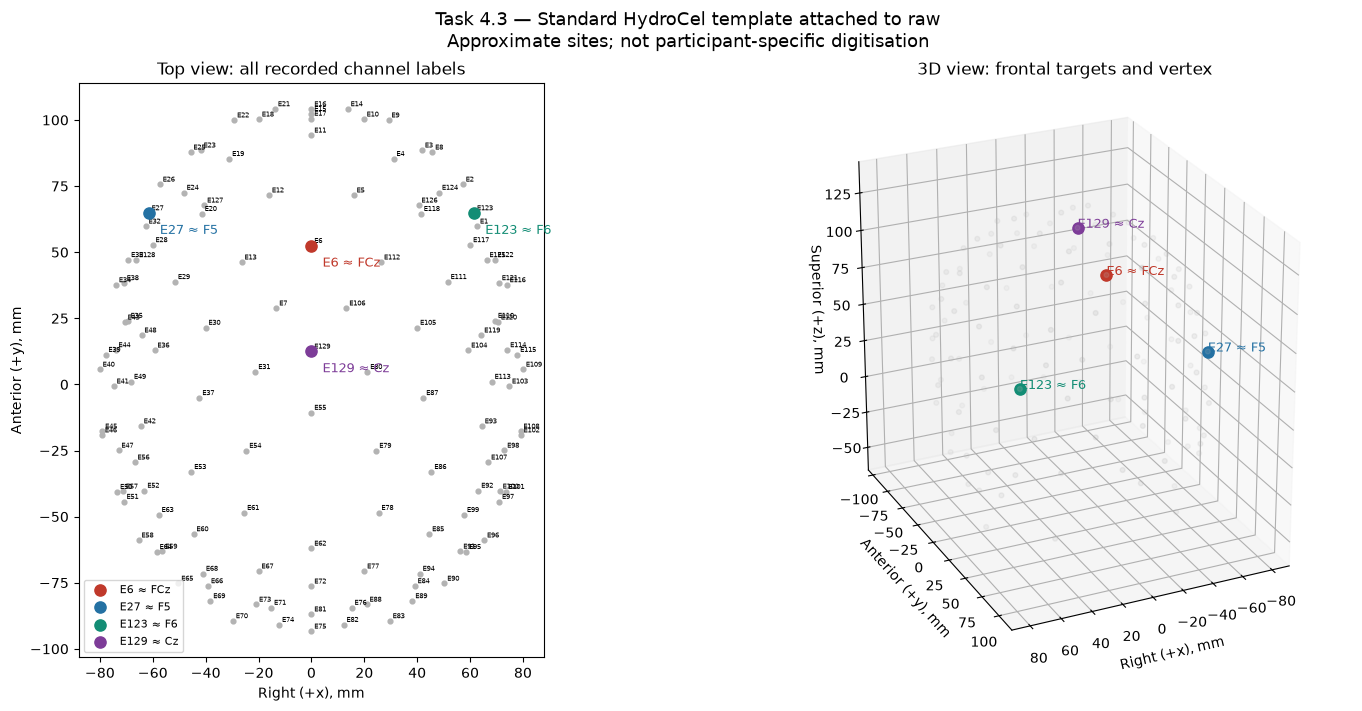

In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Use the corrected montage already attached to raw, in MNE head coordinates.
sensor_positions = raw.get_montage().get_positions()
if sensor_positions["coord_frame"] != "head":
    raise ValueError("Expected MNE head coordinates for these axis labels.")
sensor_names = raw.ch_names
sensor_xyz = np.array([sensor_positions["ch_pos"][name] for name in sensor_names]) * 1000
if not np.isfinite(sensor_xyz).all():
    raise ValueError("Some channels still have missing positions.")

# These are approximate anatomical equivalents on a standard template.
target_sites = {"E6": "FCz", "E27": "F5", "E123": "F6", "E129": "Cz"}
target_colours = {"E6": "#c0392b", "E27": "#2471a3", "E123": "#138d75", "E129": "#7d3c98"}
fig = plt.figure(figsize=(15, 7), layout="constrained")
ax_top = fig.add_subplot(121)
ax_3d = fig.add_subplot(122, projection="3d")
ax_top.scatter(sensor_xyz[:, 0], sensor_xyz[:, 1], s=12, color="0.7")
ax_3d.scatter(*sensor_xyz.T, s=12, color="0.7", alpha=0.45)
for name, position in zip(sensor_names, sensor_xyz):
    ax_top.annotate(name, position[:2], fontsize=5, xytext=(2, 2), textcoords="offset points")
for name, site in target_sites.items():
    position = sensor_xyz[sensor_names.index(name)]
    colour = target_colours[name]
    label = f"{name} ≈ {site}"
    ax_top.scatter(*position[:2], s=65, color=colour, label=label, zorder=4)
    ax_top.annotate(label, position[:2], xytext=(8, -15), textcoords="offset points", color=colour, fontsize=9)
    ax_3d.scatter(*position, s=65, color=colour)
    ax_3d.text(*position, label, color=colour, fontsize=9)
ax_top.set(xlabel="Right (+x), mm", ylabel="Anterior (+y), mm", title="Top view: all recorded channel labels")
ax_top.set_aspect("equal")
ax_top.legend(loc="lower left", fontsize=8)
ax_3d.set(xlabel="Right (+x), mm", ylabel="Anterior (+y), mm", zlabel="Superior (+z), mm", title="3D view: frontal targets and vertex")
ax_3d.set_box_aspect(np.ptp(sensor_xyz, axis=0))
ax_3d.view_init(elev=25, azim=65)
fig.suptitle("Task 4.3 — Standard HydroCel template attached to raw\nApproximate sites; not participant-specific digitisation", fontsize=13)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
figure_file = project_root / "figures" / "task4_3_electrode_mapping.png"
figure_file.parent.mkdir(exist_ok=True)
fig.savefig(figure_file, dpi=180)
print(f"Plotted {len(sensor_names)} channels. Saved: {figure_file.name}")
plt.show()


## 4.4 — Time–frequency and connectivity parameters

### 4.4a — Measurement window versus wavelet support

**Purpose:** specify how theta is estimated before calculating connectivity. A Morlet wavelet is a short oscillation weighted by a Gaussian envelope; it estimates complex coefficients carrying both amplitude and phase. More cycles improve frequency selectivity but spread the estimate over more time. Fewer cycles improve temporal localisation but broaden frequency sensitivity.

**Existing work reused:** the H1 walkthrough filters at 0.1–30 Hz and uses response-locked epochs from −0.5 to +0.8 s with a pre-response baseline. These are existing ERP choices, not a completed connectivity implementation. No existing time–frequency/connectivity code was found to reuse.

**Proposal retained:** 4–8 Hz and 0–150 ms post-response remain the proposed scoring band/window. At 4 Hz one cycle lasts 250 ms; the scoring window must not be used as the entire input segment. Transform sufficiently long clean epochs, estimate connectivity across trials at each time/frequency, then summarise the prespecified window. Do not average trial EEG before estimating connectivity or treat time/frequency samples as independent trials.

**Verified implementation:** [MNE Morlet documentation](https://mne.tools/stable/generated/mne.time_frequency.tfr_array_morlet.html#notes) and the installed source use sigma_t = n_cycles/(2πf), with numerical support extending approximately five sigma_t to each side. These tails are not the effective temporal resolution. Even with complete padding, a coefficient centred after the response includes surrounding, including pre-response, activity.

| Illustrative cycles at 4 Hz | Approximate half-support (s) | Input needed to cover centres from 0 to 0.15 s (s) |
|---|---:|---|
| 3 | 0.597 | −0.597 to +0.747 |
| 4.5 | 0.895 | −0.895 to +1.045 |
| 7 | 1.393 | −1.393 to +1.543 |

**Consequence:** the existing −0.5 to +0.8 s epochs do not provide full numerical wavelet support throughout the scoring window for these examples at 4 Hz. That does not invalidate their ERP use. Define a separate connectivity epoch/support plan; do not change the ERP epoch merely to satisfy a wavelet requirement. Zero-padding is not additional recorded signal, and discontinuities within the support require screening. Longer support also increases sensitivity to surrounding task events.

**Completed diagnostic:** the saved table below shows numerical support across 4–8 Hz. These are theoretical calculations, not participant EEG results. No additional support exercise is needed.

**Decision still required:** cycle count and sufficient clean signal support. A separate −1.2 to +1.2 s connectivity epoch with 4.5 cycles is a candidate, not an adopted setting. Keep existing ERP settings unchanged. Review the temporal-smoothing illustration below alongside frequency specificity when agreeing the method.


In [5]:
import numpy as np
import pandas as pd

# Compare approximate wavelet support without transforming EEG data.
wavelet_checks = []

for n_cycles in (3, 4.5, 7):
    for frequency in (4, 6, 8):
        sigma_t = n_cycles / (2 * np.pi * frequency)
        half_support = 5 * sigma_t

        wavelet_checks.append({
            "cycles": n_cycles,
            "frequency_hz": frequency,
            "required_start_s": -half_support,
            "required_end_s": 0.150 + half_support,
        })

wavelet_checks = pd.DataFrame(wavelet_checks)
display(wavelet_checks.round(3))


,cycles,frequency_hz,required_start_s,required_end_s
0,3.0,4,-0.597,0.747
1,3.0,6,-0.398,0.548
2,3.0,8,-0.298,0.448
3,4.5,4,-0.895,1.045
4,4.5,6,-0.597,0.747
5,4.5,8,-0.448,0.598
6,7.0,4,-1.393,1.543
7,7.0,6,-0.928,1.078
8,7.0,8,-0.696,0.846


### 4.4b — Visualise temporal smoothing before selecting cycles

**Purpose:** distinguish sufficient numerical support from precise timing. A symmetric Morlet wavelet centred after the response also weights samples before and after its centre. Longer epochs prevent edge truncation but do not remove this temporal smoothing.

**Diagnostic:** compare Gaussian amplitude envelopes for 3, 4.5 and 7 cycles at 4 Hz, centred at 75 ms (the midpoint of the proposed scoring window). The shaded band marks 0–150 ms. A second panel shows the envelope full width at half maximum (FWHM) across 4–8 Hz. These are theoretical envelopes, not EEG, power, dWPLI, or an empirical measure of contamination. The oscillating part and zero-mean correction are not displayed.

**Parameters:** sigma_t = n_cycles/(2πf); amplitude-envelope FWHM = 2√(2 ln 2) × sigma_t. This differs from full numerical support (approximately ±5 sigma_t). Use the same envelope definition when comparing widths; power-envelope widths differ.

**Interpretation:** more cycles give broader temporal weighting and narrower frequency sensitivity. Fewer cycles shorten temporal weighting while broadening frequency sensitivity. We cannot eliminate this trade-off by lengthening epochs. For 4.5 cycles at 4 Hz, the amplitude-envelope FWHM is approximately 422 ms, so a coefficient centred inside 0–150 ms does not isolate activity occurring only in that interval. The current −1.2 to +1.2 s epoch suggestion addresses support only, not that limitation.

**Expected output:** two explanatory panels and a width table, saved to `figures/wavelet_temporal_smoothing.png`. No cycle count, epoch length or scoring change is adopted. Review this output before agreeing the time–frequency specification.

**Verified output (execution 6):** the plot and nine-row table are saved. At 4 Hz the amplitude-envelope FWHMs are 281.1, 421.6 and 655.9 ms for 3, 4.5 and 7 cycles; at 8 Hz they are 140.5, 210.8 and 327.9 ms. These theoretical widths confirm the temporal-smoothing trade-off, not an observed EEG effect. The 4.5-cycle candidate averages information over a substantially wider temporal neighbourhood than the scoring window.

**Status:** illustration complete. Record the chosen setting and rationale in the analysis plan; this plot does not select a setting or introduce another hypothesis. A sensitivity analysis is optional unless agreed in that plan.


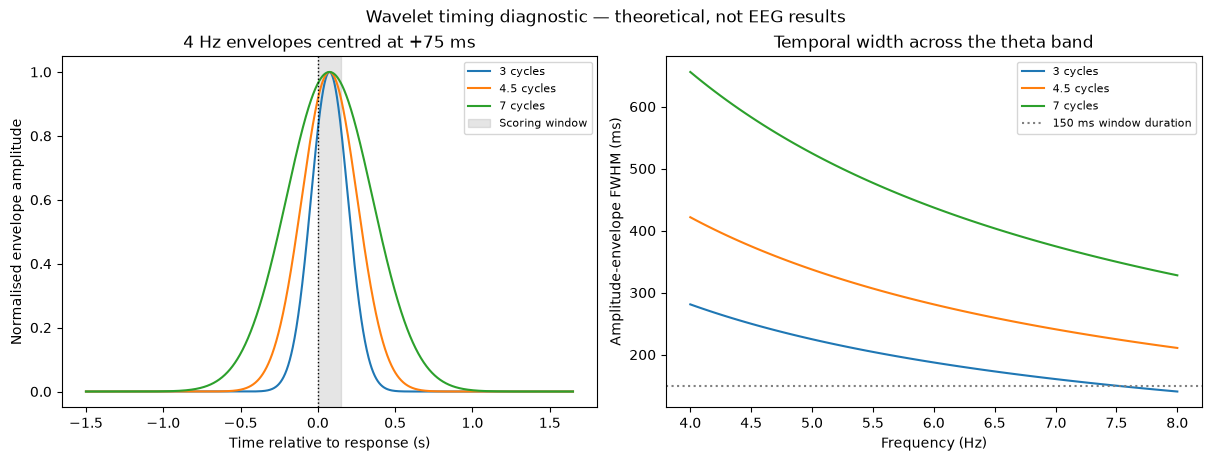

,cycles,frequency_hz,amplitude_envelope_fwhm_ms
0,3.0,4,281.1
1,3.0,6,187.4
2,3.0,8,140.5
3,4.5,4,421.6
4,4.5,6,281.1
5,4.5,8,210.8
6,7.0,4,655.9
7,7.0,6,437.2
8,7.0,8,327.9


Saved: wavelet_temporal_smoothing.png


In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Theoretical wavelet envelopes; no participant EEG is used.
cycle_options = (3, 4.5, 7)
frequencies = np.linspace(4, 8, 81)
plot_times = np.linspace(-1.5, 1.65, 1600)
centre_s = 0.075
width_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")

for cycles in cycle_options:
    sigma_4hz = cycles / (2 * np.pi * 4)
    envelope = np.exp(-0.5 * ((plot_times - centre_s) / sigma_4hz) ** 2)
    axes[0].plot(plot_times, envelope, label=f"{cycles:g} cycles")

    sigma_t = cycles / (2 * np.pi * frequencies)
    fwhm_ms = 2 * np.sqrt(2 * np.log(2)) * sigma_t * 1000
    axes[1].plot(frequencies, fwhm_ms, label=f"{cycles:g} cycles")
    for frequency in (4, 6, 8):
        width_rows.append({
            "cycles": cycles,
            "frequency_hz": frequency,
            "amplitude_envelope_fwhm_ms": (
                2 * np.sqrt(2 * np.log(2)) * cycles
                / (2 * np.pi * frequency) * 1000
            ),
        })

axes[0].axvspan(0, 0.150, color="grey", alpha=0.2, label="Scoring window")
axes[0].axvline(0, color="black", linestyle=":", linewidth=1)
axes[0].set(xlabel="Time relative to response (s)", ylabel="Normalised envelope amplitude",
            title="4 Hz envelopes centred at +75 ms")
axes[1].axhline(150, color="grey", linestyle=":", label="150 ms window duration")
axes[1].set(xlabel="Frequency (Hz)", ylabel="Amplitude-envelope FWHM (ms)",
            title="Temporal width across the theta band")
for axis in axes:
    axis.legend(fontsize=8)
fig.suptitle("Wavelet timing diagnostic — theoretical, not EEG results")
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
figure_file = project_root / "figures" / "wavelet_temporal_smoothing.png"
figure_file.parent.mkdir(exist_ok=True)
fig.savefig(figure_file, dpi=180)
plt.show()
wavelet_widths = pd.DataFrame(width_rows)
display(wavelet_widths.round(1))
print(f"Saved: {figure_file.name}")


## 4.5 — Reliability sampling and estimation

Mark's requested comparison is secondary: Spearman–Brown-corrected split-half reliability of dWPLI and ΔERN at matched usable error-trial counts. The proposal's candidate counts are 6, 8, 12 and 16.

Before implementation, specify whether each count is total or per half, how correct trials contribute to each ΔERN half, the shared participant/trial sampling, random seed, and uncertainty method. Retain the estimator limitations recorded in Task 3.4. H4 eligibility need not require PES-valid triplets.

Repeated splits summarise stability descriptively; their coefficients are not independent cases for a significance test. **Status:** specification pending; reliability has not yet been calculated.


## 4.6 — Remaining decisions and supervisor agreement

| Decision to record once in the analysis plan | Status |
|---|---|
| Handling A/B/C and nonstandard recordings without treating repeated participant recordings as independent people | Pending |
| RT rules and per-analysis minimum counts | Pending; use 4.2 evidence |
| Pair-wise versus combined E6–E27/E6–E123 score, exact debiased estimator, wavelet and epoch support | Pending; proposed 4–8 Hz and 0–150 ms retained |
| Final EEG preprocessing, baseline, rejection and trial linkage | Existing implementation to validate in Task 5 |
| Matched reliability sampling, correct-trial handling and uncertainty | Pending; see 4.5 |
| Confirmatory tests, multiplicity and interpretation if H2 is unsupported | Pending; Spearman's rho remains proposed for H3 |

The task plan requires supervisor agreement before hypothesis testing. No such agreement to all these parameters is documented here. Consolidate these choices into one reviewable plan rather than adding another chain of diagnostic tasks. Supporting EEG validation can proceed while decisions unrelated to H1 remain open.


# Task 5 — Review the existing EEG pipeline and ΔERN

**Status:** retained single-recording exploratory implementation; validation remains incomplete. This section was written before the sequential task plan and reuses `raw` loaded with its corrected montage in Task 4.3. Its presence does not mean Task 4 has been completed.

**Purpose for Mark's requirements:** establish trustworthy EEG measurements before calculating synchrony–PES associations or comparing reliability. The saved ΔERN points in the H1 direction, but one recording is not a group test or a fully validated pipeline.

**Next concrete validation:** review recording discontinuities and response alignment in this existing code, then record artefact exclusions and retained error/correct trial identities. The executed all-boundary check found zero overlapping response epochs in this reference recording; filtering now separates the segments (Step 3, execution 11), with edge effects and downstream EEG validation still outstanding. ICA exclusions are recording-specific. Review baseline and rejection settings before generalising.

Task 2's standard counting function records boundary information, whereas its reviewed-exception function explicitly screens discontinuity segments. These routes must receive consistent final discontinuity screening and EEG trial linkage before final eligibility; the saved structural counts are not that final screen.

Existing code, figures and saved numerical outputs are retained below. No preprocessing or hypothesis analysis was rerun for this review.


## Step 3 — Band-pass filter without joining discontinuous segments

The existing 0.1–30 Hz filter attenuates slow drift and higher-frequency activity. The earlier saved execution filtered in one continuous segment because the imported `boundary` label is not among MNE's default filter-splitting annotations.

**Correction:** preserve the original annotation, and add a zero-duration `EDGE boundary` at each discontinuity. MNE filters the resulting segments separately. No samples are removed and no filter cutoff is changed. The same edge markers are also recognised by the later 1 Hz ICA preparation filter.

[EEGLAB documents](https://eeglab.org/tutorials/ConceptsGuide/Data_Structures.html) boundary durations as removed-data lengths. The reference recording contains a boundary at 1.18 s with imported duration 0.466 s; that duration should not be treated as a further retained-data exclusion. The point marker identifies the join in the retained signal. [MNE filtering documentation](https://mne.tools/stable/generated/mne.io.Raw.html#mne.io.Raw.filter) describes `skip_by_annotation`; the installed MNE 1.12.1 source confirms defaults of `edge` and `bad_acq_skip` and splitting at zero-duration markers.

**Expected output:** two filtering segments for this reference recording, unchanged sample count, and filter limits 0.1 and 30 Hz. The cell requires freshly loaded data to prevent accidental repeated filtering; reload Task 4.3a and reapply its montage before deliberately rerunning it.

**Remaining limitation:** segment-wise filtering prevents mixing across the join but does not eliminate filter-edge effects. The 1.18 s initial segment is much shorter than the 33.002 s FIR filter and contains no response events; padding is not independent recorded data. Later response epochs still need signal-quality review. Existing downstream ICA/ERP outputs remain historical until rebuilt and checked with this correction.

**Verified live execution 11:** filtering used two contiguous segments; all 283,067 samples were preserved; limits are 0.1 and 30 Hz. This verifies segment separation, not complete EEG/ERN validation.


In [6]:
# Start from the freshly loaded recording, before any filtering or ICA.
import numpy as np

if raw.info["highpass"] != 0.0 or raw.info["lowpass"] != raw.info["sfreq"] / 2:
    raise RuntimeError("Reload raw and apply the montage before rerunning this filter.")

# Preserve imported boundary durations; add point markers for filter splitting.
boundary_onsets = raw.annotations.onset[
    raw.annotations.description == "boundary"
]
existing_edges = raw.annotations.onset[
    raw.annotations.description == "EDGE boundary"
]
for onset in boundary_onsets:
    if not np.any(np.isclose(existing_edges, onset, rtol=0, atol=1e-9)):
        raw.annotations.append(onset, 0.0, "EDGE boundary")

samples_before_filter = raw.n_times
raw.filter(
    l_freq=0.1,
    h_freq=30,
    skip_by_annotation=("edge", "bad_acq_skip"),
)
assert raw.n_times == samples_before_filter
print("Discontinuity markers:", len(boundary_onsets))
print("Sample count preserved:", raw.n_times)
print("Filter limits (Hz):", raw.info["highpass"], raw.info["lowpass"])


Filtering raw data in 2 contiguous segments


Setting up band-pass filter from 0.1 - 30 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal bandpass filter:


...

- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)


- Upper passband edge: 30.00 Hz


- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)


- Filter length: 16501 samples (33.002 s)


Discontinuity markers: 1
Sample count preserved: 283067
Filter limits (Hz): 0.1 30.0


## Step 4 — Re-reference from vertex to average

EEG values are voltage differences relative to a reference. The metadata specifies Cz as the original reference. The following cell applies an average reference, expressing each included EEG channel relative to their instantaneous mean.

This is the current implementation choice. Review bad-channel handling, the included channel set and E129 treatment before generalising it. The saved `custom_ref_applied` value confirms that the operation was applied, not that its scientific suitability has been validated.

In [7]:
raw.set_eeg_reference("average")
print(raw.info["custom_ref_applied"])

EEG channel type selected for re-referencing


Applying average reference.


Applying a custom ('EEG',) reference.


1 (FIFFV_MNE_CUSTOM_REF_ON)


## Step 5 — Inspect boundary and response markers

The saved event extraction contains 652 markers labelled `boundary`, `con`, `cor`, `err` and `inc`. The task dictionary defines `con`/`inc` as stimuli and `cor`/`err` as responses. Recording discontinuities are not automatically task-block boundaries.

Extract the events below, then check all boundary markers against the existing response-locked epoch window. The original filter treated the recording as one contiguous segment. The corrected Step 3 execution now filters two segments separately; absence of epoch overlap still does not establish absence of filter-edge effects.


In [10]:
events, event_id = mne.events_from_annotations(raw)
print(event_id)
print(events.shape)

Used Annotations descriptions: [np.str_('boundary'), np.str_('con'), np.str_('cor'), np.str_('err'), np.str_('inc')]


{np.str_('boundary'): 1, np.str_('con'): 2, np.str_('cor'): 3, np.str_('err'): 4, np.str_('inc'): 5}
(652, 3)


### Check every boundary against the existing ERP epoch window

A recording boundary marks a discontinuity. An epoch overlaps it when the boundary falls between that response's −0.5 s and +0.8 s limits. The following table checks all boundary markers and reports the nearest response on each side. Blank distances mean no response exists on that side.

**Verified live output (execution 9):** one boundary at 1.18 s, no preceding response, and the next response 6.178 s later. Zero response epochs overlap this boundary using −0.5 to +0.8 s. This establishes only that these epochs avoid the boundary itself; filtering may still spread a discontinuity into nearby data.

**Prerequisite:** run the event-extraction cell immediately above with the reference `raw` loaded. This diagnostic does not filter data, reject epochs or change an analysis parameter. The existing ERP epoch limits are reused solely for this check.


In [9]:
# Inspect all recording boundaries against the existing ERP epoch window.
import numpy as np
import pandas as pd

boundary_samples = events[
    events[:, 2] == event_id.get("boundary", -1), 0
]
response_codes = [event_id["cor"], event_id["err"]]
response_samples = events[np.isin(events[:, 2], response_codes), 0]
sfreq = raw.info["sfreq"]
epoch_tmin, epoch_tmax = -0.5, 0.8

boundary_rows = []
for sample in boundary_samples:
    # Offsets are relative to this boundary: negative before, positive after.
    offsets = (response_samples - sample) / sfreq
    before = offsets[offsets < 0]
    after = offsets[offsets > 0]
    overlaps = (
        (offsets + epoch_tmin <= 0)
        & (offsets + epoch_tmax >= 0)
    )
    boundary_rows.append({
        "boundary_time_s": (sample - raw.first_samp) / sfreq,
        "nearest_response_before_s": -before.max() if before.size else np.nan,
        "nearest_response_after_s": after.min() if after.size else np.nan,
        "overlapping_response_epochs": int(overlaps.sum()),
    })

boundary_check = pd.DataFrame(boundary_rows, columns=[
    "boundary_time_s", "nearest_response_before_s",
    "nearest_response_after_s", "overlapping_response_epochs",
])
display(boundary_check)
print("Boundary markers checked:", len(boundary_check))
print("Epoch window checked (s):", (epoch_tmin, epoch_tmax))
print("This checks epoch overlap only; filtering across boundaries remains to be resolved.")


,boundary_time_s,nearest_response_before_s,nearest_response_after_s,overlapping_response_epochs
0,1.18,NaN,6.178,0


Boundary markers checked: 1
Epoch window checked (s): (-0.5, 0.8)
This checks epoch overlap only; filtering across boundaries remains to be resolved.


## Step 6 — ICA ocular-artefact correction

Independent component analysis (ICA) represents multichannel data using components whose time courses are estimated to be statistically independent. The purpose here is to identify ocular contamination and remove selected contributions before measuring the response-locked ERP.

This implementation fits ICA to continuous data, then applies the selected correction before epoching. The documented earlier visual review selected components 2 and 3 as ocular candidates. Their identity and removal are decisions for this recording and fit, not a participant-wide exclusion rule. Component removal and the cleaned data require QC; applying ICA alone does not establish that only artefacts were removed.

**6a — Fit ICA.** Use a copy high-pass filtered at 1 Hz, preserving the main 0.1–30 Hz data. Both filters respect the added edge markers. Picard and seed 42 are retained.

The corrected-data fit with 25 components (execution 14) emitted an unstable-mixing warning: the largest/smallest retained PCA variances were approximately 130 and 0.000079, a ratio exceeding one million. MNE recommended an integer no greater than 20. The implementation therefore uses 20 for this recording; this is a numerical correction, not evidence for a universal component count or an explanation of upstream preprocessing. The new fit must be checked before any component removal.


In [8]:
# Use 20 components for this recording after the 25-component instability warning.
raw_for_ica = raw.copy().filter(l_freq=1.0, h_freq=None)
ica = mne.preprocessing.ICA(n_components=20, method="picard", random_state=42)
ica.fit(raw_for_ica)

Filtering raw data in 2 contiguous segments


Setting up high-pass filter at 1 Hz


FIR filter parameters


---------------------


Designing a one-pass, zero-phase, non-causal highpass filter:


...

- Filter length: 1651 samples (3.302 s)


Fitting ICA to data using 129 channels (please be patient, this may take a while)


Selecting by number: 20 components


Fitting ICA took 28.8s.


Method,picard
Fit parameters,max_iter=500
Fit,98 iterations on raw data (283067 samples)
ICA components,20
Available PCA components,129
Channel types,eeg
ICA components marked for exclusion,—


**6b — Inspect the current component maps.** The 20-component fit completed without the previous numerical warning (execution 17). Several maps still have similar patterns, so lack of a warning does not by itself validate source separation. Components 3 and 6 show frontal concentrations and are candidates for temporal inspection, not approved exclusions.

![Current 20-component ICA maps](../figures/sub-1004_ses-1_ica_components_0.png)


In [18]:
mne.viz.set_browser_backend("matplotlib")
figs = ica.plot_components(show=False)
figs = figs if isinstance(figs, list) else [figs]
for i, fig in enumerate(figs):
    fig.savefig(f"../figures/sub-1004_ses-1_ica_components_{i}.png", dpi=150)
    plt.close(fig)
print(f"Saved {len(figs)} ICA component topography figure(s)")

Saved 1 ICA component topography figure(s)


**6c — Inspect candidate properties.** Review components 3 and 6 from the current fit using their maps, spectra and segment-wise activity. These diagnostics support component assessment but do not by themselves establish an ocular source.

**Observed:** both maps are frontally concentrated, with substantial low-frequency power and occasional high-variance segments. This is compatible with ocular contributions, but is not conclusive identification. The 283 diagnostic segments are plotting windows, not response-trial counts.

![ICA003 properties](../figures/sub-1004_ses-1_ica_properties_3.png)

![ICA006 properties](../figures/sub-1004_ses-1_ica_properties_6.png)


In [20]:
figs = ica.plot_properties(raw, picks=[3, 6], show=False)
for comp_num, fig in zip([3, 6], figs):
    fig.savefig(f"../figures/sub-1004_ses-1_ica_properties_{comp_num}.png", dpi=150)
    plt.close(fig)
print("Saved ICA properties figures for ICA003 and ICA006")

    Using multitaper spectrum estimation with 7 DPSS windows


Not setting metadata


283 matching events found


No baseline correction applied


0 projection items activated


Not setting metadata


283 matching events found


No baseline correction applied


0 projection items activated


Saved ICA properties figures for ICA003 and ICA006


**6d — Inspect candidate time courses.** Plot components 3 and 6 over 10–25 s. These are current-fit candidates based on frontal maps. Temporal comparison with the EEG is needed before selecting exclusions; historical component numbers are not reused automatically.

**Observed:** both sources contain prominent transients around 10.9, 13.3 and 17 s; ICA006 also shows broader slow changes. These patterns support further ocular assessment without establishing that either source contains only artefact. Next compare the effect of candidate removal on a copy of the EEG before deciding exclusions.

![Current candidate source traces](../figures/sub-1004_ses-1_ica_sources_3_6_10-25s.png)


In [21]:
fig = ica.plot_sources(raw, picks=[3, 6], start=10, stop=25, show=False)
fig.savefig("../figures/sub-1004_ses-1_ica_sources_3_6_10-25s.png", dpi=150)
plt.close(fig)
print("Saved figures/sub-1004_ses-1_ica_sources_3_6_10-25s.png")

Creating RawArray with float64 data, n_channels=2, n_times=283067


    Range : 0 ... 283066 =      0.000 ...   566.132 secs


Ready.


Saved figures/sub-1004_ses-1_ica_sources_3_6_10-25s.png


### Compare candidate removal before selecting exclusions

Apply each candidate exclusion to a temporary copy and compare the same 10–25 s interval. Grey traces show the working EEG; blue traces show the result after candidate removal. Each channel uses the same vertical scale across the three alternatives.

E8 and E25 provide frontal inspection channels; E6 is the FCz target and E129 the reference-channel location. They are inspection channels, not a new analysis ROI or independent EOG measurement. The RMS table quantifies how much the signal changes; a larger reduction is not automatically better artefact correction.

Look for reduction of the transient deflections seen in the component time courses, and for broad changes to other activity, especially at E6. This short visual comparison cannot establish preservation of all neural signals or validate exclusions across the full recording. Neither a cleaner appearance nor the eventual ERN direction should determine the choice by itself.

**Output:** comparison figure and change table. The working `raw` and stored ICA exclusions remain unchanged; the following application cell stays paused until the decision is justified.

**Observed in live execution 23:** removing ICA003 substantially reduces the sharp frontal transients at E8/E25. Removing ICA006 alone leaves the main transients largely intact and changes broader activity. Removing both reduces residual frontal transients further, but this is not sufficient evidence that ICA006 should also be removed. E6 RMS changes are approximately 0.004 µV (3), 0.042 µV (6), and 0.042 µV (both) in this interval; these are local change measures, not proof of neural-signal preservation. Slow baseline variation remains visible.

**Decision status:** ICA003 is the better-supported ocular-removal candidate. ICA006 remains unapproved. No exclusion has been applied to the working EEG. Confirm the candidate against activity later in the recording, away from the initial boundary, before applying it; this is a targeted check of the same decision, not an additional research aim.


Applying ICA to Raw instance


    Transforming to ICA space (20 components)


    Zeroing out 1 ICA component


    Projecting back using 129 PCA components


Applying ICA to Raw instance


...

    Projecting back using 129 PCA components


Applying ICA to Raw instance


    Transforming to ICA space (20 components)


    Zeroing out 2 ICA components


    Projecting back using 129 PCA components


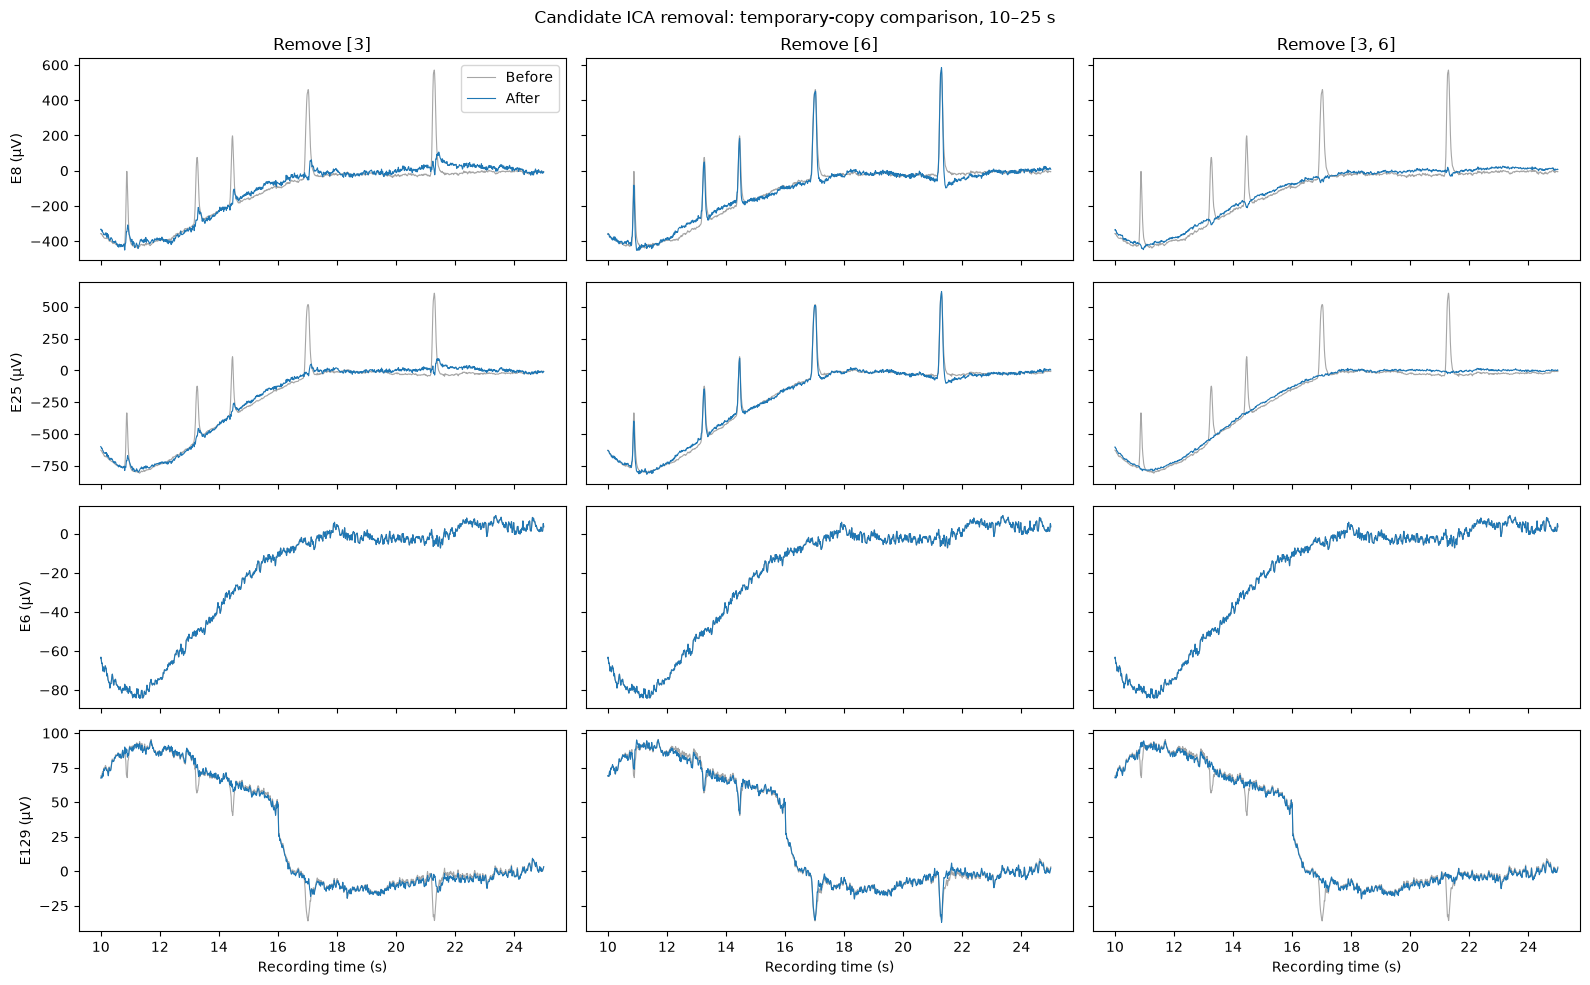

,excluded,channel,rms_change_uV
0,[3],E8,76.115474
1,[3],E25,83.739264
2,[3],E6,0.003944
3,[3],E129,4.122502
4,[6],E8,27.482181
5,[6],E25,22.743237
6,[6],E6,0.041996
7,[6],E129,1.768718
8,"[3, 6]",E8,81.943881
9,"[3, 6]",E25,87.639154


Working raw and stored ICA exclusions unchanged.
RMS change measures the size of the alteration, not correction quality.


In [23]:
# Compare candidate exclusions on copies; preserve the working EEG.
import numpy as np
import matplotlib.pyplot as plt

comparison_channels = ["E8", "E25", "E6", "E129"]
comparison_start, comparison_stop = 10.0, 25.0
comparison_first = int(round(comparison_start * raw.info["sfreq"]))
comparison_last = int(round(comparison_stop * raw.info["sfreq"]))
comparison_before = raw.get_data(
    picks=comparison_channels, start=comparison_first, stop=comparison_last
)
comparison_times = raw.times[comparison_first:comparison_last]
comparison_exclusions = [(3,), (6,), (3, 6)]
comparison_original_exclude = list(ica.exclude)
comparison_changes = []

fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex=True, sharey="row")
for column, excluded in enumerate(comparison_exclusions):
    comparison_copy = raw.copy()
    ica.apply(comparison_copy, exclude=list(excluded))
    comparison_after = comparison_copy.get_data(
        picks=comparison_channels, start=comparison_first, stop=comparison_last
    )
    assert np.isfinite(comparison_after).all()
    for row, channel in enumerate(comparison_channels):
        ax = axes[row, column]
        ax.plot(comparison_times, comparison_before[row] * 1e6,
                color="0.65", linewidth=0.8, label="Before")
        ax.plot(comparison_times, comparison_after[row] * 1e6,
                color="tab:blue", linewidth=0.8, label="After")
        if row == 0:
            ax.set_title(f"Remove {list(excluded)}")
        if column == 0:
            ax.set_ylabel(f"{channel} (µV)")
        if row == 3:
            ax.set_xlabel("Recording time (s)")
        comparison_changes.append({
            "excluded": str(list(excluded)),
            "channel": channel,
            "rms_change_uV": float(np.sqrt(np.mean(
                (comparison_after[row] - comparison_before[row]) ** 2
            )) * 1e6),
        })
    del comparison_copy
axes[0, 0].legend(loc="upper right")
fig.suptitle("Candidate ICA removal: temporary-copy comparison, 10–25 s")
fig.tight_layout()
fig.savefig("../figures/sub-1004_ses-1_ica_candidate_comparison.png", dpi=150)
plt.show()
plt.close(fig)
display(pd.DataFrame(comparison_changes))
assert np.array_equal(comparison_before, raw.get_data(
    picks=comparison_channels, start=comparison_first, stop=comparison_last
))
assert list(ica.exclude) == comparison_original_exclude
print("Working raw and stored ICA exclusions unchanged.")
print("RMS change measures the size of the alteration, not correction quality.")


### Confirm ICA003 in later recording intervals

Compare removal of component 3 on a copy at 100–115, 250–265 and 450–465 s. These intervals are fixed before looking at their plots and sample early, middle and late activity away from the initial boundary. The same four inspection channels and matching row scales are used. The aim is to check whether the earlier frontal-transient reduction generalises, not to maximise an ERN or synchrony result.

Grey is before removal; blue is after removal on a copy. RMS change describes alteration, not correction quality. This targeted visual review supports a recording-specific exclusion decision; it does not prove the component contains only ocular activity or replace epoch artefact screening.

**Observed, execution 25:** sharp frontal transients are reduced in all three later intervals. Broader waveform changes are also visible, particularly around 254–258 s; no claim of pure artefact removal is made. Together with the component map, time course and initial comparison, this supports a recording-specific exclusion of ICA003. ICA006 remains retained. Epoch-level artefact screening is still necessary.


Applying ICA to Raw instance


    Transforming to ICA space (20 components)


    Zeroing out 1 ICA component


    Projecting back using 129 PCA components


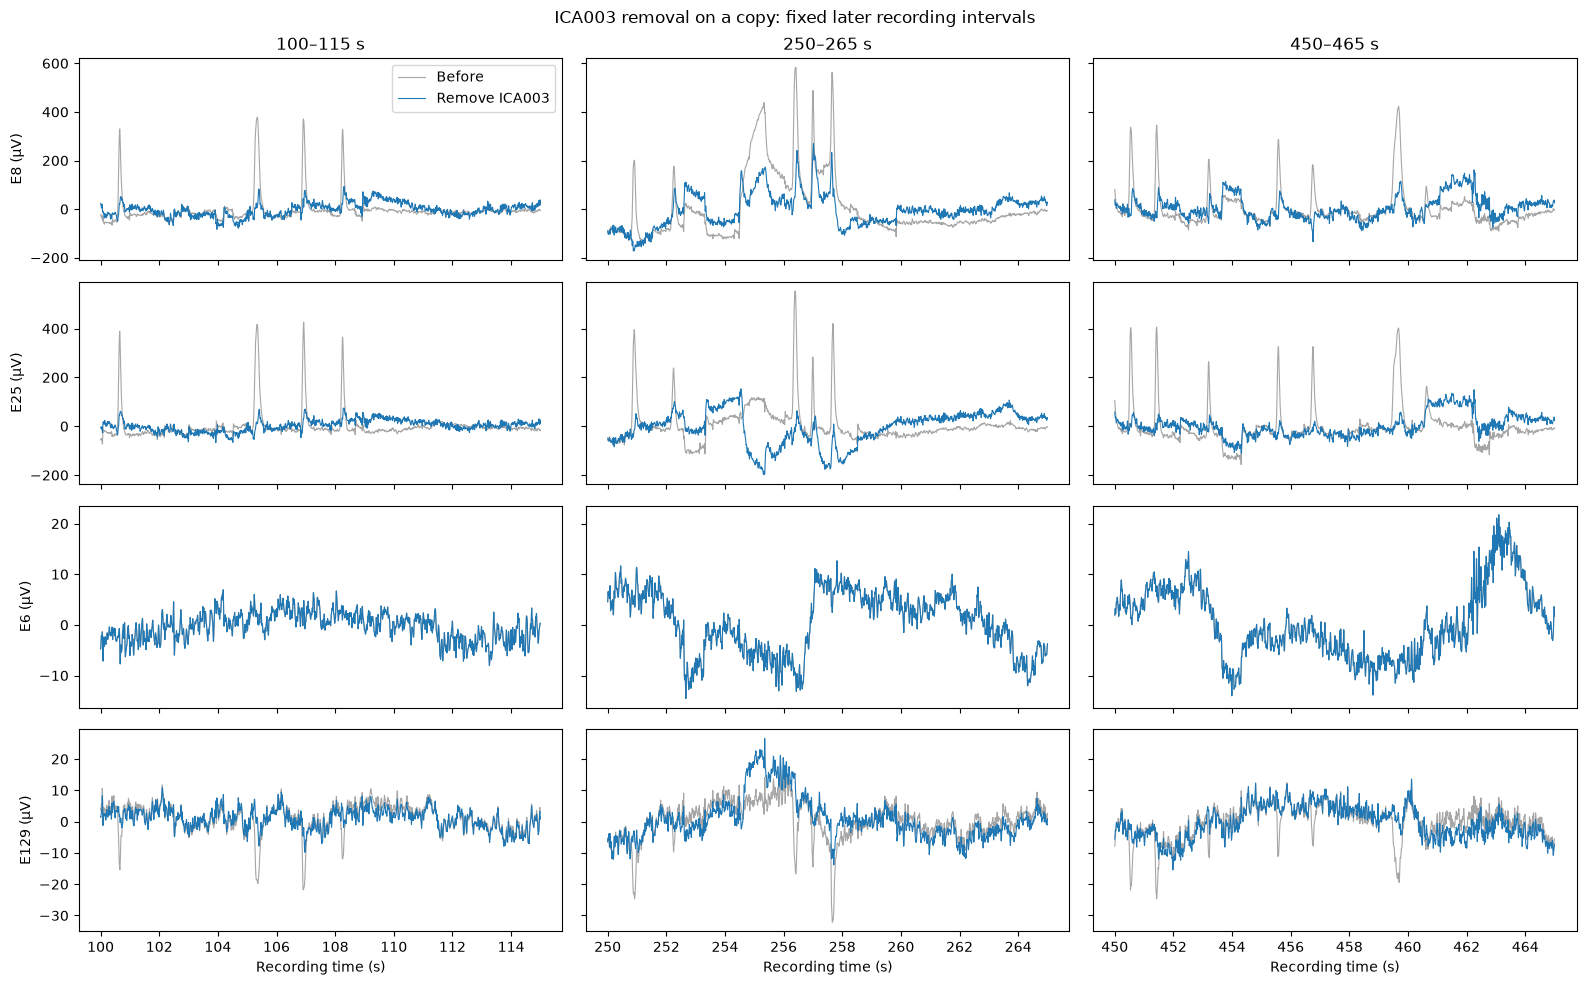

,interval_s,channel,rms_change_uV
0,100–115,E8,52.685062
1,100–115,E25,57.962042
2,100–115,E6,0.002730
3,100–115,E129,2.853484
4,250–265,E8,95.576516
5,250–265,E25,105.149540
6,250–265,E6,0.004952
7,250–265,E129,5.176534
8,450–465,E8,72.743961
9,450–465,E25,80.030057


Working raw unchanged; no exclusions applied.


In [25]:
# Fixed later intervals check the same candidate away from the initial boundary.
assert not ica.exclude, "Run this comparison before applying ICA exclusions."
later_windows = [(100, 115), (250, 265), (450, 465)]
later_channels = ["E8", "E25", "E6", "E129"]
later_copy = raw.copy()
ica.apply(later_copy, exclude=[3])
later_changes = []
fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex="col", sharey="row")
for column, (start_s, stop_s) in enumerate(later_windows):
    first = int(round(start_s * raw.info["sfreq"]))
    last = int(round(stop_s * raw.info["sfreq"]))
    before = raw.get_data(picks=later_channels, start=first, stop=last)
    after = later_copy.get_data(picks=later_channels, start=first, stop=last)
    assert np.isfinite(after).all()
    for row, channel in enumerate(later_channels):
        ax = axes[row, column]
        ax.plot(raw.times[first:last], before[row] * 1e6,
                color="0.65", linewidth=0.8, label="Before")
        ax.plot(raw.times[first:last], after[row] * 1e6,
                color="tab:blue", linewidth=0.8, label="Remove ICA003")
        if row == 0:
            ax.set_title(f"{start_s}–{stop_s} s")
        if column == 0:
            ax.set_ylabel(f"{channel} (µV)")
        if row == 3:
            ax.set_xlabel("Recording time (s)")
        later_changes.append({
            "interval_s": f"{start_s}–{stop_s}", "channel": channel,
            "rms_change_uV": float(np.sqrt(np.mean((after[row] - before[row])**2)) * 1e6),
        })
axes[0, 0].legend(loc="upper right")
fig.suptitle("ICA003 removal on a copy: fixed later recording intervals")
fig.tight_layout()
fig.savefig("../figures/sub-1004_ses-1_ica3_later_comparison.png", dpi=150)
plt.show()
plt.close(fig)
display(pd.DataFrame(later_changes))
del later_copy
print("Working raw unchanged; no exclusions applied.")


**6e — Apply the reviewed exclusion.** Exclude component 3 from the current 20-component Picard fit; retain component 6. The decision follows the frontal map, source transients and temporary-copy comparisons across four intervals. It does not depend on an ERN result. The decision and limitations are saved in `results/task5/sub-1004_ses-1_ica_decision.json`.

This exclusion is specific to this recording and fit. The code stops if exclusions are already set to prevent accidental repeated application. To rebuild, reload the recording and rerun the preprocessing/fit stages in order. Historical ERP results below do not yet reflect this correction.

**Executed:** live execution 27 applied `[3]` and saved the decision record. Component 6 was retained.


In [9]:
# Recording-specific decision for the reviewed 20-component fit.
from pathlib import Path
import json

assert ica.n_components_ == 20, "Review exclusions again for a different fit."
if ica.exclude:
    raise RuntimeError("Exclusions are already set; do not apply ICA correction twice.")
reviewed_ica_components = [3]
ica.exclude = reviewed_ica_components
ica.apply(raw)

ica_decision = {
    "recording": "sub-1004_ses-1_task-ffb",
    "method": "picard",
    "n_components": int(ica.n_components_),
    "random_seed": 42,
    "excluded_components": list(ica.exclude),
    "retained_candidate": 6,
    "review_intervals_s": [[10, 25], [100, 115], [250, 265], [450, 465]],
    "rationale": "Frontal map, transient source activity and consistent reduction of sharp frontal deflections on EEG copies.",
    "limitations": "Broader changes remain visible; ocular attribution is a visual judgement, not proof of a pure artefact source. Epoch screening remains required.",
    "main_filter_hz": [0.1, 30],
    "ica_fit_highpass_hz": 1.0,
    "reference": "average",
    "boundary_handling": "Zero-duration EDGE boundary markers separate filtering segments; original annotations preserved.",
    "status": "Single-recording correction applied; ERN not yet recomputed.",
}
Path("../results/task5").mkdir(parents=True, exist_ok=True)
Path("../results/task5/sub-1004_ses-1_ica_decision.json").write_text(
    json.dumps(ica_decision, indent=2) + "\n", encoding="utf-8"
)
print("Applied ICA exclusions:", ica.exclude)
print("ICA decision saved; response epochs and ERN still need rebuilding.")


Applying ICA to Raw instance


    Transforming to ICA space (20 components)


    Zeroing out 1 ICA component


    Projecting back using 129 PCA components


Applied ICA exclusions: [3]
ICA decision saved; response epochs and ERN still need rebuilding.


**6f — Inspect the corrected signal.** Save the current post-ICA EEG view over 10–25 s after excluding component 3. The before/after comparisons above document the effect on selected channels; this broader view does not replace response-epoch screening. Existing epoch and ΔERN outputs below remain historical until rebuilt.

![Current post-ICA EEG](../figures/sub-1004_ses-1_raw_browse_post_ica.png)


In [28]:
fig = raw.plot(n_channels=30, duration=15, start=10, show=False)
fig.savefig("../figures/sub-1004_ses-1_raw_browse_post_ica.png", dpi=150)
plt.close(fig)
print("Saved figures/sub-1004_ses-1_raw_browse_post_ica.png")

Saved figures/sub-1004_ses-1_raw_browse_post_ica.png


## Step 7 — Response-locked epochs

An epoch is a short segment aligned to an event. The following cell selects `cor` and `err` responses and extracts −500 to +800 ms. With `baseline=(None, 0)`, each channel's mean over −500 to 0 ms is subtracted from its epoch; this removes an offset, not every trend or pre-response contribution.

These epoch and baseline settings describe the existing walkthrough and need documented justification before confirmatory use. The saved output contains 321 epochs: 309 correct and 12 error, with none dropped at this stage. This is not a validated minimum-trial threshold, nor a count of valid PES triplets. No trial-level behavioural metadata is attached here.

In [11]:
# Existing epoch/baseline choices; no behavioural trial metadata is attached here.
epoch_event_id = {"cor": event_id["cor"], "err": event_id["err"]}
epochs = mne.Epochs(raw, events, event_id=epoch_event_id, tmin=-0.5, tmax=0.8, baseline=(None, 0), preload=True)
print(epochs)
print(epochs.event_id)

Not setting metadata


321 matching events found


Setting baseline interval to [-0.5, 0.0] s


Applying baseline correction (mode: mean)


0 projection items activated


Using data from preloaded Raw for 321 events and 651 original time points ...


0 bad epochs dropped


<Epochs | 321 events (all good), -0.5 – 0.8 s (baseline -0.5 – 0 s), ~205.8 MiB, data loaded,
 'cor': 309
 'err': 12>
{'cor': 3, 'err': 4}


## Step 8 — Artefact rejection and retained trial counts

The existing 100 µV peak-to-peak rule rejects an epoch if any assessed EEG channel exceeds that range. This is the existing walkthrough choice; its final justification and minimum usable-trial criteria remain unresolved.

**Current execution:** 321 response epochs (309 correct, 12 error) were formed. Rejection removed 49 correct and 7 error epochs, leaving **260 correct and 5 error**. These are EEG counts, not valid PES-triplet counts. The earlier 299/8 result came from different preprocessing and is superseded for this walkthrough. Several processing changes were made, so the difference cannot be attributed to one change alone.

Inspect the saved response-level rejection audit before extending the pipeline. Five errors provide a limited descriptive ERP and fall below the proposal's smallest candidate reliability count of six. Do not relax exclusions or remove additional components merely to increase the count or strengthen ΔERN.


In [12]:
# Existing 100 µV threshold; retained errors are not validated PES-triplet counts.
epochs.drop_bad(reject=dict(eeg=100e-6))
print(epochs)
print("cor:", len(epochs['cor']), "| err:", len(epochs['err']))

    Rejecting  epoch based on EEG : ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E53', 'E55', 'E56', 'E57', 'E58', 'E59', 'E60', 'E61', 'E62', 'E63', 'E64', 'E65', 'E66', 'E68', 'E69', 'E70', 'E72', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E81', 'E82', 'E83', 'E84', 'E85', 'E86', 'E87', 'E88', 'E90', 'E91', 'E92', 'E93', 'E94', 'E95', 'E96', 'E97', 'E98', 'E99', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E110', 'E111', 'E112', 'E113', 'E114', 'E115', 'E116', 'E117', 'E118', 'E119', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128', 'E129']


    Rejecting  epoch based on EEG : ['E1', 'E3', 'E4', 'E5', 'E7', 'E8', 'E9', 'E10', 'E12', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39', 'E40', 'E41', 'E42', 'E44', 'E46', 'E47', 'E48', 'E49', 'E50', 'E51', 'E52', 'E55', 'E56', 'E58', 'E62', 'E63', 'E64', 'E65', 'E69', 'E70', 'E72', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E82', 'E84', 'E85', 'E86', 'E87', 'E90', 'E91', 'E92', 'E93', 'E95', 'E96', 'E97', 'E98', 'E99', 'E101', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E108', 'E109', 'E112', 'E113', 'E114', 'E115', 'E117', 'E118', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128']


    Rejecting  epoch based on EEG : ['E1', 'E8', 'E9', 'E14', 'E15', 'E17', 'E18', 'E19', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E32', 'E33', 'E34', 'E35', 'E38', 'E39', 'E42', 'E44', 'E49', 'E51', 'E52', 'E58', 'E65', 'E70', 'E76', 'E77', 'E78', 'E79', 'E80', 'E85', 'E86', 'E87', 'E90', 'E99', 'E103', 'E105', 'E107', 'E109', 'E112', 'E114', 'E115', 'E117', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128']


    Rejecting  epoch based on EEG : ['E1', 'E17', 'E18', 'E21', 'E22', 'E23', 'E24', 'E26', 'E32', 'E33', 'E34', 'E35', 'E39', 'E42', 'E51', 'E58', 'E70', 'E76', 'E77', 'E78', 'E79', 'E80', 'E85', 'E86', 'E87', 'E90', 'E99', 'E105', 'E107', 'E112', 'E114', 'E115', 'E117', 'E120', 'E121', 'E122', 'E124', 'E125', 'E127', 'E128']


    Rejecting  epoch based on EEG : ['E1', 'E8', 'E9', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E32', 'E33', 'E34', 'E35', 'E36', 'E38', 'E39', 'E42', 'E44', 'E46', 'E49', 'E51', 'E52', 'E58', 'E65', 'E70', 'E76', 'E77', 'E78', 'E79', 'E80', 'E85', 'E86', 'E87', 'E90', 'E91', 'E95', 'E99', 'E102', 'E103', 'E104', 'E105', 'E106', 'E107', 'E109', 'E112', 'E113', 'E114', 'E115', 'E117', 'E120', 'E121', 'E122', 'E123', 'E124', 'E125', 'E126', 'E127', 'E128']


...

    Rejecting  epoch based on EEG : ['E8', 'E14', 'E21']


56 bad epochs dropped


<Epochs | 265 events (all good), -0.5 – 0.8 s (baseline -0.5 – 0 s), ~169.9 MiB, data loaded,
 'cor': 260
 'err': 5>


cor:

 260 | err: 5


## Step 9 — H1 measure: ΔERN at 0–100 ms

Average retained error and correct responses separately. Measure E6 mean amplitude at 0–100 ms and convert volts to microvolts. ΔERN = ERN − CRN.

**Current result:** ERN = +0.05 µV, CRN = +1.17 µV, ΔERN = −1.13 µV (rounded separately from full-precision estimates). Errors are relatively more negative than correct responses; the error mean itself is slightly positive. The plot is based on five retained errors and does not establish a group effect, adequate reliability or full H1 validation. Previous ΔERN = −1.90 µV is a historical result from different preprocessing.


In [13]:
# Current H1 measure at the working FCz channel; this is a descriptive recording-level result.
evoked_err = epochs['err'].average()
evoked_cor = epochs['cor'].average()

ern = evoked_err.copy().pick('E6').crop(tmin=0, tmax=0.1).data.mean() * 1e6
crn = evoked_cor.copy().pick('E6').crop(tmin=0, tmax=0.1).data.mean() * 1e6
delta_ern = ern - crn

print(f"ERN (error, FCz, 0-100ms): {ern:.2f} µV")
print(f"CRN (correct, FCz, 0-100ms): {crn:.2f} µV")
print(f"ΔERN = ERN - CRN: {delta_ern:.2f} µV")

ERN (error, FCz, 0-100ms): 0.05 µV
CRN (correct, FCz, 0-100ms): 1.17 µV
ΔERN = ERN - CRN: -1.13 µV


## Step 10 — Plot and save the current ERP result

Use the evoked responses calculated above, without rerunning the standalone preprocessing script. The shaded region is the 0–100 ms scoring window. Amplitudes are plotted positive upwards. This is a descriptive single-recording comparison, not a group hypothesis test.

Save the numerical summary and retained event-array indices/response samples outside source data. These identifiers preserve the connection to the EEG events; they are not yet original behavioural trial IDs or valid PES triplets.

The current plot is saved separately from the historical script-generated figure. Remaining work is final trial linkage and analysis specification, not a repeat of the completed behavioural availability or montage inspections.


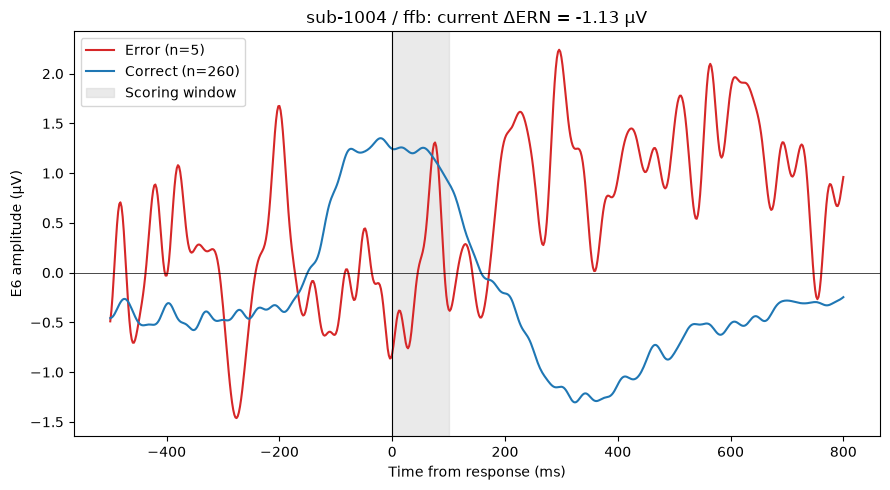

Response epoch audit:


,size,sum
condition,,
cor,309,260
err,12,5


Saved current ERP summary and retained event identities (not yet behavioural trial IDs).


In [16]:
# Plot and save the current notebook result without repeating preprocessing.
from pathlib import Path
import json

fig, ax = plt.subplots(figsize=(9, 5))
for evoked, label, colour in [(evoked_err, "Error", "tab:red"),
                              (evoked_cor, "Correct", "tab:blue")]:
    ax.plot(evoked.times * 1000, evoked.get_data(picks=["E6"])[0] * 1e6,
            label=f"{label} (n={evoked.nave})", color=colour)
ax.axvspan(0, 100, color="0.8", alpha=0.4, label="Scoring window")
ax.axvline(0, color="black", linewidth=0.8)
ax.axhline(0, color="black", linewidth=0.5)
ax.set(xlabel="Time from response (ms)", ylabel="E6 amplitude (µV)",
       title=f"sub-1004 / ffb: current ΔERN = {delta_ern:.2f} µV")
ax.legend()
fig.tight_layout()
fig.savefig("../figures/sub-1004_ses-1_ern_crn_current.png", dpi=150)
plt.show()
plt.close(fig)

result_folder = Path("../results/task5")
result_folder.mkdir(parents=True, exist_ok=True)
retained_epochs = pd.DataFrame({
    "event_array_index": epochs.selection,
    "response_sample": epochs.events[:, 0],
    "condition": [next(name for name, code in epoch_event_id.items() if code == value)
                  for value in epochs.events[:, 2]],
})
retained_epochs.to_csv(result_folder / "sub-1004_ses-1_retained_epochs.csv", index=False)
# Preserve every response and its retained/rejected status for audit.
response_indices = np.flatnonzero(np.isin(events[:, 2], list(epoch_event_id.values())))
retained_indices = set(epochs.selection.tolist())
rejection_audit = pd.DataFrame([{
    "event_array_index": int(index),
    "response_sample": int(events[index, 0]),
    "condition": next(name for name, code in epoch_event_id.items()
                      if code == events[index, 2]),
    "retained": int(index) in retained_indices,
    "drop_reasons": ";".join(epochs.drop_log[index]),
} for index in response_indices])
rejection_audit.to_csv(result_folder / "sub-1004_ses-1_epoch_audit.csv", index=False)
assert rejection_audit["retained"].sum() == len(epochs)
print("Response epoch audit:")
display(rejection_audit.groupby("condition")["retained"].agg(["size", "sum"]))
summary = {
    "recording": "sub-1004_ses-1_task-ffb", "ica_exclusions": list(ica.exclude),
    "epoch_window_s": [-0.5, 0.8], "baseline_s": [-0.5, 0.0],
    "rejection_peak_to_peak_uV": 100,
    "correct_retained": len(epochs["cor"]), "errors_retained": len(epochs["err"]),
    "ern_uV": float(ern), "crn_uV": float(crn), "delta_ern_uV": float(delta_ern),
    "status": "Descriptive single-recording result; final behavioural trial linkage and group validation pending",
}
(result_folder / "sub-1004_ses-1_ern_summary.json").write_text(
    json.dumps(summary, indent=2) + "\n", encoding="utf-8")
print("Saved current ERP summary and retained event identities (not yet behavioural trial IDs).")


## Step 11 — Link response epochs to original trials and inspect error rejection

Reuse the Task 1 linkage through SET `event.urevent` pointers and original response/TRSP groups. Verify one-to-one matches, response samples and accuracy labels before attaching metadata to retained epochs. Preserve all responded trials in the exported audit, including rejected epochs. Omissions remain in the original behavioural sequence; this response-only table must not be used to construct new neighbours by row order.

For all 12 original error responses, measure each EEG channel's peak-to-peak range in the same −0.5 to +0.8 s window. Baseline subtraction does not change peak-to-peak range. Compare these values with the recorded 100 µV rejection decisions. E14 is a rejection trigger in all seven rejected errors; this is not, by itself, proof of a bad electrode or an ocular source. Inspect E6 alongside it without substituting an E6-only rejection rule.

**Expected output:** 321 uniquely linked responses, original trial metadata on 265 retained epochs, and a 12-row error audit. This is trial linkage and rejection review, not final PES screening. No RT exclusions, neighbouring-trial substitutions or new rejection criteria are introduced.

**Verified execution 18:** all 321 responses linked uniquely with agreeing sample positions and accuracy labels. Original trial metadata is attached to all 265 retained epochs. Retained error trials are 81, 99, 199, 257 and 286; rejected errors are 18, 29, 68, 100, 105, 117 and 221.

Every rejected error exceeds 100 µV at E14 and at least one other channel. Maximum epoch ranges span approximately 112.8–853.4 µV; E6 ranges only 7.1–14.0 µV in those rejected epochs. Thus the recorded losses follow the existing any-EEG-channel rule and cannot be described as E6 threshold failures. Removing E14 alone would not rescue these errors, and this audit does not justify doing so. No bad-channel designation or threshold change is adopted.

The updated ΔERN remains −1.13 µV from five errors. This recording is below all proposed H4 counts starting at six; no reliability estimate is warranted at those counts. Trial linkage is complete for this reference recording, while RT-screened PES eligibility and extension to other recordings remain separate tasks. Save and reuse the audit rather than repeating this reconstruction.

Outputs: [linked response audit](../results/task5/sub-1004_ses-1_linked_epoch_audit.csv) and [error rejection review](../results/task5/sub-1004_ses-1_error_rejection_review.csv).


In [18]:
# Reuse the original-response -> TRSP link validated in Task 1.
from pymatreader import read_mat

reference_set = Path("../data/ds004883_Clayson/sub-1004/ses-1/eeg/sub-1004_ses-1_task-ffb_eeg.set")
reference_contents = read_mat(str(reference_set))
reference_eeg = reference_contents.get("EEG", reference_contents)
original_trial_events = pd.DataFrame(reference_eeg["urevent"])
selected_response_events = pd.DataFrame(reference_eeg["event"])
original_codes = original_trial_events["code"].apply(
    lambda value: value if isinstance(value, str) else ""
)
response_to_trial = []
previous_position = -1
for position in np.flatnonzero(original_codes.eq("TRSP").to_numpy()):
    group = original_trial_events.iloc[previous_position + 1:position + 1]
    group_codes = original_codes.iloc[previous_position + 1:position + 1]
    response_positions = group.index[group_codes.eq("resp")]
    trial = original_trial_events.iloc[position]
    responded = float(trial["mffkey_rsp"]) != 0
    assert len(response_positions) == int(responded)
    if responded:
        accuracy = int(float(trial["mffkey_Accu"]))
        assert accuracy == int(float(trial["mffkey_eval"]))
        assert accuracy == int(float(trial["mffkey_rsp"]) == float(trial["mffkey_Corr"]))
        response_to_trial.append({
            "urevent": int(response_positions[0]) + 1,
            "trial_number": int(float(trial["mffkey_trl"])),
            "rt_ms": float(trial["mffkey_rtim"]),
            "expected_condition": "cor" if accuracy == 1 else "err",
        })
    previous_position = position

selected_response_events = selected_response_events.loc[
    selected_response_events["type"].isin(["cor", "err"])
].copy()
selected_response_events["urevent"] = pd.to_numeric(selected_response_events["urevent"])
linked_responses = selected_response_events[["urevent", "latency", "type"]].merge(
    pd.DataFrame(response_to_trial), on="urevent", validate="one_to_one"
)
assert len(linked_responses) == len(selected_response_events) == len(response_to_trial) == 321
assert linked_responses["type"].eq(linked_responses["expected_condition"]).all()
# EEGLAB latencies are one-based; MNE rounds zero-based annotation samples.
assert raw.first_samp == 0
linked_responses["response_sample"] = np.rint(
    pd.to_numeric(linked_responses["latency"]) - 1
).astype(int)
assert linked_responses["response_sample"].is_unique
response_audit = pd.read_csv("../results/task5/sub-1004_ses-1_epoch_audit.csv")
linked_epoch_audit = response_audit.merge(
    linked_responses[["response_sample", "urevent", "trial_number", "rt_ms", "expected_condition"]],
    on="response_sample", how="left", validate="one_to_one"
)
assert linked_epoch_audit["trial_number"].notna().all()
assert linked_epoch_audit["condition"].eq(linked_epoch_audit["expected_condition"]).all()
linked_epoch_audit["participant"] = "sub-1004"
linked_epoch_audit["session"] = "ses-1"
linked_epoch_audit["task"] = "ffb"
linked_epoch_audit.to_csv("../results/task5/sub-1004_ses-1_linked_epoch_audit.csv", index=False)

# Attach metadata in precisely the retained epoch order.
metadata_columns = ["participant", "session", "task", "trial_number", "urevent",
                    "response_sample", "condition", "rt_ms"]
epochs.metadata = linked_epoch_audit.set_index("event_array_index").loc[
    epochs.selection, metadata_columns
].reset_index(drop=True)
assert np.array_equal(epochs.metadata["response_sample"], epochs.events[:, 0])

# Quantify the actual threshold crossings in each original error epoch.
error_rejection_review = linked_epoch_audit.loc[linked_epoch_audit["condition"].eq("err")].copy()
eeg_picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
eeg_names = np.array(raw.ch_names)[eeg_picks]
peak_rows = []
for sample in error_rejection_review["response_sample"]:
    first = int(sample + round(epochs.tmin * raw.info["sfreq"]))
    last = int(sample + round(epochs.tmax * raw.info["sfreq"])) + 1
    peak_to_peak = np.ptp(raw.get_data(picks=eeg_picks, start=first, stop=last), axis=1) * 1e6
    peak_rows.append({
        "response_sample": sample,
        "max_peak_to_peak_uV": float(peak_to_peak.max()),
        "max_channel": eeg_names[peak_to_peak.argmax()],
        "E14_peak_to_peak_uV": float(peak_to_peak[list(eeg_names).index("E14")]),
        "E6_peak_to_peak_uV": float(peak_to_peak[list(eeg_names).index("E6")]),
    })
error_rejection_review = error_rejection_review.merge(pd.DataFrame(peak_rows), on="response_sample", validate="one_to_one")
assert (error_rejection_review["max_peak_to_peak_uV"] <= 100).eq(error_rejection_review["retained"]).all()
error_rejection_review.to_csv("../results/task5/sub-1004_ses-1_error_rejection_review.csv", index=False)
display(error_rejection_review[["trial_number", "retained", "drop_reasons",
    "max_peak_to_peak_uV", "max_channel", "E14_peak_to_peak_uV", "E6_peak_to_peak_uV"]])
print("Linked all 321 responses; attached original trial metadata to", len(epochs), "retained epochs.")
print("No thresholds, ICA exclusions, epochs or ERP values changed; no final PES eligibility assigned.")


Adding metadata with 8 columns


,trial_number,retained,drop_reasons,max_peak_to_peak_uV,max_channel,E14_peak_to_peak_uV,E6_peak_to_peak_uV
0,18,False,E8;E14;E21;E25,123.166430,E14,123.166430,7.106152
1,29,False,E8;E9;E14;E21;E25,131.591526,E8,131.365167,12.047063
2,68,False,E8;E14;E21,119.452158,E14,119.452158,8.808967
3,81,True,NaN,70.109076,E14,70.109076,9.320393
4,99,True,NaN,97.495640,E17,68.875650,7.966813
5,100,False,E8;E9;E10;E14;E15;E16;E17;E21;E22;E25;E126;E127,853.426722,E126,319.001286,13.975428
6,105,False,E14;E25;E126,112.823530,E14,112.823530,9.022355
7,117,False,E8;E14;E15;E17;E21;E22;E25,360.417783,E21,131.301914,9.881722
8,199,True,NaN,61.024961,E14,61.024961,10.222808
9,221,False,E8;E14;E126,144.158185,E126,124.398453,9.279256


Linked all 321 responses; attached original trial metadata to 265 retained epochs.
No thresholds, ICA exclusions, epochs or ERP values changed; no final PES eligibility assigned.
